# dem4cli development part 2

**Part 2. Lifetime exposure**
- GMT mapping 
- lifetime exposure functions

In [2]:
import numpy as np
import xarray as xr
import pandas as pd
import geopandas as gpd
import pickle as pk
from scipy import interpolate
import regionmask
import glob, os, re, sys
import openpyxl
import matplotlib.pyplot as plt
import warnings
from math import ceil 
import matplotlib.ticker as mticker

warnings.filterwarnings('ignore')

pd.set_option('display.max_rows', 20)
%matplotlib inline 

sys.path.append('/vscmnt/brussel_pixiu_data/_data_brussel/vo/000/bvo00012/vsc10419/')
#import demographics4climate as dem4cli # to call them as dem4cli.function 
from demographics4climate import * # to call fxns directly


# 1) Load_GMT()

### 10yrmean

In [2]:
dir_temperature_trajectories

'/vscmnt/brussel_pixiu_data/_data_brussel/vo/000/bvo00012/vsc10419/demographics4climate/data/temperature-trajectories'

In [3]:
df_GMT_15, df_GMT_20, df_GMT_NDC, df_GMT_OS, df_GMT_noOS, ds_GMT_STS, df_GMT_strj = load_GMT(
    year_start=1950,
    year_end=2119,
    gmt_extend_method='10yrmean',
    smooth_first_decades=False
)


load_GMT took 9.50 s


In [64]:
df_GMT_strj


,1.5,1.6,1.7,1.8,1.9,2.0,2.1,2.2,2.3,2.4,...,2.6,2.7,2.8,2.9,3.0,3.1,3.2,3.3,3.4,3.5
1950,0.282417,0.282417,0.282417,0.282417,0.282417,0.282417,0.282417,0.282417,0.282417,0.282417,...,0.282417,0.282417,0.282417,0.282417,0.282417,0.282417,0.282417,0.282417,0.282417,0.282417
1951,0.279391,0.279391,0.279391,0.279391,0.279391,0.279391,0.279391,0.279391,0.279391,0.279391,...,0.279391,0.279391,0.279391,0.279391,0.279391,0.279391,0.279391,0.279391,0.279391,0.279391
1952,0.272499,0.272499,0.272499,0.272499,0.272499,0.272499,0.272499,0.272499,0.272499,0.272499,...,0.272499,0.272499,0.272499,0.272499,0.272499,0.272499,0.272499,0.272499,0.272499,0.272499
1953,0.267225,0.267225,0.267225,0.267225,0.267225,0.267225,0.267225,0.267225,0.267225,0.267225,...,0.267225,0.267225,0.267225,0.267225,0.267225,0.267225,0.267225,0.267225,0.267225,0.267225
1954,0.26334,0.26334,0.26334,0.26334,0.26334,0.26334,0.26334,0.26334,0.26334,0.26334,...,0.26334,0.26334,0.26334,0.26334,0.26334,0.26334,0.26334,0.26334,0.26334,0.26334
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2115,1.537923,1.616544,1.714819,1.803267,1.901543,1.999893,2.098541,2.195396,2.285974,2.383802,...,2.573739,2.664185,2.756641,2.854122,2.946888,3.042389,3.133428,3.231607,3.328001,3.408329
2116,1.537923,1.616544,1.714819,1.803267,1.901543,1.999893,2.098541,2.195396,2.285974,2.383802,...,2.573739,2.664185,2.756641,2.854122,2.946888,3.042389,3.133428,3.231607,3.328001,3.408329
2117,1.537923,1.616544,1.714819,1.803267,1.901543,1.999893,2.098541,2.195396,2.285974,2.383802,...,2.573739,2.664185,2.756641,2.854122,2.946888,3.042389,3.133428,3.231607,3.328001,3.408329
2118,1.537923,1.616544,1.714819,1.803267,1.901543,1.999893,2.098541,2.195396,2.285974,2.383802,...,2.573739,2.664185,2.756641,2.854122,2.946888,3.042389,3.133428,3.231607,3.328001,3.408329


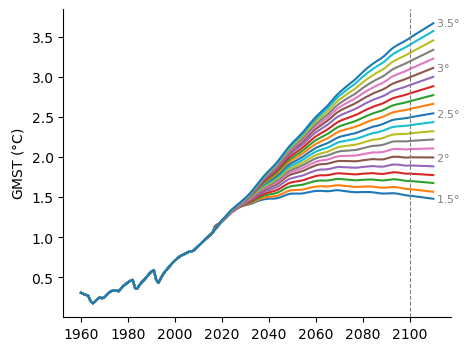

In [29]:
warminglevels = [1.5, 2, 2.5, 3, 3.5]
offsets = [-.01, 0, +.05, +.12, +.18]

fig, ax = plt.subplots(figsize=(5,4))

df_GMT_strj.loc[1960:2110].plot(ax=ax, legend=False)

ax.axvline(2100, ls='--', c='gray', lw=.8)
for lev, off in zip(warminglevels, offsets):
    ax.text(2111, lev+off, str(lev)+'$\degree$', c='gray', fontsize='8', va='center')

plt.ylabel('GMST ($\degree$C)')

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

In [65]:
df_GMT_OS.tail(20)

,1.4
2100,1.424
2101,1.424
2102,1.424
2103,1.424
2104,1.424
2105,1.424
2106,1.424
2107,1.424
2108,1.424
2109,1.424


In [66]:
df_GMT_noOS.tail(20)

,1.3
2100,1.344
2101,1.344
2102,1.344
2103,1.344
2104,1.344
2105,1.344
2106,1.344
2107,1.344
2108,1.344
2109,1.344


In [67]:
df_GMT_15.tail(20)


,1.3
2100,1.336467
2101,1.361027
2102,1.361027
2103,1.361027
2104,1.361027
2105,1.361027
2106,1.361027
2107,1.361027
2108,1.361027
2109,1.361027


In [68]:
df_GMT_20.tail(20)

,2.0
2100,1.978587
2101,1.980163
2102,1.980163
2103,1.980163
2104,1.980163
2105,1.980163
2106,1.980163
2107,1.980163
2108,1.980163
2109,1.980163


In [9]:
ds_GMT_STS

<xarray.Dataset>
Dimensions:     (time: 451, percentile: 4, scenario: 4)
Coordinates:
  * time        (time) int64 1850 1851 1852 1853 1854 ... 2297 2298 2299 2300
  * percentile  (percentile) object '50.0' '95.0' '98.0' '99.0'
  * scenario    (scenario) object 'ModAct' 'Ren' 'LD' 'SP'
Data variables:
    tas         (time, percentile, scenario) float64 ...
Attributes:
    Description:  Trajectories of Global Surface Air Temperature for the Stre...
    Model:        FaIRv1.6.4
    Method:       These scenarios were originally designed for the project PR...
    region:       World
    contact:      Yann Quilcaille <yann.quilcaille@env.ethz.ch>

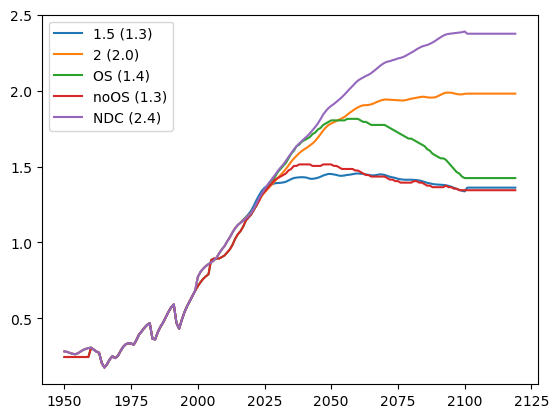

In [10]:
fig, ax = plt.subplots()
labels=['1.5','2','OS', 'noOS', 'NDC']

for i,df in enumerate([df_GMT_15, df_GMT_20,  df_GMT_OS, df_GMT_noOS,df_GMT_NDC ]): #
    df.plot(ax=ax)
    labels[i] = labels[i]+' ('+df.columns.values[0]+')'

ax.legend(labels, loc='upper left')


# issues: 
# 3) other extension methods dont work properly I think.. 

# questions
# how is NDC chosen/set
# how different are the 1.5/2 deg scenariosa nd the strj and how are they made/selected
# how were OS and noOS selected


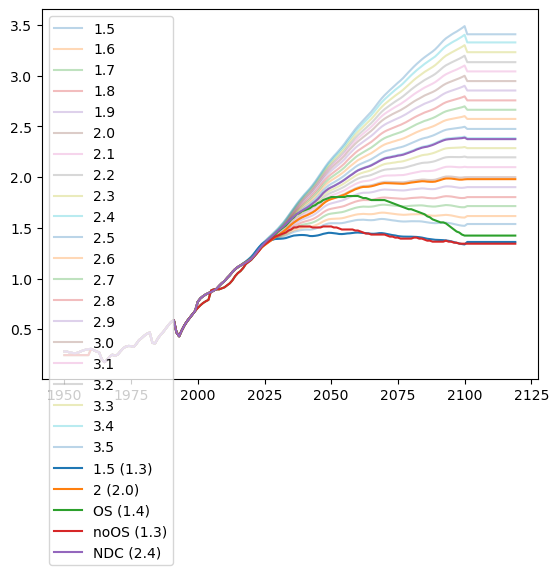

In [11]:
fig, ax = plt.subplots()

df_GMT_strj.plot(ax=ax, alpha=.3)

labels=['1.5','2','OS', 'noOS', 'NDC']

ax.set_prop_cycle(None) 

for i,df in enumerate([df_GMT_15, df_GMT_20,  df_GMT_OS, df_GMT_noOS,df_GMT_NDC ]): 
    labels[i] = labels[i]+' ('+df.columns.values[0]+')'
    df.squeeze().plot(ax=ax, label=labels[i])

plt.legend(loc='upper left')


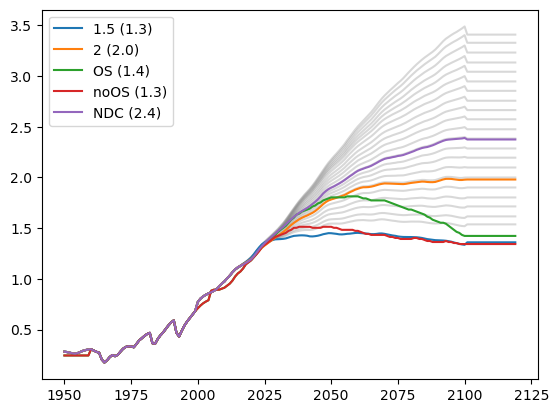

In [12]:
fig, ax = plt.subplots()

# Plot the background lines for df_GMT_strj without adding legend entries
for col in df_GMT_strj.columns:
    ax.plot(df_GMT_strj.index, df_GMT_strj[col], alpha=0.3, color='gray')  # no label

labels = ['1.5', '2', 'OS', 'noOS', 'NDC']

ax.set_prop_cycle(None)

for i, df in enumerate([df_GMT_15, df_GMT_20, df_GMT_OS, df_GMT_noOS, df_GMT_NDC]):
    labels[i] = labels[i] + ' (' + df.columns.values[0] + ')'
    df.squeeze().plot(ax=ax, label=labels[i])

plt.legend(loc='upper left')

### 10yrtrend

In [13]:
df_GMT_15, df_GMT_20, df_GMT_NDC, df_GMT_OS, df_GMT_noOS, ds_GMT_STS, df_GMT_strj = load_GMT(
    year_start=1950,
    year_end=2119,
    gmt_extend_method='10yrtrend',
    smooth_first_decades=False
)

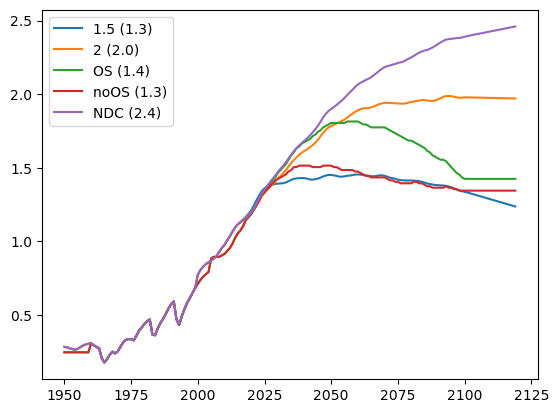

In [14]:
fig, ax = plt.subplots()
labels=['1.5','2','OS', 'noOS', 'NDC']

for i,df in enumerate([df_GMT_15, df_GMT_20,  df_GMT_OS, df_GMT_noOS,df_GMT_NDC ]): #
    df.plot(ax=ax)
    labels[i] = labels[i]+' ('+df.columns.values[0]+')'

ax.legend(labels, loc='upper left')

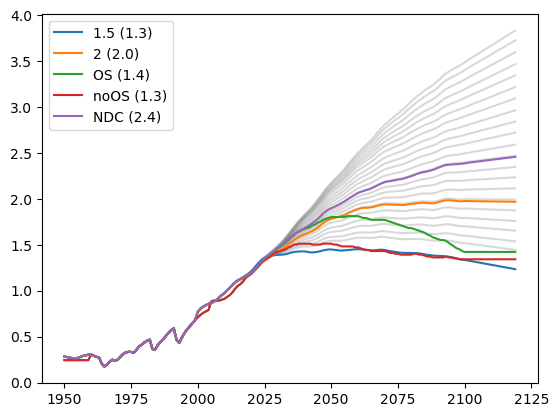

In [15]:
fig, ax = plt.subplots()

# Plot the background lines for df_GMT_strj without adding legend entries
for col in df_GMT_strj.columns:
    ax.plot(df_GMT_strj.index, df_GMT_strj[col], alpha=0.3, color='gray')  # no label

labels = ['1.5', '2', 'OS', 'noOS', 'NDC']

ax.set_prop_cycle(None)

for i, df in enumerate([df_GMT_15, df_GMT_20, df_GMT_OS, df_GMT_noOS, df_GMT_NDC]):
    labels[i] = labels[i] + ' (' + df.columns.values[0] + ')'
    df.squeeze().plot(ax=ax, label=labels[i])

plt.legend(loc='upper left')

In [16]:
## test different extensions

In [17]:

def extend_gmt_to_year_range(df, year_start=1950, year_end=2119, gmt_extend_method=None):
    """
    Extend a GMT time series (Series or DataFrame) to a given year range.
    
    Handles both backward and forward extension using specified method.
    
    Parameters
    ----------
    df : pd.Series or pd.DataFrame
        Input data indexed by year.
    year_start : int, optional
        Earliest year to extend to (fills backward if needed).
    year_end : int, optional
        Latest year to extend to (fills forward if needed).
    gmt_extend_method : {'10yrmean', 'lastyear', '10yrtrend'}, optional
        Method for forward extension beyond the last available year.
    
    Returns
    -------
    pd.DataFrame
        Extended dataset over [year_start, year_end].
    """
    # --- Ensure DataFrame ---
    if isinstance(df, pd.Series):
        df = df.to_frame()
        df.columns = [f"{df.loc[2100].values[0]:.1f}"] if 2100 in df.index else ["value"] # [str(round(df.loc[2100].values[0], 2))] if 2100 in df.index else ["value"]

    df = df.copy()
    df.index = df.index.astype(int)
    
    min_year, max_year = int(np.nanmin(df.index)), int(np.nanmax(df.index))

    # --- Backward extension ---
    if year_start is not None and min_year > year_start:
        first_10y_mean = df.iloc[:10, :].mean()
        for year in range(year_start, min_year):
            df.loc[year] = first_10y_mean
    
    df = df.sort_index()

    # --- Forward extension ---
    if year_end is not None and max_year < year_end:
        if gmt_extend_method == "10yrmean":
            last_10y_mean = df.iloc[-10:, :].mean()
            for year in range(max_year + 1, year_end + 1):
                df.loc[year] = last_10y_mean

        elif gmt_extend_method == "lastyear":
            last_year_vals = df.iloc[-1, :]
            for year in range(max_year + 1, year_end + 1):
                df.loc[year] = last_year_vals

        elif gmt_extend_method == "10yrtrend":
            yrs = np.arange(max_year - 9, max_year + 1)
            trends = {col: np.polyfit(yrs, df.loc[yrs, col].astype(float), 1) for col in df.columns}
            for year in range(max_year + 1, year_end + 1):
                df.loc[year] = {col: np.polyval(trends[col], year) for col in df.columns}

    # --- Sort index and restrict range ---
    df = df.sort_index()
    if year_start is not None or year_end is not None:
        df = df.loc[
            (df.index >= (year_start if year_start is not None else df.index.min())) &
            (df.index <= (year_end if year_end is not None else df.index.max()))
        ]

    return df

In [18]:
from scipy.io import loadmat

# Load GMT_OS
mat_data = loadmat(dir_temperature_trajectories + '/temperature-trajectories_Wim/GMT_OS.mat', squeeze_me=True)
GMT_OS = mat_data['GMT_OS'].flatten()
years = np.arange(1960, 1960 + len(GMT_OS))
df_GMT_OS = pd.Series(GMT_OS, index=years)
df_GMT_OS.name = None
df_GMT_OS.index.name = None

# Load GMT_noOS
mat_data = loadmat(dir_temperature_trajectories + '/temperature-trajectories_Wim/GMT_noOS.mat', squeeze_me=True)
GMT_noOS = mat_data['GMT_noOS'].flatten()
years = np.arange(1960, 1960 + len(GMT_noOS))
df_GMT_noOS = pd.Series(GMT_noOS, index=years)
df_GMT_noOS.name = None
df_GMT_noOS.index.name = None



In [19]:
df_GMT_OS

1960    0.306832
1961    0.293686
1962    0.281428
1963    0.273481
1964    0.206345
          ...   
2109    1.439000
2110    1.439000
2111    1.439000
2112    1.439000
2113    1.439000
Length: 154, dtype: float64

<Axes: >

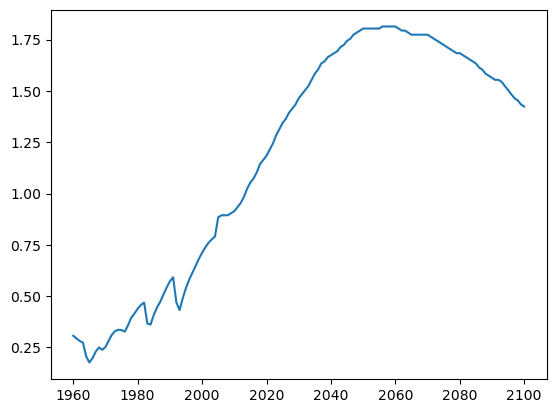

In [20]:
df_GMT_OS.loc[:2100].plot() # try extending OS with trend - too much no?

In [21]:
df_GMT_OS = extend_gmt_to_year_range(df_GMT_OS.loc[:2100],1950, 2119, gmt_extend_method='lastyear')
df_GMT_noOS = extend_gmt_to_year_range(df_GMT_noOS.loc[:2100],1950,2119, gmt_extend_method='lastyear')

<Axes: >

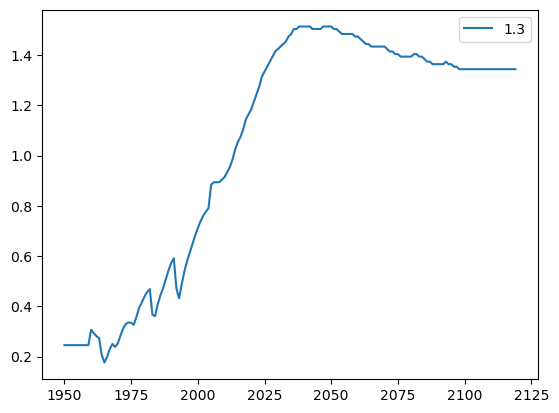

In [22]:
df_GMT_noOS.plot()

<Axes: >

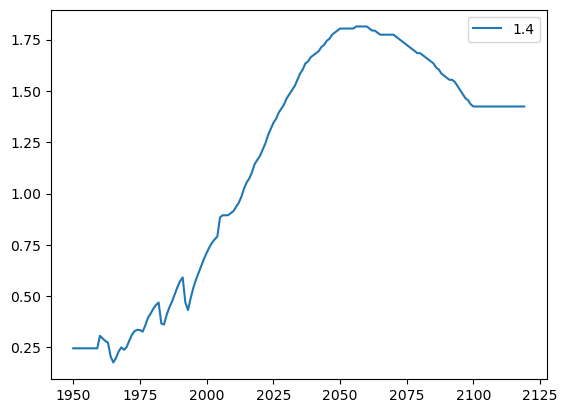

In [23]:
df_GMT_OS.plot()

In [24]:
year_start=1950

# collect new ar6 scens from IASA explorer
df_GMT_ar6 = pd.read_csv(dir_temperature_trajectories+'/temperature-trajectories_AR6/ar6_c1_c7_nogaps_2000-2100.csv',header=0)
df_GMT_ar6.loc[:,'Model'] = df_GMT_ar6.loc[:,'Model']+'_'+df_GMT_ar6.loc[:,'Scenario']
df_GMT_ar6 = df_GMT_ar6.drop(columns=['Scenario','Region','Variable','Unit']).transpose()
df_GMT_ar6.columns=df_GMT_ar6.loc['Model',:]
df_GMT_ar6.columns.name = None
df_GMT_ar6 = df_GMT_ar6.drop(df_GMT_ar6.index[0])
df_GMT_ar6 = df_GMT_ar6.dropna(axis=1)
df_GMT_ar6.index = df_GMT_ar6.index.astype(int)
df_hist_all = df_GMT_15.loc[year_start:1999]
df_hist_all = pd.concat([df_hist_all for i in range(len(df_GMT_ar6.columns))],axis=1)
df_hist_all.columns = df_GMT_ar6.columns
df_GMT_ar6 = pd.concat([df_hist_all,df_GMT_ar6],axis=0) # add historical values to additional scenarios

# drop dups
df_GMT_ar6 = df_GMT_ar6[~df_GMT_ar6.index.duplicated(keep='first')]

# get new trajects - this overwrites the above df_GMT_15
df_GMT_lb, df_GMT_15, df_GMT_20, df_GMT_NDC, df_GMT_30, df_GMT_40 = ar6_scen_grab(
    scen_thresholds,
    df_GMT_ar6,
)  

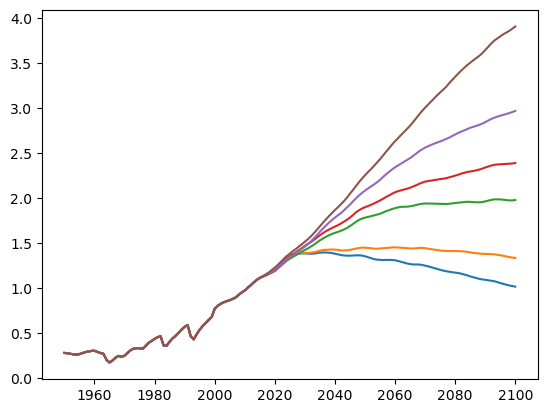

In [25]:
fig, ax = plt.subplots()

for df in [df_GMT_lb, df_GMT_15, df_GMT_20, df_GMT_NDC, df_GMT_30, df_GMT_40]:
    df.plot()

# ar6_scen_grab takes lowest highest and some in the middle, then later interpolates between all of these to have regularly spaced at 0.1 deg intervals in 2100

<Axes: >

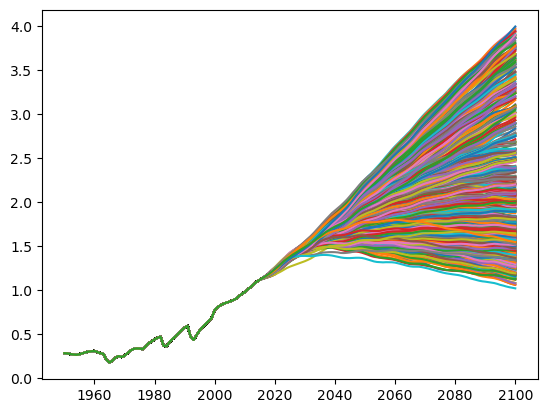

In [26]:
df_GMT_ar6.plot(legend=False)

# all the input scenarios, with one pathway until 1999 

# 2) Load_ISIMIP

Develop how to load data and GMT-mapping metadata

## 2a. Load models : test start

In [2]:

GCMs = ['ACCESS-CM2', 'CNRM-ESM2-1', 'CanESM5', 'EC-EARTH', 'MPI-ESM1-2-HR', 'MRI-ESM2-0']
scenarios = ['historical', 'ssp126', 'ssp245', 'ssp370', 'ssp585']

extremes="FWI95d" # e.g. "FWI95d"
model_names = GCMs
climatedata_dir = '/vscmnt/brussel_pixiu_data/_data_brussel/vo/000/bvo00012/vsc10419/fwi-portugal/data/preprocessed/FWI' # structure should be climatedata_dir/scenario/model
scenarios = scenarios

smoothing=True
rolling_window=21

model_gmst_dir = None # need this!! and prep the GMST 

gmt_mapping_method = 'year-to-year' 

In [3]:
extreme = extremes
model=model_names[0]
scenario=scenarios[1]

In [4]:
scenario

'ssp126'

In [5]:
# initialise counter, metadata dictionary, pic list, pic meta, and 
i = 1
d_climate_data_meta = {}

In [6]:
filepath = glob.glob(os.path.join(climatedata_dir, scenario, model, f'*{model}*{extreme}.nc'))[0]
print(f'Loading {filepath}')

# load data: annual count of exceedances of threshold (already preprocessed)
da_rcp = xr.open_dataarray(filepath, chunks='auto')

# save metadata
d_climate_data_meta[i] = {
    'extreme': extreme,
    'model': model,
    'scenario': scenario,
}

#load associated historical variable
filepath = glob.glob(os.path.join(climatedata_dir, 'historical', model, f'*{model}*{extreme}.nc'))[0]
print(f'Loading {filepath}')
da_hist = xr.open_dataarray(filepath, chunks='auto')

Loading /vscmnt/brussel_pixiu_data/_data_brussel/vo/000/bvo00012/vsc10419/fwi-portugal/data/preprocessed/FWI/ssp126/ACCESS-CM2/FWI_ACCESS-CM2_2015_2100_FWI95d.nc
Loading /vscmnt/brussel_pixiu_data/_data_brussel/vo/000/bvo00012/vsc10419/fwi-portugal/data/preprocessed/FWI/historical/ACCESS-CM2/FWI_ACCESS-CM2_1950_2014_FWI95d.nc


In [32]:
da_exceedances = xr.concat([da_hist,da_rcp], dim='time')


In [33]:
da_exceedances

<xarray.DataArray 'FWI95d' (time: 151, latitude: 392, longitude: 500)>
dask.array<concatenate, shape=(151, 392, 500), dtype=int64, chunksize=(85, 392, 500), chunktype=numpy.ndarray>
Coordinates:
  * longitude  (longitude) float64 -14.96 -14.86 -14.76 ... 34.74 34.84 34.94
  * latitude   (latitude) float64 71.09 70.99 70.89 70.79 ... 32.19 32.09 31.99
    quantile   float64 0.95
  * time       (time) datetime64[ns] 1950-12-31 1951-12-31 ... 2100-12-31

## 2b. GMT per simulation

In [45]:
filepath_model_gmst='../data/gmst-models/gmst_models_1850_2100_fwi.csv'
df_GMT = pd.read_csv(filepath_model_gmst,index_col=0)
df_GMT['year'] = df_GMT['year'].astype(int)


In [46]:
df_GMT

,year,experiment_id,source_id,tas
0,1850,historical,ACCESS-CM2,287.007494
1,1850,historical,CNRM-ESM2-1,286.900465
2,1850,historical,CanESM5,286.806542
3,1850,historical,EC-Earth3,287.029662
4,1850,historical,MPI-ESM1-2-HR,287.064616
...,...,...,...,...
7525,2100,ssp585,CNRM-ESM2-1,292.475368
7526,2100,ssp585,CanESM5,294.452385
7527,2100,ssp585,EC-Earth3,293.272894
7528,2100,ssp585,MPI-ESM1-2-HR,291.375668


In [47]:
df_wide = df_GMT.pivot_table(
    index=["year", "experiment_id"],
    columns="source_id",
    values="tas"
)
df_wide

source_id           ACCESS-CM2  CNRM-ESM2-1     CanESM5   EC-Earth3  \
year experiment_id                                                    
1850 historical     287.007494   286.900465  286.806542  287.029662   
1851 historical     287.016985   287.081066  286.551052  287.130825   
1852 historical     287.174542   287.005218  286.622251  287.183553   
1853 historical     287.070948   286.872643  286.776655  287.000297   
1854 historical     287.141159   286.873972  286.638360  286.945980   
...                        ...          ...         ...         ...   
2099 ssp585         293.114663   292.592435  294.441621  293.299713   
2100 ssp126         289.419884   288.991151  289.683514  289.268752   
     ssp245         290.470334   290.101415  291.057557  290.430415   
     ssp370         291.928374   291.379378  293.137034  291.863306   
     ssp585         293.145303   292.475368  294.452385  293.272894   

source_id           MPI-ESM1-2-HR  MRI-ESM2-0  
year experiment_id                             
1850 historical        287.064616  286.939424  
1851 historical        287.088070  286.991131  
1852 historical        287.281398  286.910700  
1853 historical        287.388171  286.805766  
1854 historical        287.093118  286.766465  
...                           ...         ...  
2099 ssp585            291.458242  291.567732  
2100 ssp126            288.668542  288.494456  
     ssp245            289.534073  289.579336  
     ssp370            290.874307  290.906602  
     ssp585            291.375668  291.848270  

[509 rows x 6 columns]

In [48]:
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.ticker as mticker

filepath_model_gmst='../data/gmst-models/gmst_models_1850_2100_fwi.csv'
df_GMT = pd.read_csv(filepath_model_gmst,index_col=0)
df_GMT['year'] = df_GMT['year'].astype(int)

# --- 1. Compute baseline (1850–1900 mean for each model) ---
baseline = (
    df_GMT.query("1850 <= year <= 1900")
    .groupby("source_id")["tas"]
    .mean()
    .rename("tas_baseline")
)
df_GMT = df_GMT.merge(baseline, on="source_id")
df_GMT["tas_anom"] = df_GMT["tas"] - df_GMT["tas_baseline"]

# --- 2. Pivot to wide format ---
df_wide = df_GMT.pivot_table(
    index=["year", "experiment_id"],
    columns="source_id",
    values="tas_anom"
)


In [49]:
baseline - 273.15 # avg T in 1850-1900


source_id
ACCESS-CM2       13.754873
CNRM-ESM2-1      13.658067
CanESM5          13.563354
EC-Earth3        13.962913
MPI-ESM1-2-HR    13.924616
MRI-ESM2-0       13.731488
Name: tas_baseline, dtype: float64

In [50]:
df_wide

source_id           ACCESS-CM2  CNRM-ESM2-1   CanESM5  EC-Earth3  \
year experiment_id                                                 
1850 historical       0.102621     0.092399  0.093188  -0.083251   
1851 historical       0.112112     0.272999 -0.162302   0.017912   
1852 historical       0.269669     0.197152 -0.091103   0.070640   
1853 historical       0.166075     0.064576  0.063301  -0.112616   
1854 historical       0.236286     0.065905 -0.074994  -0.166933   
...                        ...          ...       ...        ...   
2099 ssp585           6.209790     5.784368  7.728267   6.186800   
2100 ssp126           2.515011     2.183085  2.970160   2.155840   
     ssp245           3.565461     3.293349  4.344203   3.317502   
     ssp370           5.023501     4.571312  6.423680   4.750394   
     ssp585           6.240430     5.667301  7.739031   6.159981   

source_id           MPI-ESM1-2-HR  MRI-ESM2-0  
year experiment_id                             
1850 historical         -0.010000    0.057936  
1851 historical          0.013454    0.109643  
1852 historical          0.206782    0.029212  
1853 historical          0.313555   -0.075722  
1854 historical          0.018502   -0.115023  
...                           ...         ...  
2099 ssp585              4.383627    4.686244  
2100 ssp126              1.593926    1.612968  
     ssp245              2.459458    2.697849  
     ssp370              3.799691    4.025114  
     ssp585              4.301053    4.966782  

[509 rows x 6 columns]

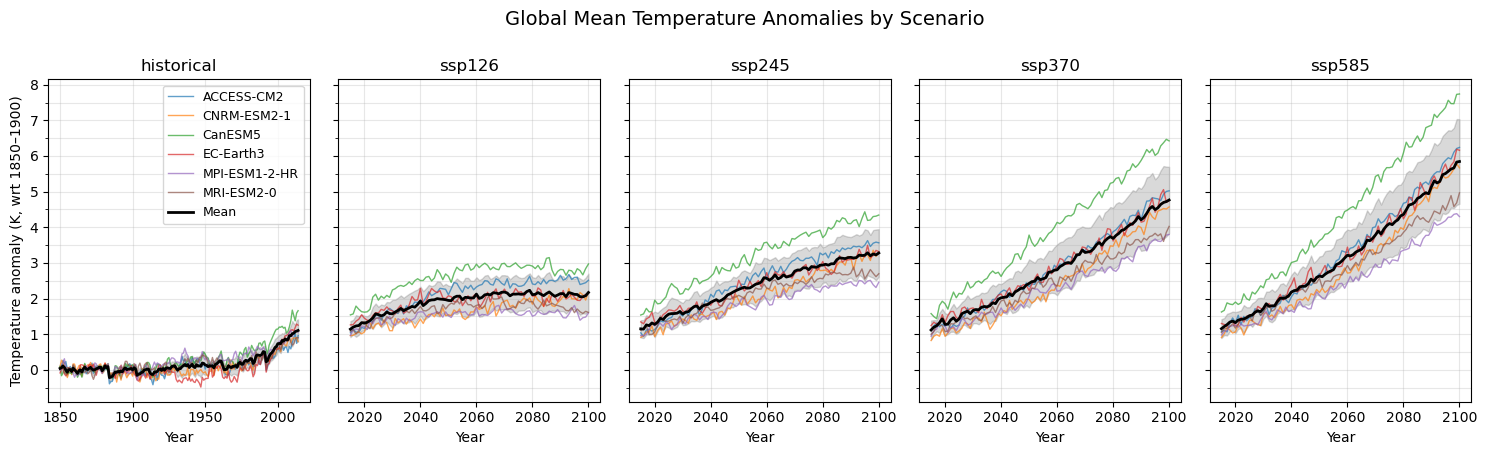

In [51]:

# --- 3. Plot setup ---
scenarios = df_wide.index.get_level_values("experiment_id").unique()
n_scenarios = len(scenarios)

fig, axes = plt.subplots(
    nrows=1,
    ncols=n_scenarios,
    figsize=(3 * n_scenarios, 4.5),
    sharey=True
)

if n_scenarios == 1:
    axes = [axes]

# --- 4. Plot each scenario ---
for ax, scenario in zip(axes, scenarios):
    df_scenario = df_wide.xs(scenario, level="experiment_id")

    # Plot individual model lines
    for model in df_scenario.columns:
        ax.plot(df_scenario.index, df_scenario[model], lw=1, alpha=0.7, label=model)

    # Ensemble mean and ±1σ
    mean = df_scenario.mean(axis=1)
    std = df_scenario.std(axis=1)
    ax.plot(df_scenario.index, mean, color="black", lw=2, label="Mean")
    ax.fill_between(df_scenario.index, mean - std, mean + std, color="black", alpha=0.15)

    ax.set_title(scenario)
    ax.set_xlabel("Year")
    ax.grid(True, alpha=0.3)
    ax.grid(True, which='minor', alpha=0.3)
    ax.yaxis.set_major_locator(mticker.MultipleLocator(1))
    ax.yaxis.set_minor_locator(mticker.MultipleLocator(0.5))

axes[0].set_ylabel("Temperature anomaly (K, wrt 1850–1900)")
axes[0].legend(bbox_to_anchor=(1,1), fontsize=9)
fig.suptitle("Global Mean Temperature Anomalies by Scenario", fontsize=14, y=1)
plt.tight_layout()
plt.show()


In [52]:
gmt_anomaly_baseline_period = (1850,1900)
gmt_anomaly_correction = 0 
modelname=GCMs[0]
scenario=scenarios[2]

# simpler for the code 
df_GMT = pd.read_csv(filepath_model_gmst,index_col=0)
df_GMT['year'] = df_GMT['year'].astype(int)
modelname = model if model != 'EC-EARTH' else 'EC-Earth3'
df_GMT_hist = df_GMT[(df_GMT['experiment_id']=='historical') & (df_GMT['source_id']==modelname)].set_index('year').drop(columns=['experiment_id','source_id']).dropna()
df_GMT_rcp = df_GMT[(df_GMT['experiment_id']==scenario) & (df_GMT['source_id']==modelname)].set_index('year').drop(columns=['experiment_id','source_id']).dropna()

# concatenate historical and future GMT data
df_GMT = pd.concat([df_GMT_hist,df_GMT_rcp])

# convert GMT from absolute values to anomalies - if you use a non 1850-1900 period should provide a gmt_anomaly_correction
df_GMT = df_GMT - df_GMT.loc[gmt_anomaly_baseline_period[0] : gmt_anomaly_baseline_period[1]].mean() + gmt_anomaly_correction



In [53]:
df_GMT

,tas
year,
1850,0.057936
1851,0.109643
1852,0.029212
1853,-0.075722
1854,-0.115023
...,...
2096,2.677123
2097,2.816019
2098,2.710975


### GMT anomaly correction: compare with obs GMT

To make the timeseries relative to 1985-2014 warming level 

In [54]:


filepath_gmt_obs = '../data/gmst-obs/GCH_time_series_of_annual_global_temperatures_1850-2024_wrt_1991-2020.csv'

gmt_obs = pd.read_csv(filepath_gmt_obs,skiprows=3,index_col=0, na_values=-999,usecols=[0,1,2,3,4,5])

gmt_obs

,ERA5,JRA-3Q,Berkeley Earth,GISTEMP,HadCRUT5
Year,,,,,
1850,NaN,NaN,-0.084,NaN,-0.084
1851,NaN,NaN,0.014,NaN,0.107
1852,NaN,NaN,0.052,NaN,0.104
1853,NaN,NaN,0.035,NaN,0.071
1854,NaN,NaN,0.016,NaN,0.052
...,...,...,...,...,...
2020,1.310,1.263,1.261,1.274,1.258
2021,1.155,1.082,1.112,1.116,1.099
2022,1.181,1.146,1.148,1.161,1.138


<Axes: xlabel='Year'>

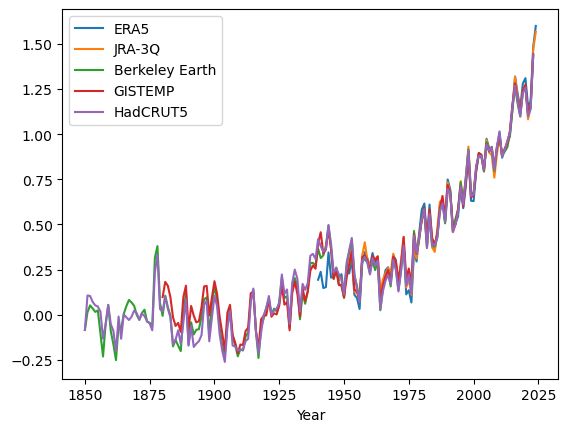

In [55]:
gmt_obs.plot()

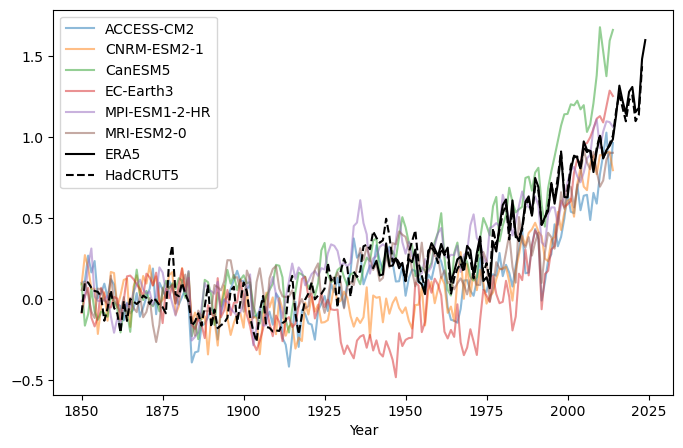

In [56]:
fig,ax = plt.subplots(figsize=(8,5))

df_scenario = df_wide.xs('historical', level="experiment_id")
df_scenario.plot(ax=ax, alpha=.5)

gmt_obs['ERA5'].plot(ax=ax, c='k')
gmt_obs['HadCRUT5'].plot(ax=ax, c='k', ls='--')

plt.legend()

### do it all relative to 1985-2014 !

In [57]:
gmt_obs[['ERA5']].loc[1985:2014].mean()[0]

0.7432

In [58]:
gmt_obs.loc[1985:2014].mean()

ERA5              0.743200
JRA-3Q            0.748733
Berkeley Earth    0.747667
GISTEMP           0.749267
HadCRUT5          0.746967
dtype: float64

In [59]:
gmt_obs.loc[1850:1900].mean()

ERA5                   NaN
JRA-3Q                 NaN
Berkeley Earth   -0.013039
GISTEMP           0.052286
HadCRUT5         -0.020608
dtype: float64

In [60]:
scenarios[2]

'ssp245'

In [61]:
df_scenario = pd.concat([df_wide.xs('historical', level="experiment_id"), df_wide.xs(scenarios[2], level="experiment_id")])
df_scenario

source_id,ACCESS-CM2,CNRM-ESM2-1,CanESM5,EC-Earth3,MPI-ESM1-2-HR,MRI-ESM2-0
year,,,,,,
1850,0.102621,0.092399,0.093188,-0.083251,-0.010000,0.057936
1851,0.112112,0.272999,-0.162302,0.017912,0.013454,0.109643
1852,0.269669,0.197152,-0.091103,0.070640,0.206782,0.029212
1853,0.166075,0.064576,0.063301,-0.112616,0.313555,-0.075722
1854,0.236286,0.065905,-0.074994,-0.166933,0.018502,-0.115023
...,...,...,...,...,...,...
2096,3.628022,3.230348,4.193259,3.495573,2.491945,2.677123
2097,3.461565,3.070280,4.205110,3.143452,2.512813,2.816019
2098,3.554259,3.356660,4.302070,3.208572,2.389425,2.710975


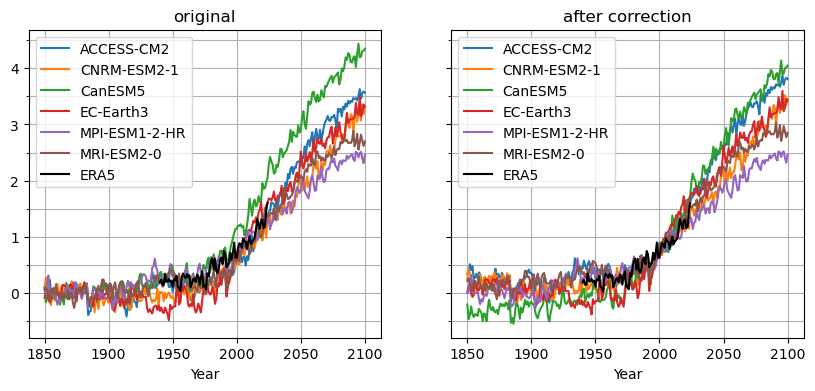

In [62]:
gmt_anomaly_baseline_period = (1985,2014)
gmt_anomaly_correction = 0.74

fig,axes=plt.subplots(1,2,figsize=(10,4), sharey=True)

# original 
df_scenario.plot(ax=axes[0])
axes[0].set_title('original')
# corrected
(df_scenario - df_scenario.loc[1985:2014].mean() + gmt_anomaly_correction).plot(ax=axes[1])
axes[1].set_title('after correction')


for ax in axes:
    gmt_obs['ERA5'].plot(ax=ax, c='k')
    #gmt_obs['HadCRUT5'].plot(ax=ax, c='k', ls='--')
    ax.grid()
    ax.yaxis.set_minor_locator(mticker.MultipleLocator(0.5))
    ax.grid(True, which='minor')
    ax.legend()



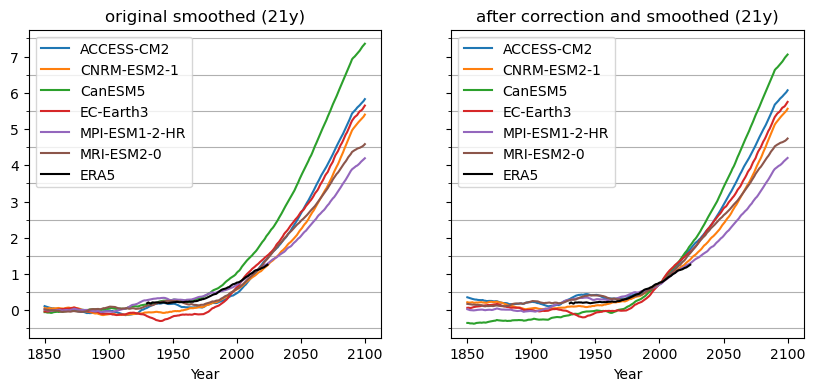

In [72]:
gmt_anomaly_baseline_period = (1985,2014)
gmt_anomaly_correction = 0.74

fig,axes=plt.subplots(1,2,figsize=(10,4), sharey=True)

# original 
df_scenario.rolling(21,min_periods=1,center=True).mean().plot(ax=axes[0])
axes[0].set_title('original smoothed (21y)')
# corrected
(df_scenario - df_scenario.loc[1985:2014].mean() + gmt_anomaly_correction).rolling(21,min_periods=1,center=True).mean().plot(ax=axes[1])
axes[1].set_title('after correction and smoothed (21y)')

for ax in axes:
    ax.grid()
    gmt_obs['ERA5'].rolling(21,min_periods=1,center=True).mean().plot(ax=ax, c='k')
    ax.yaxis.set_minor_locator(mticker.MultipleLocator(0.5))
    ax.grid(True, which='minor')
    ax.legend()

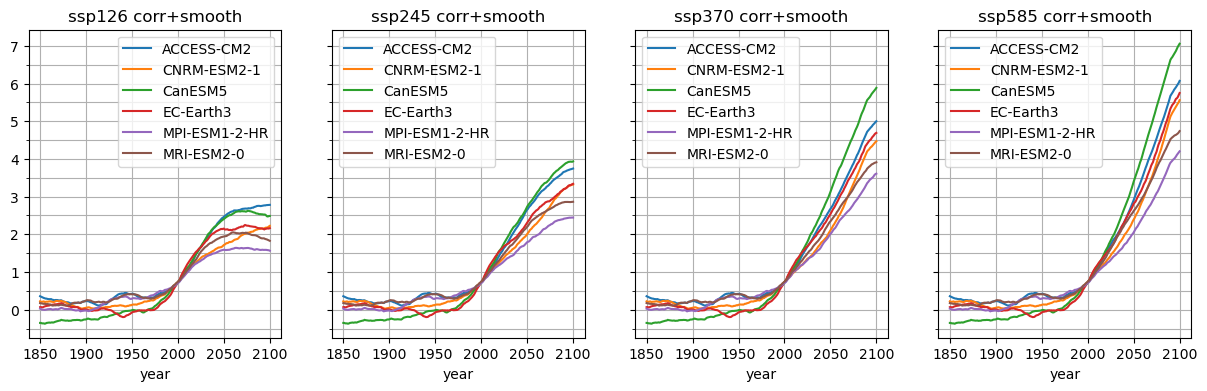

In [71]:
gmt_anomaly_baseline_period = (1985,2014)
gmt_anomaly_correction = 0.74

fig,axes=plt.subplots(1,4,figsize=(15,4), sharey=True)

for ax, scenario in zip(axes, scenarios[1:]):
    df_scenario = pd.concat([df_wide.xs('historical', level="experiment_id"), df_wide.xs(scenario, level="experiment_id")])
    (df_scenario - df_scenario.loc[1985:2014].mean() + gmt_anomaly_correction).rolling(21,min_periods=1,center=True).mean().plot(ax=ax)
    ax.set_title(f'{scenario} corr+smooth')

for ax in axes:
    ax.grid()
    ax.yaxis.set_minor_locator(mticker.MultipleLocator(0.5))
    ax.grid(True, which='minor')
    ax.legend()


## 2c. Test open model

In [53]:
GCMs = ['ACCESS-CM2', 'CNRM-ESM2-1', 'CanESM5', 'EC-EARTH', 'MPI-ESM1-2-HR', 'MRI-ESM2-0']
scenarios = ['ssp126', 'ssp245', 'ssp370', 'ssp585']


In [54]:
d_climate_data_meta = load_climate_data(
    extremes = "FWI95d",                   # e.g. "FWI95d"
    model_names = GCMs[0:2],                # GCMs
    df_GMT_strj =df_GMT_strj ,                # stylized trajectories
    GMT_extra_trajectories = None,
    GMT_extra_trajectories_names = None,
    climatedata_dir = '/vscmnt/brussel_pixiu_data/_data_brussel/vo/000/bvo00012/vsc10419/fwi-portugal/data/preprocessed/FWI',     # structure should be : climatedata_dir/scenario/model/'*{model}*{extreme}.nc
    filepath_model_gmst = os.path.join(data_dir, 'gmst-models/gmst_models_1850_2100_fwi.csv'),
    scenarios = scenarios,
    smoothing=True,
    rolling_window=21,
    min_periods=11,
    gmt_anomaly_baseline_period = (1985,2014),
    gmt_anomaly_correction = 0.74,
    year_start=1950,
    year_end = 2119,            # 2025 + max life expectancy
    gmt_mapping_method = 'year-to-year', 
    max_diff_valid = .2, 
    )

Processing climate data
Processing for FWI95d
Loading /vscmnt/brussel_pixiu_data/_data_brussel/vo/000/bvo00012/vsc10419/fwi-portugal/data/preprocessed/FWI/ssp126/ACCESS-CM2/FWI_ACCESS-CM2_2015_2100_FWI95d.nc
Loading /vscmnt/brussel_pixiu_data/_data_brussel/vo/000/bvo00012/vsc10419/fwi-portugal/data/preprocessed/FWI/historical/ACCESS-CM2/FWI_ACCESS-CM2_1950_2014_FWI95d.nc
Loading /vscmnt/brussel_pixiu_data/_data_brussel/vo/000/bvo00012/vsc10419/fwi-portugal/data/preprocessed/FWI/ssp245/ACCESS-CM2/FWI_ACCESS-CM2_2015_2100_FWI95d.nc
Loading /vscmnt/brussel_pixiu_data/_data_brussel/vo/000/bvo00012/vsc10419/fwi-portugal/data/preprocessed/FWI/historical/ACCESS-CM2/FWI_ACCESS-CM2_1950_2014_FWI95d.nc
Loading /vscmnt/brussel_pixiu_data/_data_brussel/vo/000/bvo00012/vsc10419/fwi-portugal/data/preprocessed/FWI/ssp370/ACCESS-CM2/FWI_ACCESS-CM2_2015_2100_FWI95d.nc
Loading /vscmnt/brussel_pixiu_data/_data_brussel/vo/000/bvo00012/vsc10419/fwi-portugal/data/preprocessed/FWI/historical/ACCESS-CM2/FWI_A

## 2d. test with all scnearios

In [17]:
df_GMT_15, df_GMT_20, df_GMT_NDC, df_GMT_OS, df_GMT_noOS, ds_GMT_STS, df_GMT_strj = load_GMT(
    year_start=1950,
    year_end=2119,
    gmt_extend_method='10yrtrend',
    smooth_first_decades=False
)

In [18]:
GCMs = ['ACCESS-CM2', 'CNRM-ESM2-1', 'CanESM5', 'EC-EARTH', 'MPI-ESM1-2-HR', 'MRI-ESM2-0']
scenarios = ['ssp126', 'ssp245', 'ssp370', 'ssp585']

In [19]:
d_climate_data_meta = load_climate_data(
    extremes = "FWI95d",                   # e.g. "FWI95d"
    model_names = GCMs,                # GCMs
    df_GMT_strj =df_GMT_strj ,                # stylized trajectories
    GMT_extra_trajectories = [df_GMT_15, df_GMT_20, df_GMT_NDC, df_GMT_OS, df_GMT_noOS],
    GMT_extra_trajectories_names = ['15', '20', 'NDC', 'OS', 'noOS'],
    climatedata_dir = '/vscmnt/brussel_pixiu_data/_data_brussel/vo/000/bvo00012/vsc10419/fwi-portugal/data/preprocessed/FWI',     # structure should be : climatedata_dir/scenario/model/'*{model}*{extreme}.nc
    filepath_model_gmst = os.path.join(data_dir, 'gmst-models/gmst_models_1850_2100_fwi.csv'),
    scenarios = scenarios,
    smoothing=True,
    rolling_window=21,
    min_periods=1,
    gmt_anomaly_baseline_period = (1985,2014),
    gmt_anomaly_correction = 0.74,
    year_start=1950,
    year_end = 2119,            # 2025 + max life expectancy
    gmt_mapping_method = 'year-to-year', 
    max_diff_valid = .2, 
    )

Processing climate data
Processing for FWI95d
Loading /vscmnt/brussel_pixiu_data/_data_brussel/vo/000/bvo00012/vsc10419/fwi-portugal/data/preprocessed/FWI/ssp126/ACCESS-CM2/FWI_ACCESS-CM2_2015_2100_FWI95d.nc
Loading /vscmnt/brussel_pixiu_data/_data_brussel/vo/000/bvo00012/vsc10419/fwi-portugal/data/preprocessed/FWI/historical/ACCESS-CM2/FWI_ACCESS-CM2_1950_2014_FWI95d.nc
Loading /vscmnt/brussel_pixiu_data/_data_brussel/vo/000/bvo00012/vsc10419/fwi-portugal/data/preprocessed/FWI/ssp245/ACCESS-CM2/FWI_ACCESS-CM2_2015_2100_FWI95d.nc
Loading /vscmnt/brussel_pixiu_data/_data_brussel/vo/000/bvo00012/vsc10419/fwi-portugal/data/preprocessed/FWI/historical/ACCESS-CM2/FWI_ACCESS-CM2_1950_2014_FWI95d.nc
Loading /vscmnt/brussel_pixiu_data/_data_brussel/vo/000/bvo00012/vsc10419/fwi-portugal/data/preprocessed/FWI/ssp370/ACCESS-CM2/FWI_ACCESS-CM2_2015_2100_FWI95d.nc
Loading /vscmnt/brussel_pixiu_data/_data_brussel/vo/000/bvo00012/vsc10419/fwi-portugal/data/preprocessed/FWI/historical/ACCESS-CM2/FWI_A

In [57]:
d_climate_data_meta[1]

{'extreme': 'FWI95d',
 'model': 'ACCESS-CM2',
 'scenario': 'ssp126',
 'GMT':            tas
 1950  0.385547
 1951  0.393164
 1952  0.393677
 1953  0.379471
 1954  0.362028
 ...        ...
 2115  2.769605
 2116  2.769605
 2117  2.769605
 2118  2.769605
 2119  2.769605
 
 [170 rows x 1 columns],
 'GMT_strj_maxdiff': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1]),
 'GMT_strj_valid': array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0]),
 'ind_RCP2GMT_strj': array([[ 23,  23,  23, ...,  23,  23,  23],
        [ 23,  23,  23, ...,  23,  23,  23],
        [ 23,  23,  23, ...,  23,  23,  23],
        ...,
        [ 69,  72,  75, ..., 149, 149, 149],
        [ 69,  71,  75, ..., 149, 149, 149],
        [ 69,  71,  75, ..., 149, 149, 149]]),
 'GMT_15_maxdiff': 0.14355040795676718,
 'GMT_15_valid': True,
 'ind_RCP2GMT_15': array([23, 23, 23, 23, 23, 23, 23, 23, 23, 23, 23, 23, 23, 23, 23, 23, 23,
        23, 23, 23, 23, 23, 23, 20, 19, 19, 21,  4, 27, 29,

### plot GMT mapping (reindexing)

Notes
- looks very similar for window of smoothig of 21 years, regardless of min_periods - check this with Amaury he was saying it was very sensitive
- check if endyears get lost with smoothing???
- ssp126 looks terrible mapped onto warm scenarios 
    - make tolerance more stringent? > no effect

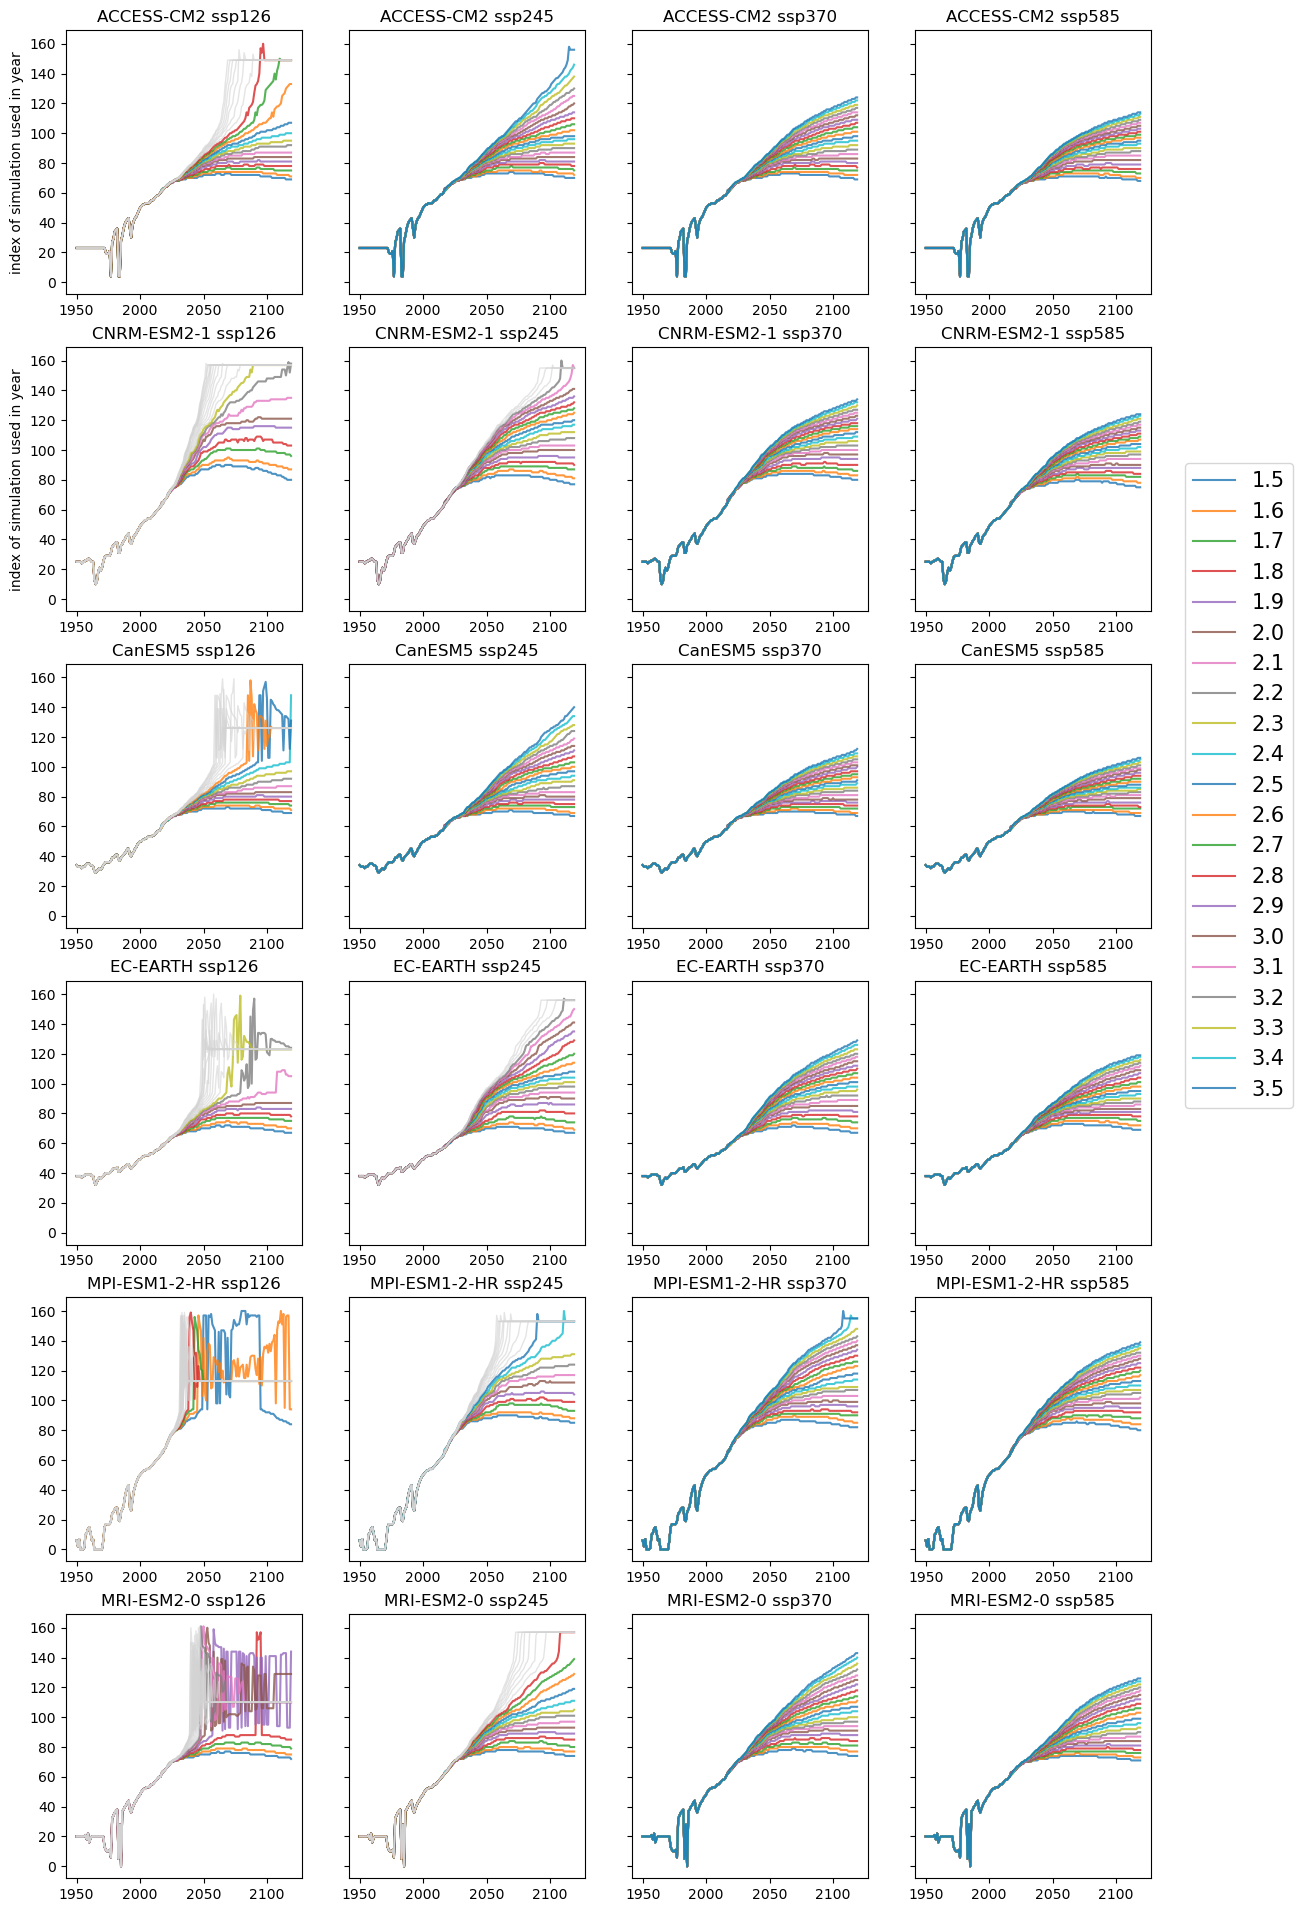

In [78]:

nrows=6

fig, axes = plt.subplots(nrows,4,figsize=(14,4*nrows),sharey=True)

axes=axes.flatten()

for i, ax in enumerate(axes):

    i+=1

    df_mapping = pd.DataFrame(data =d_climate_data_meta[i]['ind_RCP2GMT_strj'], columns=df_GMT_strj.columns, index=np.arange(1950,2120) )
    valid = np.array(d_climate_data_meta[i]['GMT_strj_valid'])  # your 0/1 array

    for col, is_valid in zip(df_mapping.columns, valid):
        if is_valid:
            ax.plot(df_mapping.index, df_mapping[col], lw=1.5, alpha=0.8,label=col)
        else:
            ax.plot(df_mapping.index, df_mapping[col], color='lightgray', lw=1.0, alpha=0.6)


    ax.set_title(d_climate_data_meta[i]['model']+' '+d_climate_data_meta[i]['scenario'])

    if i==1 or i==5:
        ax.set_ylabel('index of simulation used in year')
    
    if i==4:
        ax.legend(loc='upper left', bbox_to_anchor=(1.1, -0.6), fontsize=15)
    

## 2e. compare first years of stylized trajs with ERA5 - smooth the first years??

In [9]:
df_GMT_15, df_GMT_20, df_GMT_NDC, df_GMT_OS, df_GMT_noOS, ds_GMT_STS, df_GMT_strj = load_GMT(
    year_start=1950,
    year_end=2119,
    gmt_extend_method='10yrtrend',
    smooth_first_decades=False
)

In [14]:


filepath_gmt_obs = '../data/gmst-obs/GCH_time_series_of_annual_global_temperatures_1850-2024_wrt_1991-2020.csv'

gmt_obs = pd.read_csv(filepath_gmt_obs,skiprows=3,index_col=0, na_values=-999,usecols=[0,1,2,3,4,5])


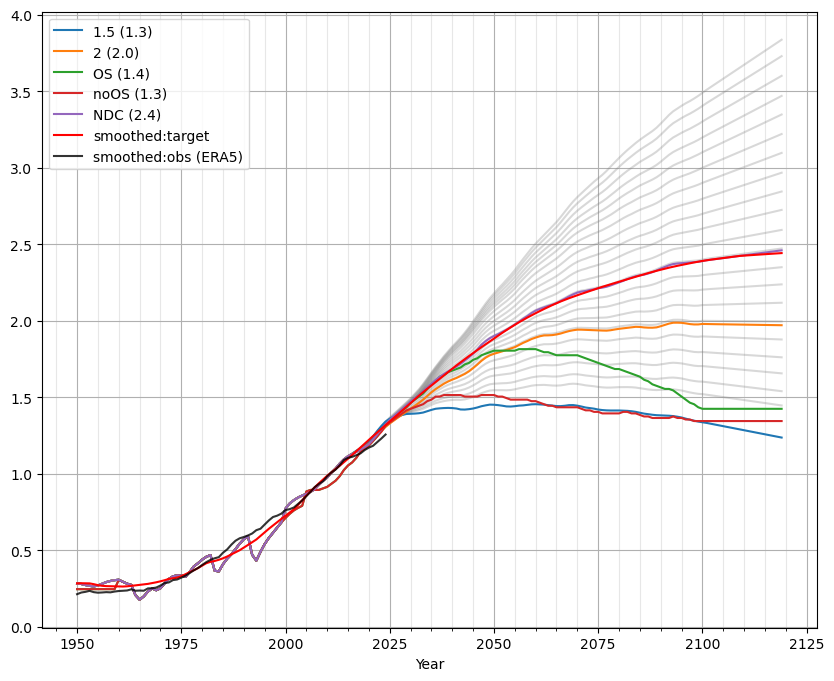

In [23]:
fig, ax = plt.subplots(figsize=(10,8))

# Plot the background lines for df_GMT_strj without adding legend entries
for col in df_GMT_strj.columns:
    ax.plot(df_GMT_strj.index, df_GMT_strj[col], alpha=0.3, color='gray')  # no label

labels = ['1.5', '2', 'OS', 'noOS', 'NDC']

ax.set_prop_cycle(None)

for i, df in enumerate([df_GMT_15, df_GMT_20, df_GMT_OS, df_GMT_noOS, df_GMT_NDC]):
    labels[i] = labels[i] + ' (' + df.columns.values[0] + ')'
    df.squeeze().plot(ax=ax, label=labels[i])

df.squeeze().rolling(21,min_periods=1,center=True).mean().plot(ax=ax, label='smoothed:target', c='red')



gmt_obs['ERA5'].loc[1950:].rolling(21,min_periods=1,center=True).mean().plot(ax=ax, c='k', alpha=.8, label='smoothed:obs (ERA5)')

plt.legend(loc='upper left')

ax.grid(True, which='minor', alpha=0.3)

ax.xaxis.set_minor_locator(mticker.MultipleLocator(5))


plt.grid()

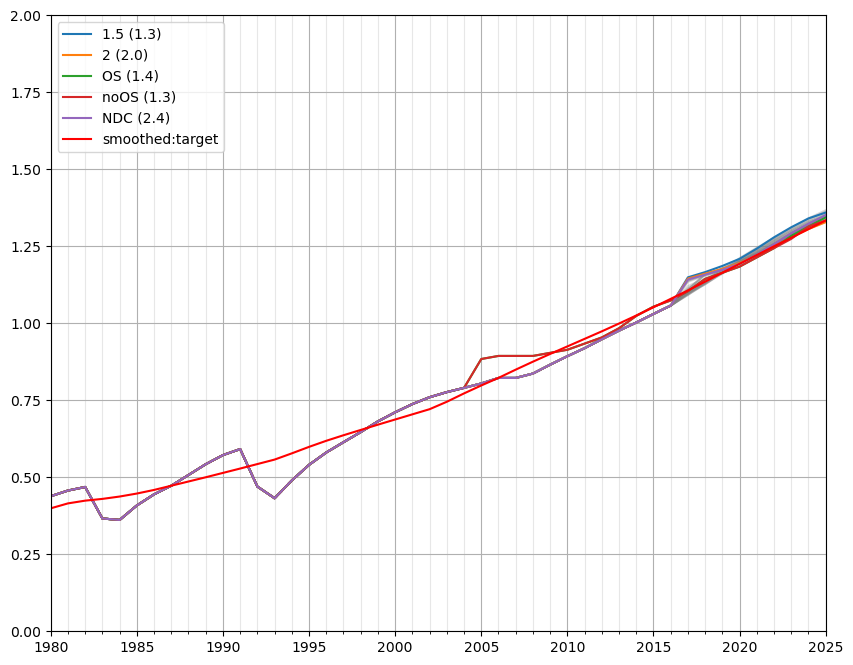

In [79]:
fig, ax = plt.subplots(figsize=(10,8))

# Plot the background lines for df_GMT_strj without adding legend entries
for col in df_GMT_strj.columns:
    ax.plot(df_GMT_strj.index, df_GMT_strj[col], alpha=0.3, color='gray')  # no label

labels = ['1.5', '2', 'OS', 'noOS', 'NDC']

ax.set_prop_cycle(None)

for i, df in enumerate([df_GMT_15, df_GMT_20, df_GMT_OS, df_GMT_noOS, df_GMT_NDC]):
    labels[i] = labels[i] + ' (' + df.columns.values[0] + ')'
    df.squeeze().plot(ax=ax, label=labels[i])

df.squeeze().rolling(21,min_periods=1,center=True).mean().plot(ax=ax, label='smoothed:target', c='red')



#gmt_obs['ERA5'].loc[1950:].rolling(21,min_periods=1,center=True).mean().plot(ax=ax, c='k', alpha=.8, label='smoothed:obs (ERA5)')

plt.legend(loc='upper left')

ax.grid(True, which='minor', alpha=0.3)

ax.xaxis.set_minor_locator(mticker.MultipleLocator(1))

ax.set_xlim(1980,2025)
ax.set_ylim(0,2)

plt.grid()

In [9]:
df.loc[:2015]

,2.4
1950,0.283403
1951,0.28426
1952,0.284042
1953,0.283287
1954,0.278158
...,...
2011,1.006373
2012,1.033262
2013,1.065928
2014,1.093617


## 2f. smooth first years of stylized trajs and re-run GMT-mapping

In [80]:
df_GMT_15, df_GMT_20, df_GMT_NDC, df_GMT_OS, df_GMT_noOS, ds_GMT_STS, df_GMT_strj = load_GMT(
    year_start=1950,
    year_end=2119,
    gmt_extend_method='10yrtrend',
    smooth_first_decades=True
)

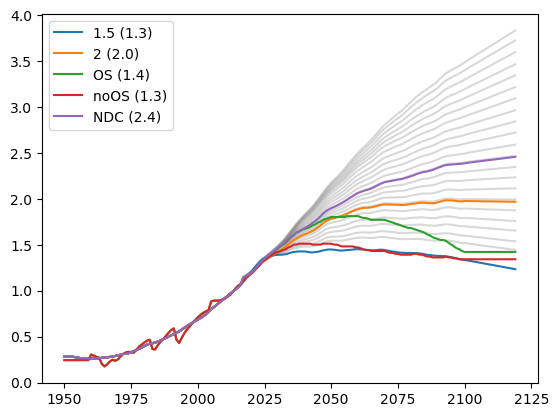

In [9]:
fig, ax = plt.subplots()

# Plot the background lines for df_GMT_strj without adding legend entries
for col in df_GMT_strj.columns:
    ax.plot(df_GMT_strj.index, df_GMT_strj[col], alpha=0.3, color='gray')  # no label

labels = ['1.5', '2', 'OS', 'noOS', 'NDC']

ax.set_prop_cycle(None)

for i, df in enumerate([df_GMT_15, df_GMT_20, df_GMT_OS, df_GMT_noOS, df_GMT_NDC]):
    labels[i] = labels[i] + ' (' + df.columns.values[0] + ')'
    df.squeeze().plot(ax=ax, label=labels[i])

plt.legend(loc='upper left')

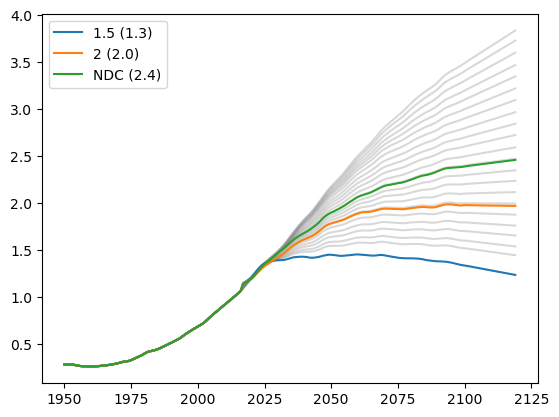

In [ ]:
fig, ax = plt.subplots()

# Plot the background lines for df_GMT_strj without adding legend entries
for col in df_GMT_strj.columns:
    ax.plot(df_GMT_strj.index, df_GMT_strj[col], alpha=0.3, color='gray')  # no label

labels = ['1.5', '2', 'NDC']

ax.set_prop_cycle(None)

for i, df in enumerate([df_GMT_15, df_GMT_20, df_GMT_NDC]):
    labels[i] = labels[i] + ' (' + df.columns.values[0] + ')'
    df.squeeze().plot(ax=ax, label=labels[i])

plt.legend(loc='upper left')

# OS noOS are not smoothed !! should I ? Maybe for consistency

(0.0, 2.0)

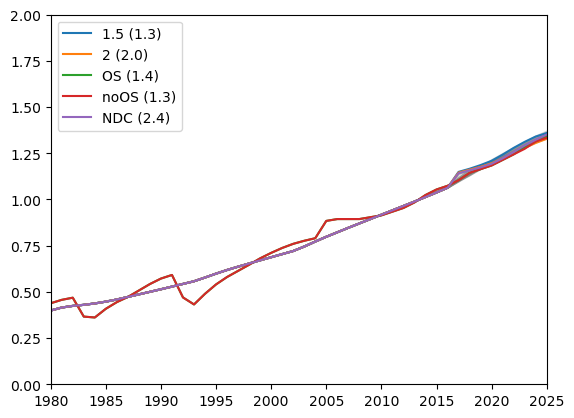

In [10]:
fig, ax = plt.subplots()

# Plot the background lines for df_GMT_strj without adding legend entries
for col in df_GMT_strj.columns:
    ax.plot(df_GMT_strj.index, df_GMT_strj[col], alpha=0.3, color='gray')  # no label

labels = ['1.5', '2', 'OS', 'noOS', 'NDC']

ax.set_prop_cycle(None)

for i, df in enumerate([df_GMT_15, df_GMT_20, df_GMT_OS, df_GMT_noOS, df_GMT_NDC]):
    labels[i] = labels[i] + ' (' + df.columns.values[0] + ')'
    df.squeeze().plot(ax=ax, label=labels[i])

plt.legend(loc='upper left')

ax.set_xlim(1980,2025)
ax.set_ylim(0,2)

In [81]:
GCMs = ['ACCESS-CM2', 'CNRM-ESM2-1', 'CanESM5', 'EC-EARTH', 'MPI-ESM1-2-HR', 'MRI-ESM2-0']
scenarios = ['ssp126', 'ssp245', 'ssp370', 'ssp585']

In [82]:
d_climate_data_meta = load_climate_data(
    extremes = "FWI95d",                   # e.g. "FWI95d"
    model_names = GCMs,                # GCMs
    df_GMT_strj =df_GMT_strj ,                # stylized trajectories
    GMT_extra_trajectories = [df_GMT_15, df_GMT_20, df_GMT_NDC, df_GMT_OS, df_GMT_noOS],
    GMT_extra_trajectories_names = ['15', '20', 'NDC', 'OS', 'noOS'],
    climatedata_dir = '/vscmnt/brussel_pixiu_data/_data_brussel/vo/000/bvo00012/vsc10419/fwi-portugal/data/preprocessed/FWI',     # structure should be : climatedata_dir/scenario/model/'*{model}*{extreme}.nc
    filepath_model_gmst = os.path.join(data_dir, 'gmst-models/gmst_models_1850_2100_fwi.csv'),
    scenarios = scenarios,
    smoothing=True,
    rolling_window=21,
    min_periods=1,
    gmt_anomaly_baseline_period = (1985,2014),
    gmt_anomaly_correction = 0.74,
    year_start=1950,
    year_end = 2119,            # 2025 + max life expectancy
    gmt_mapping_method = 'year-to-year', 
    max_diff_valid = .2, 
    )

Processing climate data
Processing for FWI95d
Loading /vscmnt/brussel_pixiu_data/_data_brussel/vo/000/bvo00012/vsc10419/fwi-portugal/data/preprocessed/FWI/ssp126/ACCESS-CM2/FWI_ACCESS-CM2_2015_2100_FWI95d.nc
Loading /vscmnt/brussel_pixiu_data/_data_brussel/vo/000/bvo00012/vsc10419/fwi-portugal/data/preprocessed/FWI/historical/ACCESS-CM2/FWI_ACCESS-CM2_1950_2014_FWI95d.nc
Loading /vscmnt/brussel_pixiu_data/_data_brussel/vo/000/bvo00012/vsc10419/fwi-portugal/data/preprocessed/FWI/ssp245/ACCESS-CM2/FWI_ACCESS-CM2_2015_2100_FWI95d.nc
Loading /vscmnt/brussel_pixiu_data/_data_brussel/vo/000/bvo00012/vsc10419/fwi-portugal/data/preprocessed/FWI/historical/ACCESS-CM2/FWI_ACCESS-CM2_1950_2014_FWI95d.nc
Loading /vscmnt/brussel_pixiu_data/_data_brussel/vo/000/bvo00012/vsc10419/fwi-portugal/data/preprocessed/FWI/ssp370/ACCESS-CM2/FWI_ACCESS-CM2_2015_2100_FWI95d.nc
Loading /vscmnt/brussel_pixiu_data/_data_brussel/vo/000/bvo00012/vsc10419/fwi-portugal/data/preprocessed/FWI/historical/ACCESS-CM2/FWI_A

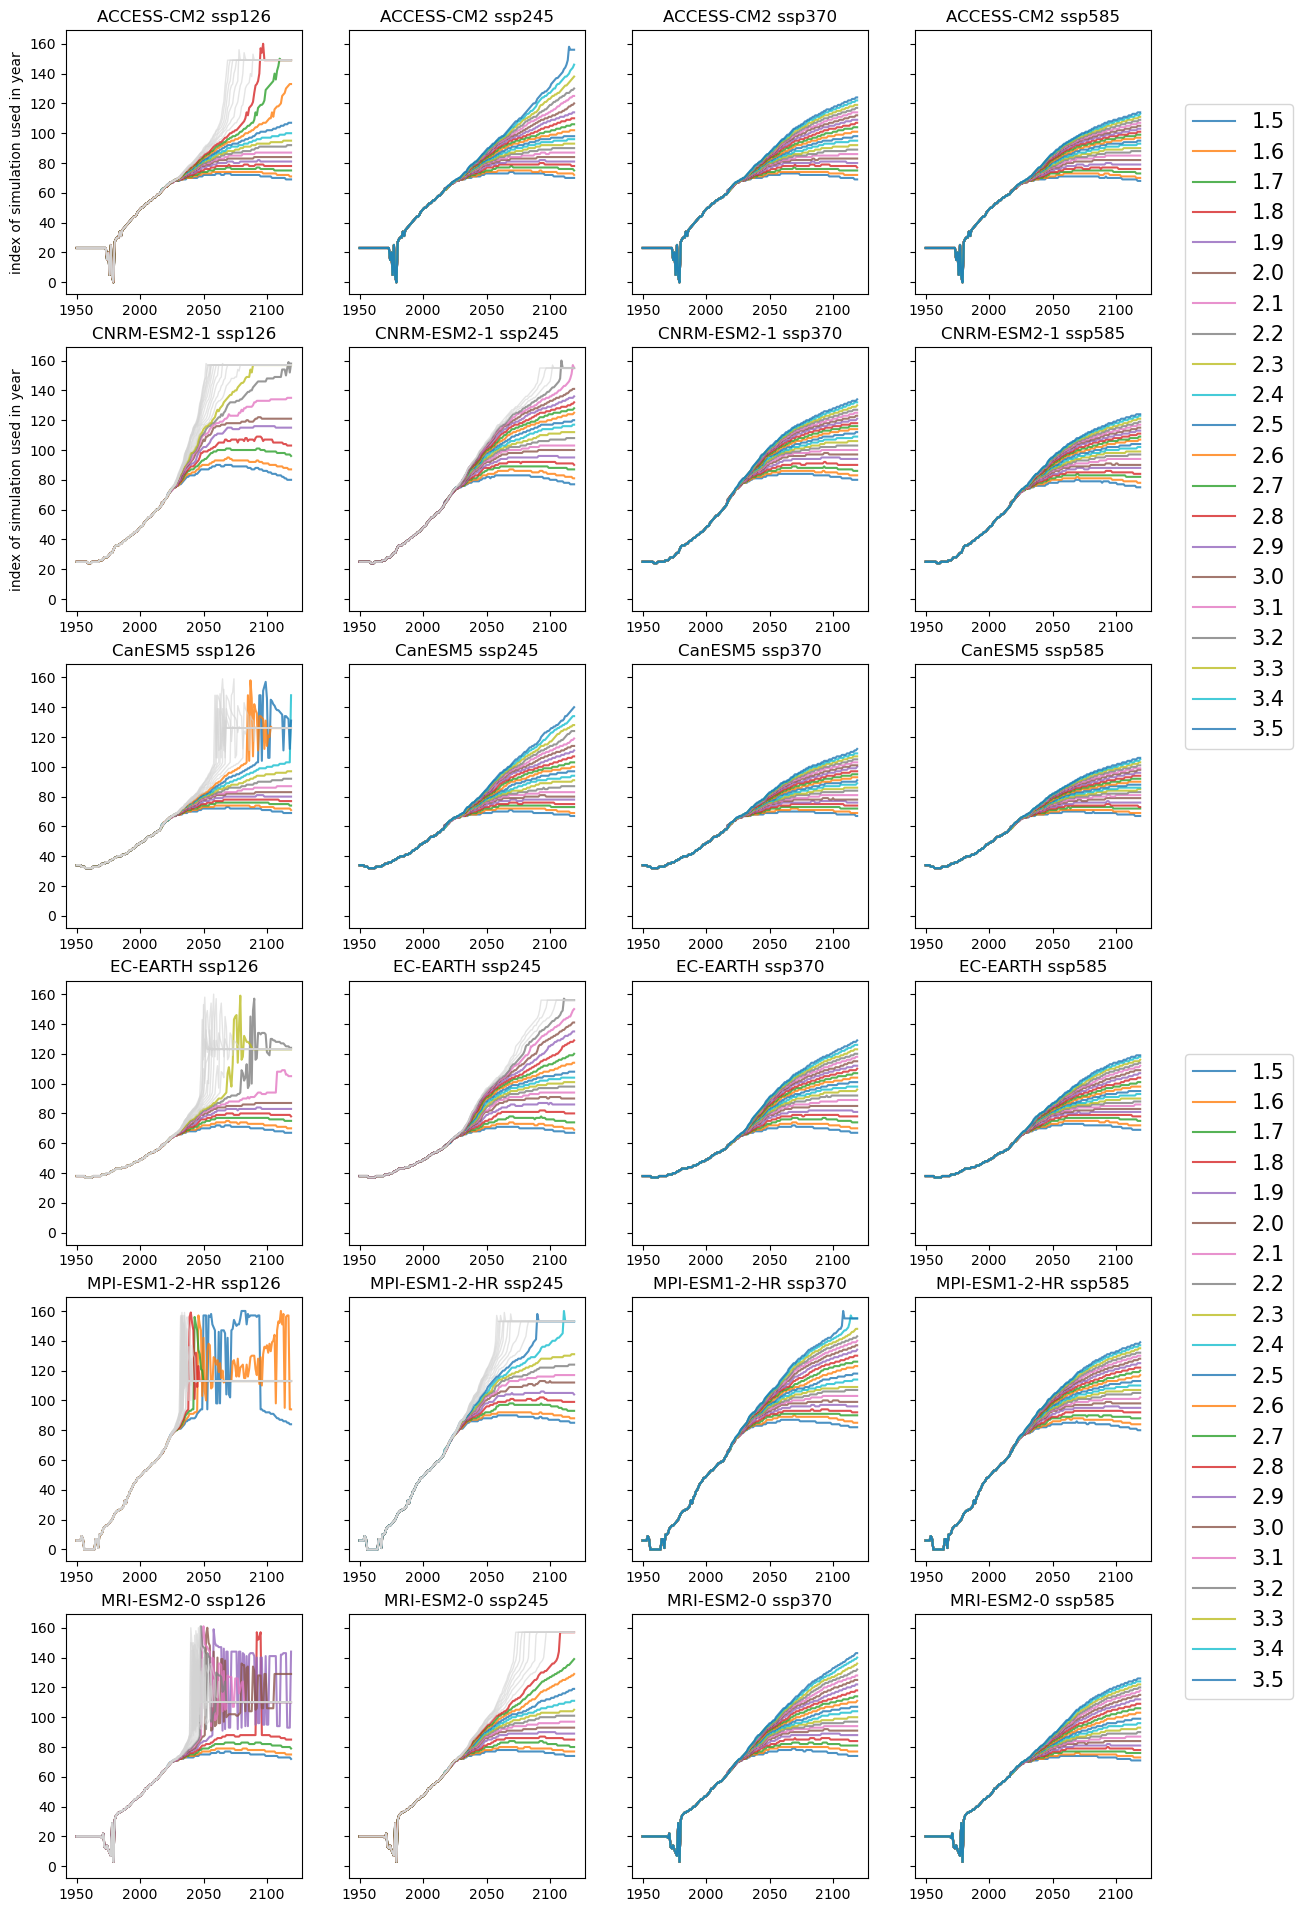

In [90]:

nrows=6

fig, axes = plt.subplots(nrows,4,figsize=(14,4*nrows),sharey=True)

axes=axes.flatten()

for i, ax in enumerate(axes):

    i+=1

    df_mapping = pd.DataFrame(data =d_climate_data_meta[i]['ind_RCP2GMT_strj'], columns=df_GMT_strj.columns, index=np.arange(1950,2120) )
    valid = np.array(d_climate_data_meta[i]['GMT_strj_valid'])  # your 0/1 array

    for col, is_valid in zip(df_mapping.columns, valid):
        if is_valid:
            ax.plot(df_mapping.index, df_mapping[col], lw=1.5, alpha=0.8,label=col)
        else:
            ax.plot(df_mapping.index, df_mapping[col], color='lightgray', lw=1.0, alpha=0.6)


    ax.set_title(d_climate_data_meta[i]['model']+' '+d_climate_data_meta[i]['scenario'])

    if i==1 or i==5:
        ax.set_ylabel('index of simulation used in year')
    
    if i==4 or i==16:
        ax.legend(loc='center left', bbox_to_anchor=(1.1, -0.5), fontsize=15)

### Sensitivity tests

1) Try threshold of .1 - doesnt help, just lots of scenarios lost 

In [21]:
d_climate_data_meta = load_climate_data(
    extremes = "FWI95d",                   # e.g. "FWI95d"
    model_names = GCMs,                # GCMs
    df_GMT_strj =df_GMT_strj ,                # stylized trajectories
    GMT_extra_trajectories = [df_GMT_15, df_GMT_20, df_GMT_NDC, df_GMT_OS, df_GMT_noOS],
    GMT_extra_trajectories_names = ['15', '20', 'NDC', 'OS', 'noOS'],
    climatedata_dir = '/vscmnt/brussel_pixiu_data/_data_brussel/vo/000/bvo00012/vsc10419/fwi-portugal/data/preprocessed/FWI',     # structure should be : climatedata_dir/scenario/model/'*{model}*{extreme}.nc
    filepath_model_gmst = os.path.join(data_dir, 'gmst-models/gmst_models_1850_2100_fwi.csv'),
    scenarios = scenarios,
    smoothing=True,
    rolling_window=21,
    min_periods=1,
    gmt_anomaly_baseline_period = (1985,2014),
    gmt_anomaly_correction = 0.74,
    year_start=1950,
    year_end = 2119,            # 2025 + max life expectancy
    gmt_mapping_method = 'year-to-year', 
    max_diff_valid = .1, 
    )

Processing climate data
Processing for FWI95d
Loading /vscmnt/brussel_pixiu_data/_data_brussel/vo/000/bvo00012/vsc10419/fwi-portugal/data/preprocessed/FWI/ssp126/ACCESS-CM2/FWI_ACCESS-CM2_2015_2100_FWI95d.nc
Loading /vscmnt/brussel_pixiu_data/_data_brussel/vo/000/bvo00012/vsc10419/fwi-portugal/data/preprocessed/FWI/historical/ACCESS-CM2/FWI_ACCESS-CM2_1950_2014_FWI95d.nc
Loading /vscmnt/brussel_pixiu_data/_data_brussel/vo/000/bvo00012/vsc10419/fwi-portugal/data/preprocessed/FWI/ssp245/ACCESS-CM2/FWI_ACCESS-CM2_2015_2100_FWI95d.nc
Loading /vscmnt/brussel_pixiu_data/_data_brussel/vo/000/bvo00012/vsc10419/fwi-portugal/data/preprocessed/FWI/historical/ACCESS-CM2/FWI_ACCESS-CM2_1950_2014_FWI95d.nc
Loading /vscmnt/brussel_pixiu_data/_data_brussel/vo/000/bvo00012/vsc10419/fwi-portugal/data/preprocessed/FWI/ssp370/ACCESS-CM2/FWI_ACCESS-CM2_2015_2100_FWI95d.nc
Loading /vscmnt/brussel_pixiu_data/_data_brussel/vo/000/bvo00012/vsc10419/fwi-portugal/data/preprocessed/FWI/historical/ACCESS-CM2/FWI_A

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


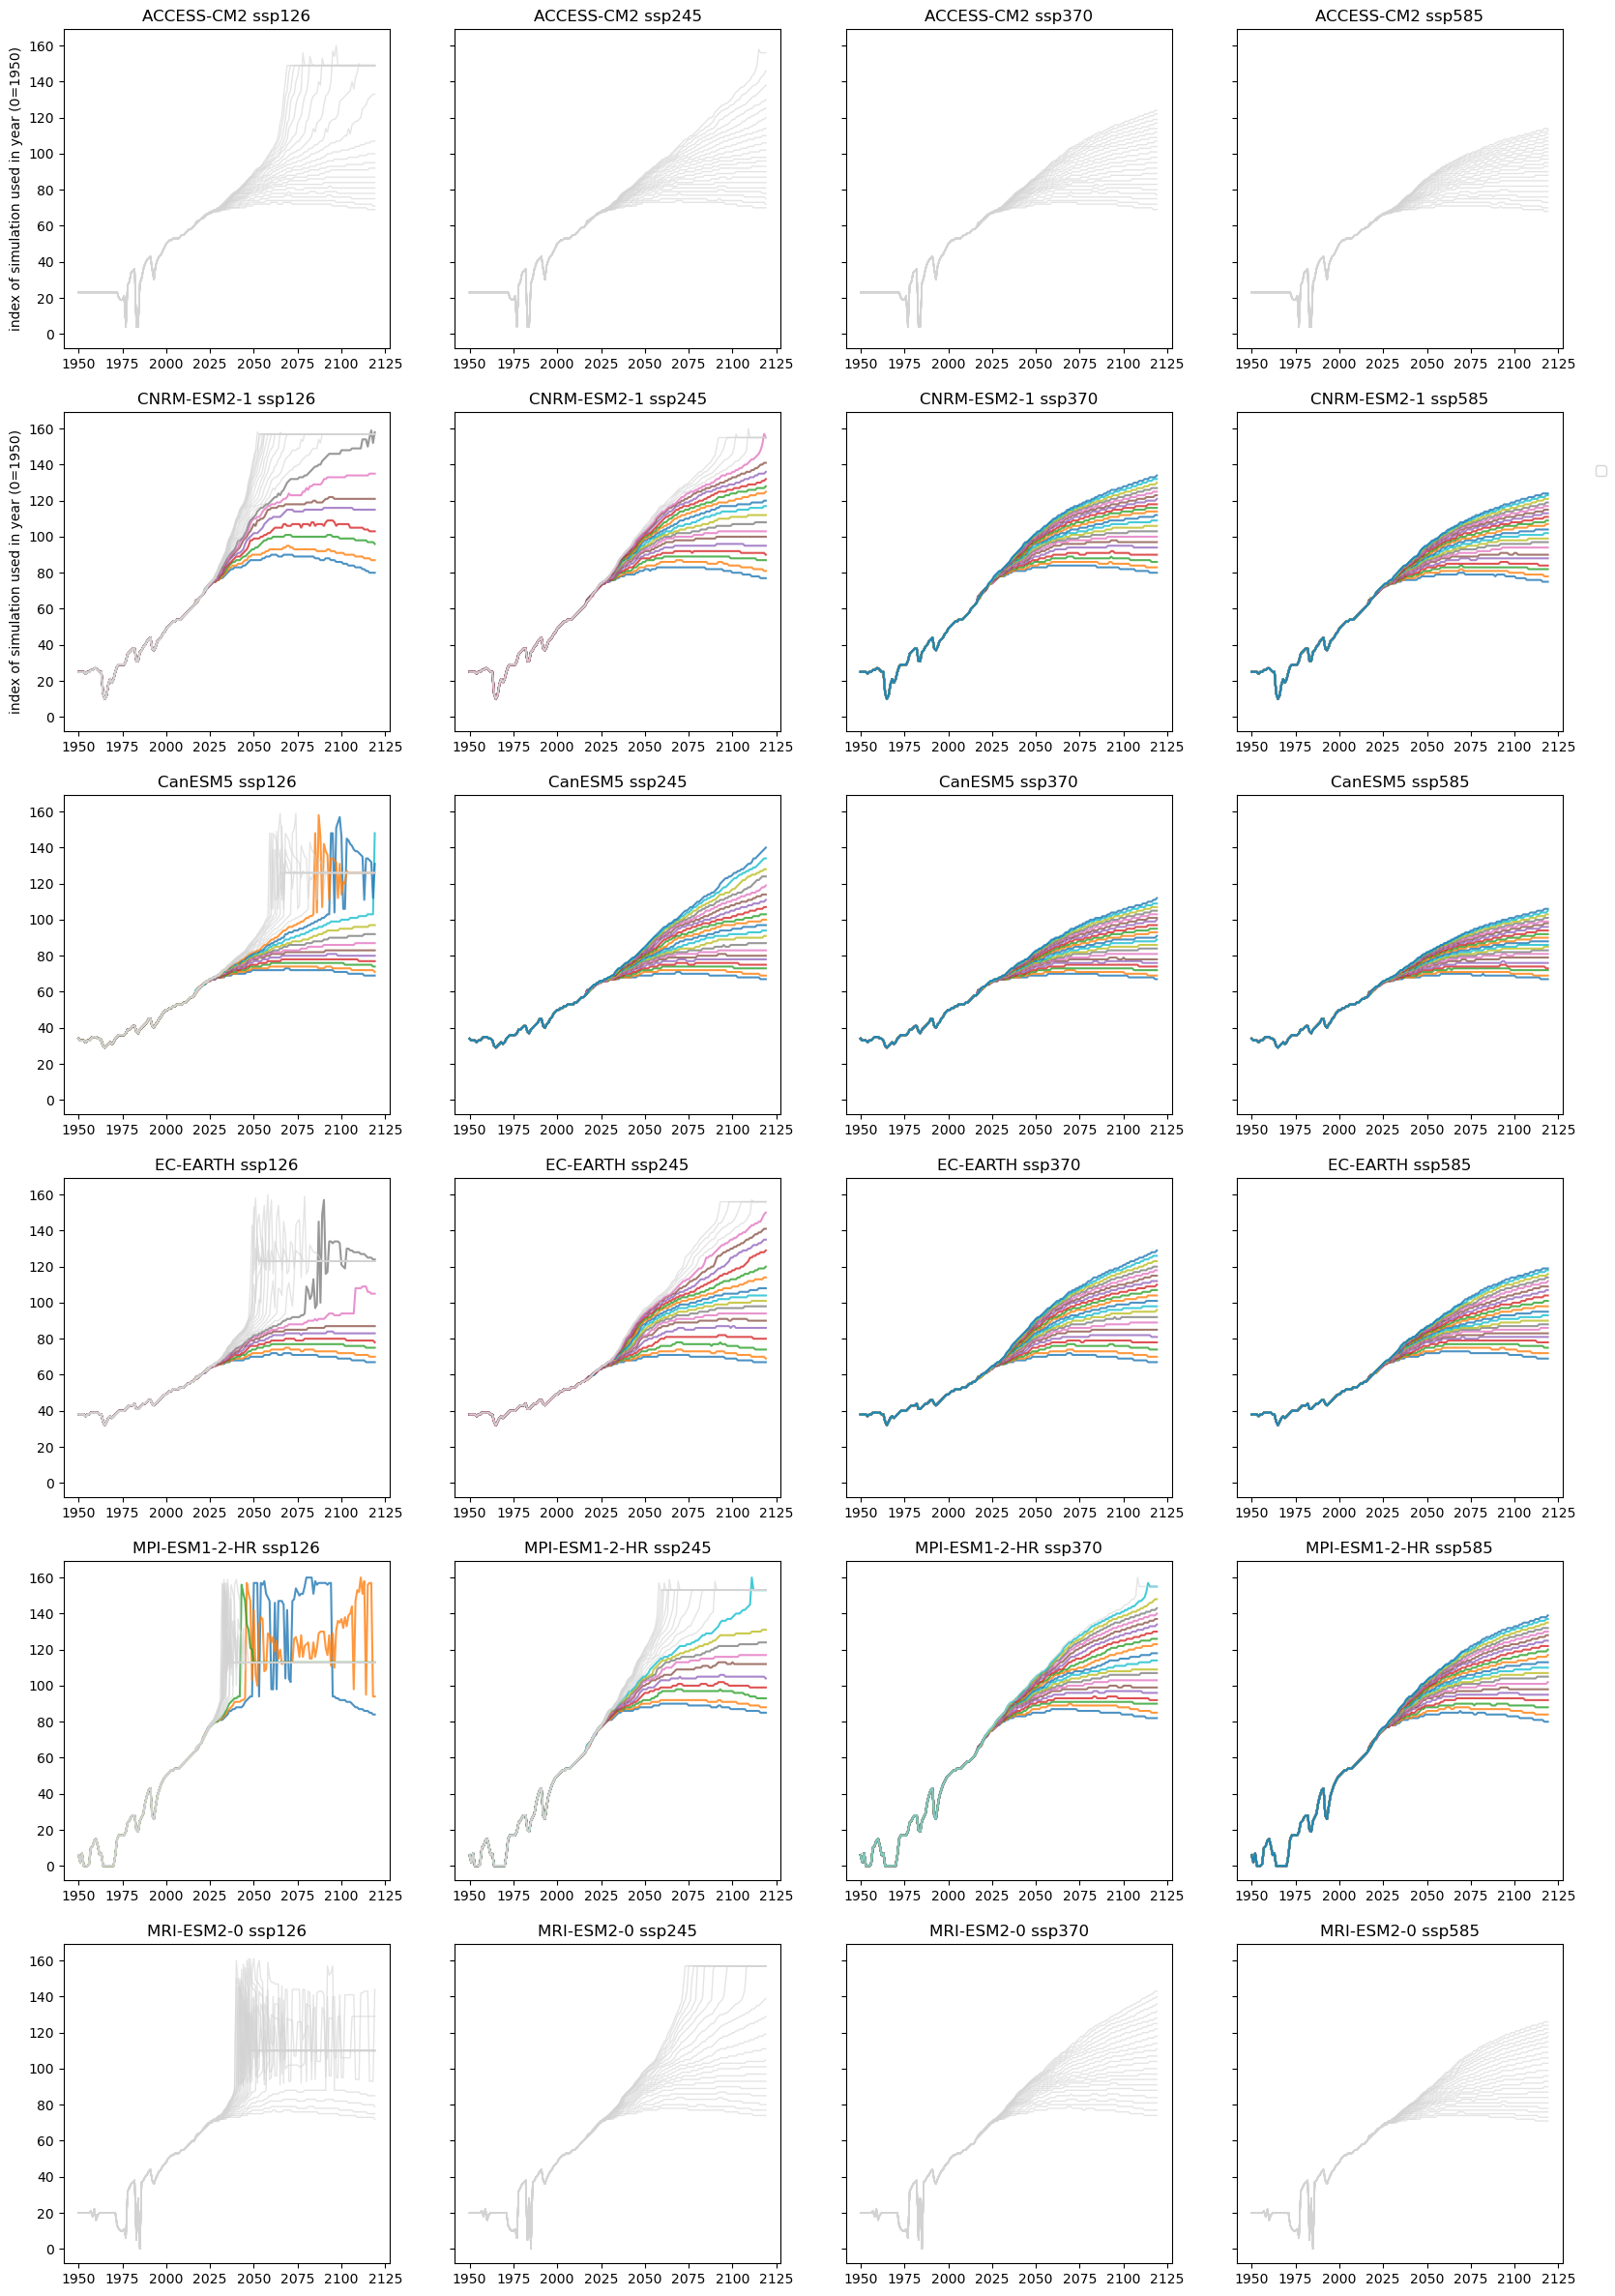

In [23]:
nrows=6

fig, axes = plt.subplots(nrows,4,figsize=(20,5*nrows),sharey=True)

axes=axes.flatten()

for i, ax in enumerate(axes):

    i+=1

    df_mapping = pd.DataFrame(data =d_climate_data_meta[i]['ind_RCP2GMT_strj'], columns=df_GMT_strj.columns, index=np.arange(1950,2120) )
    valid = np.array(d_climate_data_meta[i]['GMT_strj_valid'])  # your 0/1 array

    for col, is_valid in zip(df_mapping.columns, valid):
        if is_valid:
            ax.plot(df_mapping.index, df_mapping[col], lw=1.5, alpha=0.8,label=col)
        else:
            ax.plot(df_mapping.index, df_mapping[col], color='lightgray', lw=1.0, alpha=0.6)


    ax.set_title(d_climate_data_meta[i]['model']+' '+d_climate_data_meta[i]['scenario'])

    if i==1 or i==5:
        ax.set_ylabel('index of simulation used in year (0=1950)')
    
    if i==4:
        ax.legend(loc=(1.1,-.4))

# 3) Land fraction exposed

Done.

In [2]:

d_countries = preprocess_all_country_data(

    filepath_lifeexpectancy = filepath_lifeexpectancy, # life expectancy data
    start_birthyear=1950,
    end_birthyear=2025,                 # endyear is taken from end_birthyear + max life expectancy

    dir_cohortsizes = dir_cohortsizes,  # cohort size data
    data_source_cohorts='UNWPP2024',
    extend_method='linear',             # note, 'slinear' not implemented for UNWPP2024
    by_sex=False,                       # NOTE by_sex not implemented
                                            
    dir_population= dir_population,     # gridded pop data 
    ssp=2,
    urbanrural=False,                   # NOTE urbanrural not implemented for v2
    bbox = bbox_europe,                        # could use bbox europe!!

    filepath_countrymask = filepath_countrymask,    # country masks 
    data_source_countrymask = 'shapefile',
    fillcoast=False, 
    fix_smallislands=False,
    
    filepath_world_bank = filepath_world_bank_meta, # metadata 
    filepath_lookuptable = filepath_lookuptable,    # country filtering
    filter_countries=True,
    worldbank_filter=True, 
    )


load_country_metadata took 0.10 s


load_unwpp_lifeexpectancy took 27.43 s
get_life_expectancies took 0.00 s
loading cohort sizes from UNWPP2024
load_cohort_sizes took 27.01 s
interpolate_cohortsize_countries took 0.01 s
opening compass - historical
opening compass - ssp2
load_population took 3.19 s
load_countrymask took 2.67 s
preprocess_all_country_data took 60.47 s


In [3]:
df_countries = d_countries['info_pop']
gdf_country_borders = d_countries['borders'] 
da_regions = df_countries['region'].unique()
da_population = d_countries['population_map']
df_birthyears = d_countries['birth_years'] # NA
df_life_expectancy_5 = d_countries['life_expectancy_5']
da_cohort_size = d_countries['cohort_size']
countries_regions, countries_mask = d_countries['mask'] 

In [5]:
df_GMT_15, df_GMT_20, df_GMT_NDC, df_GMT_OS, df_GMT_noOS, ds_GMT_STS, df_GMT_strj = load_GMT(
    year_start=1950,
    year_end=2119,
    gmt_extend_method='10yrtrend',
    smooth_first_decades=False

)

load_GMT took 21.22 s


In [6]:
GCMs = ['ACCESS-CM2', 'CNRM-ESM2-1', 'CanESM5', 'EC-EARTH', 'MPI-ESM1-2-HR', 'MRI-ESM2-0']
scenarios = ['ssp126', 'ssp245', 'ssp370', 'ssp585']
GMT_extra_trajectories_names = ['15', '20', 'NDC', 'OS', 'noOS']
climatedata_dir = '/vscmnt/brussel_pixiu_data/_data_brussel/vo/000/bvo00012/vsc10419/fwi-portugal/data/preprocessed/FWI'

d_climate_data_meta = load_climate_data(
    extremes = "FWI95d",                   # e.g. "FWI95d"
    model_names = GCMs[0:2],                # GCMs
    df_GMT_strj =df_GMT_strj ,                # stylized trajectories
    GMT_extra_trajectories = [df_GMT_15, df_GMT_20, df_GMT_NDC, df_GMT_OS, df_GMT_noOS],
    GMT_extra_trajectories_names = ['15', '20', 'NDC', 'OS', 'noOS'],
    climatedata_dir = '/vscmnt/brussel_pixiu_data/_data_brussel/vo/000/bvo00012/vsc10419/fwi-portugal/data/preprocessed/FWI',     # structure should be : climatedata_dir/scenario/model/'*{model}*{extreme}.nc
    filepath_model_gmst = os.path.join(data_dir, 'gmst-models/gmst_models_1850_2100_fwi.csv'),
    scenarios = scenarios,
    smoothing=True,
    rolling_window=21,
    min_periods=1,
    gmt_anomaly_baseline_period = (1985,2014),
    gmt_anomaly_correction = 0.74,
    year_start=1950,
    year_end = 2119,            # 2025 + max life expectancy
    gmt_mapping_method = 'year-to-year', 
    max_diff_valid = .2, 
    )

Processing climate data
Processing for FWI95d


In [7]:
len(d_climate_data_meta)

8

## develop



### dev: ds_regions object + ds with land frac exposed

- Try to make ds_regions object automatically from the data, that is used in calc_landfraction_exposed ! > DONE


In [6]:
# check old object

ds_regions = pk.load(open('/vscmnt/brussel_pixiu_data/_data_brussel/vo/000/bvo00012/vsc10419/Source2Suffering/data/pickles_S2S_dem4cli/country/ds_regions.pkl', 'rb'))

In [7]:
ds_regions['name']

<xarray.DataArray 'name' (region: 12)>
array(['East Asia & Pacific', 'Europe & Central Asia', 'High income',
       'Latin America & Caribbean', 'Low income', 'Lower middle income',
       'Middle East & North Africa', 'North America', 'South Asia',
       'Sub-Saharan Africa', 'Upper middle income', 'World'], dtype=object)
Coordinates:
  * region   (region) int64 0 1 2 3 4 5 6 7 8 9 10 11

In [8]:
df_countries

,abbreviation,region,incomegroup,country_code,SSP name,name,population
name,,,,,,,
Afghanistan,AFG,South Asia,Low income,4,Afghanistan,Afghanistan,4.485156e+07
Albania,ALB,Europe & Central Asia,Upper middle income,8,Albania,Albania,2.585156e+06
Algeria,DZA,Middle East & North Africa,Upper middle income,12,Algeria,Algeria,4.531977e+07
Angola,AGO,Sub-Saharan Africa,Lower middle income,24,Angola,Angola,2.623632e+07
Argentina,ARG,Latin America & Caribbean,Upper middle income,32,Argentina,Argentina,4.580178e+07
...,...,...,...,...,...,...,...
United States Virgin Islands,VIR,Latin America & Caribbean,High income,850,United States Virgin Islands,United States Virgin Islands,4.068623e+04
State of Palestine,PSE,Middle East & North Africa,Lower middle income,275,Palestine,State of Palestine,6.316836e+06
Yemen,YEM,Middle East & North Africa,Low income,887,Yemen,Yemen,3.761490e+07


In [9]:
gdf_country_borders

,geometry,region,abbreviation
name,,,
Afghanistan,"POLYGON ((71.04980 38.40866, 71.05714 38.40903...",South Asia,AFG
Albania,"POLYGON ((19.74777 42.57890, 19.74601 42.57993...",Europe & Central Asia,ALB
Algeria,"POLYGON ((8.60251 36.93951, 8.60566 36.91305, ...",Middle East & North Africa,DZA
Angola,"MULTIPOLYGON (((11.73752 -16.69258, 11.73851 -...",Sub-Saharan Africa,AGO
Argentina,"MULTIPOLYGON (((-68.65412 -54.88624, -68.65414...",Latin America & Caribbean,ARG
...,...,...,...
United States Virgin Islands,"MULTIPOLYGON (((-64.73078 17.76529, -64.70971 ...",Latin America & Caribbean,VIR
State of Palestine,"MULTIPOLYGON (((34.26440 31.22419, 34.24835 31...",Middle East & North Africa,PSE
Yemen,"MULTIPOLYGON (((53.30824 12.11839, 53.31027 12...",Middle East & North Africa,YEM


In [10]:
countries_mask

<xarray.DataArray 'mask' (lat: 360, lon: 720)>
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]])
Coordinates:
  * lat      (lat) float64 89.75 89.25 88.75 88.25 ... -88.75 -89.25 -89.75
  * lon      (lon) float64 -179.8 -179.2 -178.8 -178.2 ... 178.8 179.2 179.8
Attributes:
    standard_name:  region
    flag_values:    [  1   2   3   5   6   7  10  11  12  13  14  15  16  17 ...
    flag_meanings:  AFG AGO ALB ARE ARG ARM AUS AUT AZE BDI BEL BEN BFA BGD B...

In [11]:
countries_regions

<regionmask.Regions 'country'>
overlap:  None

Regions:
  0 ABW        Aruba
  1 AFG  Afghanistan
  2 AGO       Angola
  3 ALB      Albania
  4 AND      Andorra
 ..  ..          ...
212 WSM        Samoa
213 YEM        Yemen
214 ZAF South Africa
215 ZMB       Zambia
216 ZWE     Zimbabwe

[217 regions]

In [12]:
df_countries['region'].unique()

array(['South Asia', 'Europe & Central Asia',
       'Middle East & North Africa', 'Sub-Saharan Africa',
       'Latin America & Caribbean', 'East Asia & Pacific',
       'North America'], dtype=object)

In [13]:
df_countries['incomegroup'].dropna().unique()

array(['Low income', 'Upper middle income', 'Lower middle income',
       'High income'], dtype=object)

In [15]:
df_countries.region.unique()

array(['South Asia', 'Europe & Central Asia',
       'Middle East & North Africa', 'Sub-Saharan Africa',
       'Latin America & Caribbean', 'East Asia & Pacific',
       'North America'], dtype=object)

In [6]:
# new see in landfrac exposed also !

region_names = np.concatenate([df_countries['region'].dropna().unique(),
                        df_countries['incomegroup'].dropna().unique(),
                        ['World']
])
region_names

array(['Europe & Central Asia', 'Middle East & North Africa',
       'Upper middle income', 'High income', 'Lower middle income',
       'World'], dtype=object)

In [7]:
year_start=1950
year_end=2119
GMT_extra_trajectories_names = ['15', '20', 'NDC', 'OS', 'noOS']

In [8]:
# 1) Build Dataset for regions result

region_names = np.concatenate([df_countries['region'].dropna().unique(),
                        df_countries['incomegroup'].dropna().unique(),
                        ['World']
])

nregions = len(region_names)


year_range = np.arange(year_start, year_end)

# Shared shape for all variables
shape = (len(d_climate_data_meta), nregions, len(year_range))

# Build the data_vars dictionary in a loop
data_vars = {}
var_suffixes = GMT_extra_trajectories_names
for suffix in var_suffixes:
    var_name = f'landfrac_peryear_perregion_{suffix}'
    data_vars[var_name] = (
        ['run', 'region', 'time_ind'],
        np.full(shape, np.nan)
    )

# Build the dataset
ds_lfe_perregion_perrun = xr.Dataset(
    data_vars=data_vars,
    coords={
        'run': ('run', np.arange(1, len(d_climate_data_meta) + 1)),
        'region': ('region', np.arange(0, nregions)),
        'time_ind': ('time_ind', np.arange(0, len(year_range), 1))
    }
)


# 2) Build Dataset for country result


# Shared shape for all variables
shape = (
    len(d_climate_data_meta),
    len(df_countries['name'].values),
    len(np.arange(0, len(year_range), 1))
)

# Build the data_vars dictionary in a loop
data_vars = {}
for suffix in var_suffixes:
    var_name = f'landfrac_peryear_percountry_{suffix}'
    data_vars[var_name] = (
        ['run', 'country', 'time_ind'],
        np.full(shape, np.nan)
    )

# Build the dataset
ds_lfe_percountry_perrun = xr.Dataset(
    data_vars=data_vars,
    coords={
        'run': ('run', np.arange(1, len(d_climate_data_meta) + 1)),
        'country': ('country', df_countries['name'].values),
        'time_ind': ('time_ind', np.arange(0, len(year_range), 1))
    }
)



In [9]:
ds_lfe_percountry_perrun

<xarray.Dataset>
Dimensions:                           (run: 8, country: 52, time_ind: 169)
Coordinates:
  * run                               (run) int64 1 2 3 4 5 6 7 8
  * country                           (country) object 'Albania' ... 'United ...
  * time_ind                          (time_ind) int64 0 1 2 3 ... 166 167 168
Data variables:
    landfrac_peryear_percountry_15    (run, country, time_ind) float64 nan .....
    landfrac_peryear_percountry_20    (run, country, time_ind) float64 nan .....
    landfrac_peryear_percountry_NDC   (run, country, time_ind) float64 nan .....
    landfrac_peryear_percountry_OS    (run, country, time_ind) float64 nan .....
    landfrac_peryear_percountry_noOS  (run, country, time_ind) float64 nan .....

In [10]:
ds_lfe_perregion_perrun

<xarray.Dataset>
Dimensions:                          (run: 8, region: 6, time_ind: 169)
Coordinates:
  * run                              (run) int64 1 2 3 4 5 6 7 8
  * region                           (region) int64 0 1 2 3 4 5
  * time_ind                         (time_ind) int64 0 1 2 3 ... 166 167 168
Data variables:
    landfrac_peryear_perregion_15    (run, region, time_ind) float64 nan ... nan
    landfrac_peryear_perregion_20    (run, region, time_ind) float64 nan ... nan
    landfrac_peryear_perregion_NDC   (run, region, time_ind) float64 nan ... nan
    landfrac_peryear_perregion_OS    (run, region, time_ind) float64 nan ... nan
    landfrac_peryear_perregion_noOS  (run, region, time_ind) float64 nan ... nan

### dev: calc exposure

In [12]:
def get_countries_of_region(
    region, 
    df_countries,
): 

    # Get list of member countries from region
    member_countries = df_countries.loc[df_countries['region']==region]['name'].values

    # not region but income group
    if len(member_countries) == 0: 
        member_countries = df_countries.loc[df_countries['incomegroup']==region]['name'].values

    # get all countries for the world
    if region == 'World':
        member_countries = df_countries['name'].values

    return member_countries 



#%%




In [84]:

@timeit
def load_climate_data_array(climatedata_dir,
                    scenario,
                    model,
                    extreme,
                    startyear,
                    endyear,
                    bbox=None
                    ):

    # Auxiliary function to slice  dataset to a particular region and time 
    def cut_to_region_time(da):
        # rename for compatibility with population objects
        if 'latitude' in da.coords:
            da = da.rename({'latitude':'lat', 'longitude':'lon'})
        # slice time
        if da.time.dtype == 'datetime64[ns]':
            da['time'] = da['time'].dt.year
        else:
            da['time'] = da['time'].astype(int) + startyear_ssp
        # cut space
        if bbox is None:
            return da.sel(time=slice(startyear, endyear))
        latmin, latmax, lonmin, lonmax = bbox 
        if da.lat.values[0] < da.lat.values[-1]: # check if lat is increasing or decreasing
            return da.sel(
                lat=slice(latmin, latmax), lon=slice(lonmin, lonmax), time=slice(startyear, endyear)
                )
        else:
            return da.sel(
                lat=slice(latmax, latmin), lon=slice(lonmin, lonmax), time=slice(startyear, endyear)
                )

    # Load climate data: annual count of exceedances of threshold
    # TODO: remove this from load_cliamte_data()

    # filepath = glob.glob(os.path.join(climatedata_dir, scenario, model, f'*{model}*{extreme}.nc'))[0]
    # print(f'Loading {filepath}')
    # da_rcp = xr.open_dataarray(filepath,chunks='auto')

    # #load associated historical variable
    # filepath = glob.glob(os.path.join(climatedata_dir, 'historical', model, f'*{model}*{extreme}.nc'))[0]
    # print(f'Loading {filepath}')
    # da_hist = xr.open_dataarray(filepath,chunks='auto')

    # # concat (AFA = area fraction affected, binary data yes/no affected)
    # da_AFA = xr.concat([da_hist,da_rcp], dim='time')
    # da_AFA['time'] = da_AFA.time.dt.year
    
    filepath_hist = glob.glob(os.path.join(climatedata_dir, 'historical', model, f'*{model}*{extreme}.nc'))[0]
    filepath_rcp = glob.glob(os.path.join(climatedata_dir, scenario, model, f'*{model}*{extreme}.nc'))[0]
    print(f'Loading {filepath_hist}')
    print(f'Loading {filepath_rcp}')
    da_AFA = xr.open_mfdataset(
                [filepath_hist, filepath_rcp],
                combine='nested',
                concat_dim='time',
                decode_coords='all',
                preprocess=cut_to_region_time,
            )
    VAR = list(da_AFA.data_vars)[0]
    da_AFA = da_AFA[VAR]

    # 4) if needed, repeat mean of last 10 years until entire period of interest is covered - NOTE: do you need da_AFA here??? you're not using it in this fxn
    if da_AFA.time.max() < year_end: 
        da_AFA_lastyear = da_AFA.isel(time=slice(-10, None)).mean(dim='time').expand_dims(dim='time',axis=0)
        for year in range(da_AFA.time.max().values+1,year_end+1): 
            da_AFA = xr.concat([da_AFA,da_AFA_lastyear.assign_coords(time = [year])], dim='time')
            
    # # retain only period of interest
    # da_AFA = da_AFA.sel(time=slice(year_start,year_end))



    return da_AFA

In [ ]:

def calc_weighted_fldmean(
    da, 
    countries_mask,
    ind_country, 
    weights=None,
    areaweighted=False
):
    def get_lat_name(da):
        """Figure out what is the latitude coordinate for each dataset."""
        for lat_name in ['lat', 'latitude']:
            if lat_name in da.coords:
                return lat_name
        raise RuntimeError("Couldn't find a latitude coordinate")
    
    def weighted_mean(da, weights, areaweighted):
        """Return weighted mean of dataarray."""
        if weights is not None:
            # weight the AFA of the country under study by the size of its population over time at the grid cell or provide gridcell area file 
            # slice to save memory on alignment 
            if "time" in weights.dims:
                weights = weights.sel(time=da_masked.time)
        elif areaweighted: 
            lat = da[get_lat_name(da)]
            weights = np.cos(np.deg2rad(lat))        
        other_dims = set(da.dims) - {'time'}
        return da_masked.weighted(weights).mean(other_dims,skipna=True).reset_coords(drop=True)

    # match grids
    da = da.interp_like(countries_mask, method='linear')

    # only keeps the AFA data for the country under study, for the others a NaN value is attributed
    #if len(ind_country) == 1: 
    if np.isscalar(ind_country):

        da_masked = da.where(countries_mask == ind_country)
    
    # if more countries are provided, combine the different masks 
    elif len(ind_country) > 1:
        
        mask = countries_mask.isin(ind_country)
        da_masked = da.where(mask)

    da_weighted_fldmean = weighted_mean(da_masked, weights, areaweighted)

    del da_masked

    return da_weighted_fldmean

In [89]:
da_AFA = load_climate_data_array(    climatedata_dir = '/vscmnt/brussel_pixiu_data/_data_brussel/vo/000/bvo00012/vsc10419/fwi-portugal/data/preprocessed/FWI',     # structure should be : climatedata_dir/scenario/model/'*{model}*{extreme}.nc

                    scenario=scenarios[0],
                    model=GCMs[0],
                    extreme="FWI95d",
                    startyear=1950,
                    endyear=2119,
                    bbox=bbox_europe)

Loading /vscmnt/brussel_pixiu_data/_data_brussel/vo/000/bvo00012/vsc10419/fwi-portugal/data/preprocessed/FWI/historical/ACCESS-CM2/FWI_ACCESS-CM2_1950_2014_FWI95d.nc
Loading /vscmnt/brussel_pixiu_data/_data_brussel/vo/000/bvo00012/vsc10419/fwi-portugal/data/preprocessed/FWI/ssp126/ACCESS-CM2/FWI_ACCESS-CM2_2015_2100_FWI95d.nc
load_climate_data_array took 0.09 s


In [90]:
da_AFA 

<xarray.DataArray 'FWI95d' (time: 170, lat: 391, lon: 499)>
dask.array<concatenate, shape=(170, 391, 499), dtype=float64, chunksize=(86, 391, 499), chunktype=numpy.ndarray>
Coordinates:
  * lon       (lon) float64 -14.86 -14.76 -14.66 -14.56 ... 34.74 34.84 34.94
  * lat       (lat) float64 70.99 70.89 70.79 70.69 ... 32.29 32.19 32.09 31.99
    quantile  float64 0.95
  * time      (time) int64 1950 1951 1952 1953 1954 ... 2115 2116 2117 2118 2119

In [91]:
da_population.lat.values

array([32.05, 32.15, 32.25, 32.35, 32.45, 32.55, 32.65, 32.75, 32.85,
       32.95, 33.05, 33.15, 33.25, 33.35, 33.45, 33.55, 33.65, 33.75,
       33.85, 33.95, 34.05, 34.15, 34.25, 34.35, 34.45, 34.55, 34.65,
       34.75, 34.85, 34.95, 35.05, 35.15, 35.25, 35.35, 35.45, 35.55,
       35.65, 35.75, 35.85, 35.95, 36.05, 36.15, 36.25, 36.35, 36.45,
       36.55, 36.65, 36.75, 36.85, 36.95, 37.05, 37.15, 37.25, 37.35,
       37.45, 37.55, 37.65, 37.75, 37.85, 37.95, 38.05, 38.15, 38.25,
       38.35, 38.45, 38.55, 38.65, 38.75, 38.85, 38.95, 39.05, 39.15,
       39.25, 39.35, 39.45, 39.55, 39.65, 39.75, 39.85, 39.95, 40.05,
       40.15, 40.25, 40.35, 40.45, 40.55, 40.65, 40.75, 40.85, 40.95,
       41.05, 41.15, 41.25, 41.35, 41.45, 41.55, 41.65, 41.75, 41.85,
       41.95, 42.05, 42.15, 42.25, 42.35, 42.45, 42.55, 42.65, 42.75,
       42.85, 42.95, 43.05, 43.15, 43.25, 43.35, 43.45, 43.55, 43.65,
       43.75, 43.85, 43.95, 44.05, 44.15, 44.25, 44.35, 44.45, 44.55,
       44.65, 44.75,

In [92]:
da_AFA.lat.values.round(2)

# not exactly same grid!!

array([70.99, 70.89, 70.79, 70.69, 70.59, 70.49, 70.39, 70.29, 70.19,
       70.09, 69.99, 69.89, 69.79, 69.69, 69.59, 69.49, 69.39, 69.29,
       69.19, 69.09, 68.99, 68.89, 68.79, 68.69, 68.59, 68.49, 68.39,
       68.29, 68.19, 68.09, 67.99, 67.89, 67.79, 67.69, 67.59, 67.49,
       67.39, 67.29, 67.19, 67.09, 66.99, 66.89, 66.79, 66.69, 66.59,
       66.49, 66.39, 66.29, 66.19, 66.09, 65.99, 65.89, 65.79, 65.69,
       65.59, 65.49, 65.39, 65.29, 65.19, 65.09, 64.99, 64.89, 64.79,
       64.69, 64.59, 64.49, 64.39, 64.29, 64.19, 64.09, 63.99, 63.89,
       63.79, 63.69, 63.59, 63.49, 63.39, 63.29, 63.19, 63.09, 62.99,
       62.89, 62.79, 62.69, 62.59, 62.49, 62.39, 62.29, 62.19, 62.09,
       61.99, 61.89, 61.79, 61.69, 61.59, 61.49, 61.39, 61.29, 61.19,
       61.09, 60.99, 60.89, 60.79, 60.69, 60.59, 60.49, 60.39, 60.29,
       60.19, 60.09, 59.99, 59.89, 59.79, 59.69, 59.59, 59.49, 59.39,
       59.29, 59.19, 59.09, 58.99, 58.89, 58.79, 58.69, 58.59, 58.49,
       58.39, 58.29,

In [93]:
countries_mask

<xarray.DataArray 'mask' (lat: 391, lon: 499)>
array([[nan, nan, nan, ..., nan, 93., 93.],
       [nan, nan, nan, ..., nan, nan, 93.],
       [nan, nan, nan, ..., nan, nan, 93.],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]])
Coordinates:
  * lat      (lat) float64 32.05 32.15 32.25 32.35 ... 70.75 70.85 70.95 71.05
  * lon      (lon) float64 -14.95 -14.85 -14.75 -14.65 ... 34.65 34.75 34.85
Attributes:
    standard_name:  region
    flag_values:    [  3   4  11  14  18  21  22  33  47  48  49  52  54  58 ...
    flag_meanings:  ALB AND AUT BEL BGR BIH BLR CHE CYP CZE DEU DNK DZA ESP E...

In [94]:
region=region_names[0]

countries = get_countries_of_region(region, df_countries)
print(region)

Europe & Central Asia


In [95]:
countries

array(['Albania', 'Andorra', 'Austria', 'Belarus', 'Belgium',
       'Bosnia and Herzegovina', 'Bulgaria', 'Croatia', 'Cyprus',
       'Czechia', 'Denmark', 'Estonia', 'Faroe Islands', 'Finland',
       'France', 'Germany', 'Greece', 'Hungary', 'Iceland', 'Ireland',
       'Isle of Man', 'Italy', 'Kosovo (under UNSC res. 1244)', 'Latvia',
       'Liechtenstein', 'Lithuania', 'Luxembourg', 'Republic of Moldova',
       'Montenegro', 'Netherlands', 'North Macedonia', 'Norway', 'Poland',
       'Portugal', 'Romania', 'Russian Federation', 'San Marino',
       'Serbia', 'Slovakia', 'Slovenia', 'Spain', 'Sweden', 'Switzerland',
       'Türkiye', 'Ukraine', 'United Kingdom'], dtype=object)

In [96]:
len(countries)

46

In [97]:
ind_country = countries_regions.map_keys(countries)
ind_country

[3,
 4,
 11,
 14,
 18,
 21,
 22,
 33,
 47,
 48,
 49,
 52,
 58,
 59,
 61,
 63,
 64,
 67,
 75,
 83,
 85,
 87,
 89,
 92,
 94,
 105,
 112,
 115,
 116,
 117,
 122,
 127,
 131,
 144,
 145,
 156,
 159,
 164,
 165,
 175,
 177,
 180,
 181,
 182,
 197,
 202]

In [98]:


da_weighted_region = calc_weighted_fldmean(
    da_AFA, 
    countries_mask,
    ind_country, 
    weights=None,
    areaweighted=True
).compute()

calc_weighted_fldmean took 0.02 s


In [99]:
da_weighted_region

<xarray.DataArray 'FWI95d' (time: 170)>
array([17.31233949, 15.91291682, 26.96916461, 17.4565478 , 17.63860629,
       12.98211787, 23.2897601 ,  9.74691301,  9.61371817, 16.20497287,
       14.51276555, 12.48203592, 13.51647428, 14.26905722, 16.01789435,
       10.40583982, 11.19317666, 13.0925282 , 13.46759926,  9.45930687,
        9.51317753, 15.16388622, 11.10961825, 14.52554476, 14.18742874,
       23.92358803, 23.61316874, 11.67631876, 11.01192581, 18.91341925,
       15.19134839, 11.78829914, 12.56226768, 12.48444276, 14.23668887,
       12.75566912,  7.67256158, 14.70940518, 23.80208462, 17.4246569 ,
       17.18323166, 14.71061638, 11.3758735 , 18.95224311, 17.09809909,
        9.62117047, 17.59180786, 21.00825051, 16.16031186, 15.03781687,
       21.21172927, 13.17868341, 22.70295029, 25.20987586, 16.61161594,
       18.60830964, 13.3095182 , 15.75708525, 21.9600806 , 21.93494305,
       22.36728539, 22.25073621, 15.33025071, 25.8122039 , 24.77852746,
       22.07593406, 16.41269277, 20.68842254, 22.83679786, 26.08579513,
       28.87995075, 20.20397166, 26.96846512, 34.75854366, 30.34744882,
       23.06027441, 25.5555835 , 23.23275661, 21.82390051, 34.22663234,
       25.37104392, 21.37271647, 29.80857481, 26.979551  , 31.26968503,
       43.89939082, 27.87675632, 29.95626979, 31.43709991, 31.85461185,
       21.55175111, 33.68765051, 51.41302992, 32.48252452, 30.13989149,
       25.78244673, 23.66466027, 19.7445864 , 29.69064815, 25.49334801,
       34.38850735, 23.29405321, 32.62407851, 22.93863854, 14.903334  ,
       29.70258689, 22.40773868, 41.66309329, 30.607886  , 41.41820588,
       23.54143182, 31.27702971, 36.84454267, 23.33472155, 35.15628604,
       32.8013407 , 37.24074787, 36.4373368 , 28.81398635, 25.06581904,
       33.25981595, 23.22659414, 31.83696712, 51.61209235, 29.30910036,
       22.84995698, 24.99597761, 29.72988517, 21.94469566, 41.68124813,
       46.84025733, 36.0493643 , 33.44597033, 30.4287128 , 31.08137428,
       27.56067611, 27.72591866, 32.57908381, 26.65564252, 37.20429008,
       33.12539492, 33.41214473, 26.69585625, 43.38262865, 29.40004528,
       41.42001021, 40.48957481, 38.66252495, 34.16754463, 27.14558935,
       29.00328301, 34.37792019, 34.37792019, 34.37792019, 34.37792019,
       34.37792019, 34.37792019, 34.37792019, 34.37792019, 34.37792019,
       34.37792019, 34.37792019, 34.37792019, 34.37792019, 34.37792019,
       34.37792019, 34.37792019, 34.37792019, 34.37792019, 34.37792019])
Coordinates:
  * time     (time) int64 1950 1951 1952 1953 1954 ... 2115 2116 2117 2118 2119

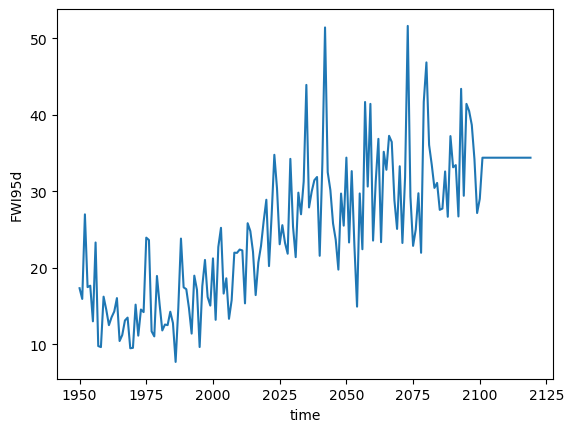

In [100]:
da_weighted_region.plot()

### dev: reindex / remapping

In [ ]:


# 1) Build Dataset for regions result

# get regions and income groups and 'World' (=all countries)
region_names = np.concatenate([df_countries['region'].dropna().unique(),
                        df_countries['incomegroup'].dropna().unique(),
                        ['World'] # not sure how useful to keep 'World' if you are using a bbox! 
])

nregions = len(region_names)

# Shared shape for all variables
year_range = np.arange(year_start, year_end+1)

shape = (len(d_climate_data_meta), nregions, len(year_range))

# Build the data_vars dictionary in a loop
data_vars = {}
var_suffixes = ['RCP']+GMT_extra_trajectories_names 
for suffix in var_suffixes:
    var_name = f'landfrac_peryear_perregion_{suffix}'
    data_vars[var_name] = (
        ['run', 'region', 'time_ind'],
        np.full(shape, np.nan)
    )

# Build the dataset
ds_lfe_perregion_perrun = xr.Dataset(
    data_vars=data_vars,
    coords={
        'run': ('run', np.arange(1, len(d_climate_data_meta) + 1)),
        'region': ('region', np.arange(0, nregions)),
        'time_ind': ('time_ind', np.arange(0, len(year_range), 1))
    }
)

# 2) Build Dataset for country result

# Shared shape for all variables
shape = (
    len(d_climate_data_meta),
    len(df_countries['name'].values),
    len(np.arange(0, len(year_range), 1))
)

# Build the data_vars dictionary in a loop
data_vars = {}
for suffix in var_suffixes:
    var_name = f'landfrac_peryear_percountry_{suffix}'
    data_vars[var_name] = (
        ['run', 'country', 'time_ind'],
        np.full(shape, np.nan)
    )

# Build the dataset
ds_lfe_percountry_perrun = xr.Dataset(
    data_vars=data_vars,
    coords={
        'run': ('run', np.arange(1, len(d_climate_data_meta) + 1)),
        'country': ('country', df_countries['name'].values),
        'time_ind': ('time_ind', np.arange(0, len(year_range), 1))
    }
)

In [131]:
weights=None
areaweighted=True

In [122]:
# loop over warming scenarios 
for suffix in var_suffixes:

    for ind_region,region in enumerate(region_names):

        print(f'Computing LFE in {region} for {suffix}')

        countries = get_countries_of_region(region, df_countries)

        ind_country = countries_regions.map_keys(countries)

        if suffix == 'RCP': # calc area-weighted fieldmean for each model year

            land_frac_perregion = calc_weighted_fldmean(da_AFA,countries_mask,ind_country,weights, areaweighted)

            ds_lfe_perregion_perrun[f'landfrac_peryear_perregion_{suffix}'].loc[{
                    'run' : i, 
                    'region' : ind_region
                }] = land_frac_perregion.values
        
        else: # remap based on indexes previously computed 

            ind_RCP = d_climate_data_meta[i][f'ind_RCP2GMT_{suffix}']

            # extract the relevant subset for this run and region
            src = ds_lfe_perregion_perrun['landfrac_peryear_perregion_RCP'].sel(run=i, region=ind_region)

            # assign remapped 
            ds_lfe_perregion_perrun[f'landfrac_peryear_perregion_{suffix}'].loc[dict(run=i, region=ind_region)] = src.isel(time_ind=ind_RCP).values




Computing LFE in Europe & Central Asia for RCP
calc_weighted_fldmean took 0.02 s
Computing LFE in Middle East & North Africa for RCP
calc_weighted_fldmean took 0.01 s
Computing LFE in Upper middle income for RCP
calc_weighted_fldmean took 0.02 s
Computing LFE in High income for RCP
calc_weighted_fldmean took 0.02 s
Computing LFE in Lower middle income for RCP
calc_weighted_fldmean took 0.01 s
Computing LFE in World for RCP
calc_weighted_fldmean took 0.01 s
Computing LFE in Europe & Central Asia for 15
Computing LFE in Middle East & North Africa for 15
Computing LFE in Upper middle income for 15
Computing LFE in High income for 15
Computing LFE in Lower middle income for 15
Computing LFE in World for 15
Computing LFE in Europe & Central Asia for 20
Computing LFE in Middle East & North Africa for 20
Computing LFE in Upper middle income for 20
Computing LFE in High income for 20
Computing LFE in Lower middle income for 20
Computing LFE in World for 20
Computing LFE in Europe & Central Asi

In [123]:
ds_lfe_perregion_perrun

<xarray.Dataset>
Dimensions:                          (run: 8, region: 6, time_ind: 170)
Coordinates:
  * run                              (run) int64 1 2 3 4 5 6 7 8
  * region                           (region) int64 0 1 2 3 4 5
  * time_ind                         (time_ind) int64 0 1 2 3 ... 167 168 169
Data variables:
    landfrac_peryear_perregion_RCP   (run, region, time_ind) float64 17.31 .....
    landfrac_peryear_perregion_15    (run, region, time_ind) float64 14.53 .....
    landfrac_peryear_perregion_20    (run, region, time_ind) float64 14.53 .....
    landfrac_peryear_perregion_NDC   (run, region, time_ind) float64 14.53 .....
    landfrac_peryear_perregion_OS    (run, region, time_ind) float64 14.53 .....
    landfrac_peryear_perregion_noOS  (run, region, time_ind) float64 14.53 .....

In [124]:
ds_lfe_perregion_perrun.data_vars

Data variables:
    landfrac_peryear_perregion_RCP   (run, region, time_ind) float64 17.31 .....
    landfrac_peryear_perregion_15    (run, region, time_ind) float64 14.53 .....
    landfrac_peryear_perregion_20    (run, region, time_ind) float64 14.53 .....
    landfrac_peryear_perregion_NDC   (run, region, time_ind) float64 14.53 .....
    landfrac_peryear_perregion_OS    (run, region, time_ind) float64 14.53 .....
    landfrac_peryear_perregion_noOS  (run, region, time_ind) float64 14.53 .....

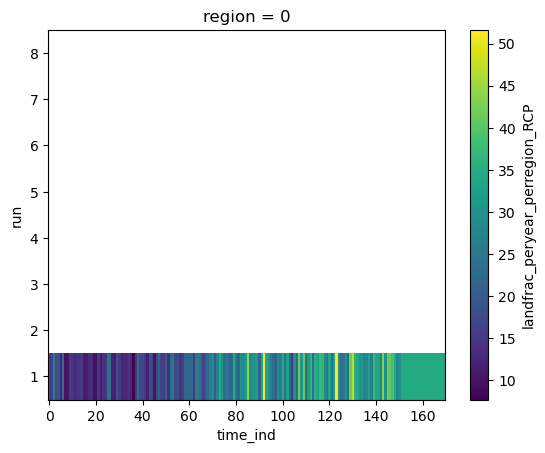

In [ ]:
ds_lfe_perregion_perrun['landfrac_peryear_perregion_RCP'].sel(region=0).plot()


# it looks cool like this !! 

# fraction land pr year exposed to FWI95d exceedance !! Region=0 

In [138]:
climatedata_dir = '/vscmnt/brussel_pixiu_data/_data_brussel/vo/000/bvo00012/vsc10419/fwi-portugal/data/preprocessed/FWI'
startyear=1950
endyear=2119
bbox = bbox_europe

In [143]:
for i in list(d_climate_data_meta.keys()): 

    print('                         🟠 Remapping Simulation {} of {} 🟠\n'.format(i,len(d_climate_data_meta)))

    scenario = d_climate_data_meta[i]['scenario']
    model = d_climate_data_meta[i]['model']
    extreme = d_climate_data_meta[i]['extreme']

    da_AFA = load_climate_data_array(climatedata_dir,
                scenario,
                model,
                extreme,
                startyear,
                endyear,
                bbox
                )

    # loop over warming scenarios 
    for suffix in var_suffixes:

        for ind_region,region in enumerate(region_names):

            print(f'Computing LFE in {region} for {suffix}')

            countries = get_countries_of_region(region, df_countries)

            ind_country = countries_regions.map_keys(countries)

            if suffix == 'RCP': # calc area-weighted fieldmean for each model year

                land_frac_perregion = calc_weighted_fldmean(da_AFA,countries_mask,ind_country,weights, areaweighted)

                ds_lfe_perregion_perrun[f'landfrac_peryear_perregion_{suffix}'].loc[{
                        'run' : i, 
                        'region' : ind_region
                    }] = land_frac_perregion.values
            
            else: # remap based on indexes previously computed 

                ind_RCP = d_climate_data_meta[i][f'ind_RCP2GMT_{suffix}']

                # extract the relevant subset for this run and region
                src = ds_lfe_perregion_perrun['landfrac_peryear_perregion_RCP'].sel(run=i, region=ind_region)

                # assign remapped 
                ds_lfe_perregion_perrun[f'landfrac_peryear_perregion_{suffix}'].loc[dict(run=i, region=ind_region)] = src.isel(time_ind=ind_RCP).values


            pass


        for j, country in enumerate(df_countries['name']):

            print(f'Computing LFE in {country} for {suffix}')

            # calculate mean per country weighted by area
            ind_country = countries_regions.map_keys(country)
            
            if suffix =='RCP':
                landfrac_percountry = calc_weighted_fldmean(da_AFA,countries_mask,ind_country,weights, areaweighted)

                ds_lfe_percountry_perrun[f'landfrac_peryear_percountry_{suffix}'].loc[{
                        'run' : i, 
                        'country' : country
                    }] = landfrac_percountry.values

            else: # remap based on indexes previously computed 

                ind_RCP = d_climate_data_meta[i][f'ind_RCP2GMT_{suffix}']

                # extract the relevant subset for this run and region
                src = ds_lfe_percountry_perrun['landfrac_peryear_percountry_RCP'].sel(run=i, country=country)

                # assign remapped 
                ds_lfe_percountry_perrun[f'landfrac_peryear_percountry_{suffix}'].loc[dict(run=i, country=country)] = src.isel(time_ind=ind_RCP).values




                         🟠 Remapping Simulation 1 of 8 🟠

Loading /vscmnt/brussel_pixiu_data/_data_brussel/vo/000/bvo00012/vsc10419/fwi-portugal/data/preprocessed/FWI/historical/ACCESS-CM2/FWI_ACCESS-CM2_1950_2014_FWI95d.nc
Loading /vscmnt/brussel_pixiu_data/_data_brussel/vo/000/bvo00012/vsc10419/fwi-portugal/data/preprocessed/FWI/ssp126/ACCESS-CM2/FWI_ACCESS-CM2_2015_2100_FWI95d.nc
load_climate_data_array took 0.06 s
Computing LFE in Europe & Central Asia for RCP
calc_weighted_fldmean took 0.01 s
Computing LFE in Middle East & North Africa for RCP
calc_weighted_fldmean took 0.01 s
Computing LFE in Upper middle income for RCP
calc_weighted_fldmean took 0.01 s
Computing LFE in High income for RCP
calc_weighted_fldmean took 0.01 s
Computing LFE in Lower middle income for RCP
calc_weighted_fldmean took 0.02 s
Computing LFE in World for RCP
calc_weighted_fldmean took 0.01 s
Computing LFE in Albania for RCP
calc_weighted_fldmean took 0.01 s
Computing LFE in Algeria for RCP
calc_weighted_fld

In [144]:
ds_lfe_perregion_perrun

<xarray.Dataset>
Dimensions:                          (run: 8, region: 6, time_ind: 170)
Coordinates:
  * run                              (run) int64 1 2 3 4 5 6 7 8
  * region                           (region) int64 0 1 2 3 4 5
  * time_ind                         (time_ind) int64 0 1 2 3 ... 167 168 169
Data variables:
    landfrac_peryear_perregion_RCP   (run, region, time_ind) float64 17.31 .....
    landfrac_peryear_perregion_15    (run, region, time_ind) float64 14.53 .....
    landfrac_peryear_perregion_20    (run, region, time_ind) float64 14.53 .....
    landfrac_peryear_perregion_NDC   (run, region, time_ind) float64 14.53 .....
    landfrac_peryear_perregion_OS    (run, region, time_ind) float64 14.53 .....
    landfrac_peryear_perregion_noOS  (run, region, time_ind) float64 14.53 .....

### dev: visualize output

land frac exposed per model/RCP and per remapped scenarios !

To do
- do it per GMT_strj as well 
- move to lifetime exposure 


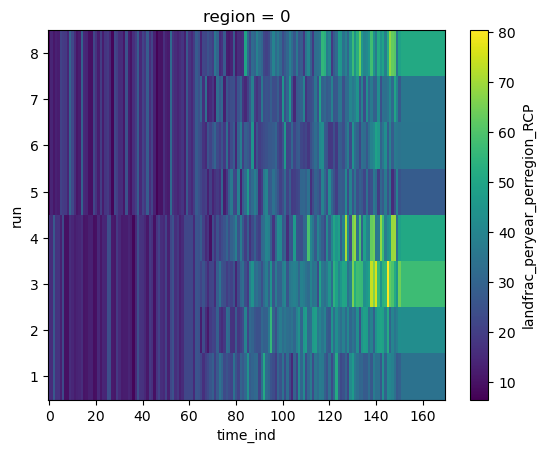

In [ ]:
ds_lfe_perregion_perrun['landfrac_peryear_perregion_RCP'].sel(region=0).plot()

# print what model/rcp these are!!


In [151]:
for i in list(d_climate_data_meta.keys()):
    scenario = d_climate_data_meta[i]['scenario']
    model = d_climate_data_meta[i]['model']
    print(i, model, scenario)

1 ACCESS-CM2 ssp126
2 ACCESS-CM2 ssp245
3 ACCESS-CM2 ssp370
4 ACCESS-CM2 ssp585
5 CNRM-ESM2-1 ssp126
6 CNRM-ESM2-1 ssp245
7 CNRM-ESM2-1 ssp370
8 CNRM-ESM2-1 ssp585


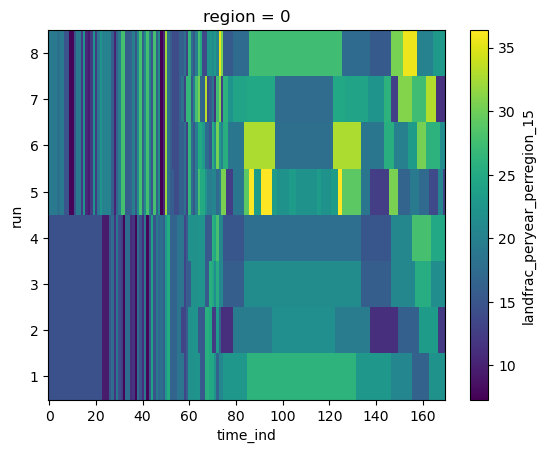

In [146]:
ds_lfe_perregion_perrun['landfrac_peryear_perregion_15'].sel(region=0).plot()


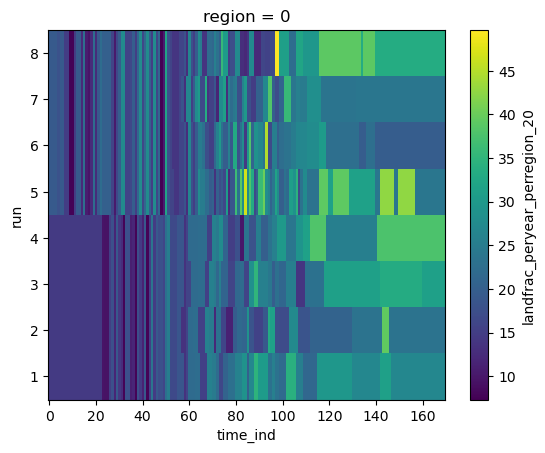

In [147]:
ds_lfe_perregion_perrun['landfrac_peryear_perregion_20'].sel(region=0).plot()


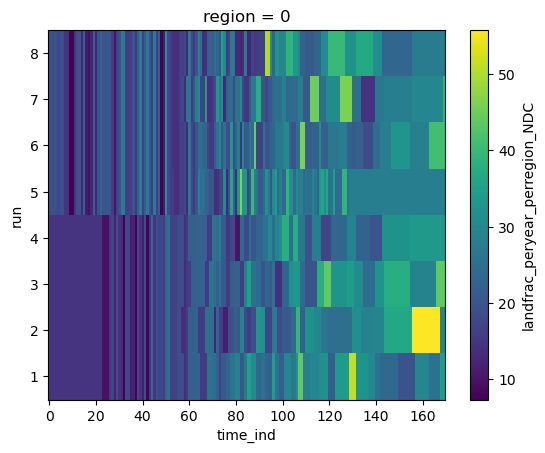

In [148]:
ds_lfe_perregion_perrun['landfrac_peryear_perregion_NDC'].sel(region=0).plot()


### add also df_GMT_strj

In [7]:
df_GMT_strj.columns

Index([1.5, 1.6, 1.7, 1.8, 1.9, 2.0, 2.1, 2.2, 2.3, 2.4, 2.5, 2.6, 2.7, 2.8,
       2.9, 3.0, 3.1, 3.2, 3.3, 3.4, 3.5],
      dtype='float64')

In [8]:
d_climate_data_meta

{1: {'extreme': 'FWI95d',
  'model': 'ACCESS-CM2',
  'scenario': 'ssp126',
  'GMT':            tas
  1950  0.385547
  1951  0.393164
  1952  0.393677
  1953  0.379471
  1954  0.362028
  ...        ...
  2115  2.769605
  2116  2.769605
  2117  2.769605
  2118  2.769605
  2119  2.769605
  
  [170 rows x 1 columns],
  'GMT_strj_maxdiff': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1]),
  'GMT_strj_valid': array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0]),
  'ind_RCP2GMT_strj': array([[ 23,  23,  23, ...,  23,  23,  23],
         [ 23,  23,  23, ...,  23,  23,  23],
         [ 23,  23,  23, ...,  23,  23,  23],
         ...,
         [ 69,  72,  75, ..., 149, 149, 149],
         [ 69,  71,  75, ..., 149, 149, 149],
         [ 69,  71,  75, ..., 149, 149, 149]]),
  'GMT_15_maxdiff': 0.14355040795676718,
  'GMT_15_valid': True,
  'ind_RCP2GMT_15': array([23, 23, 23, 23, 23, 23, 23, 23, 23, 23, 23, 23, 23, 23, 23, 23, 23,
         23, 23, 23, 23, 23

In [9]:
year_start = 1950
year_end=2119
GMT_labels = df_GMT_strj.columns

# 1) Build Dataset for regions result

# get regions and income groups and 'World' (=all countries)
region_names = np.concatenate([df_countries['region'].dropna().unique(),
                        df_countries['incomegroup'].dropna().unique(),
                        ['World'] # not sure how useful to keep 'World' if you are using a bbox! 
])

nregions = len(region_names)

# Shared shape for all variables
year_range = np.arange(year_start, year_end+1)

shape = (len(d_climate_data_meta), nregions, len(year_range))

# Build the data_vars dictionary in a loop
data_vars = {}
var_suffixes = ['RCP']+GMT_extra_trajectories_names 
for suffix in var_suffixes:
    var_name = f'landfrac_peryear_perregion_{suffix}'
    data_vars[var_name] = (
        ['run', 'region', 'time_ind'],
        np.full(shape, np.nan)
    )


shape_strj = (len(d_climate_data_meta), nregions, len(year_range), len(GMT_labels))

data_vars['landfrac_peryear_perregion_strj'] = (
        ['run', 'region', 'time_ind', 'GMT'],
        np.full(shape_strj, np.nan)

)

# Build the dataset
ds_lfe_perregion_perrun = xr.Dataset(
    data_vars=data_vars,
    coords={
        'run': ('run', np.arange(1, len(d_climate_data_meta) + 1)),
        'region': ('region', np.arange(0, nregions)),
        'time_ind': ('time_ind', np.arange(0, len(year_range), 1)),
        'GMT': ('GMT', GMT_labels)
    }
)

In [10]:
ds_lfe_perregion_perrun

<xarray.Dataset>
Dimensions:                          (run: 8, region: 6, time_ind: 170, GMT: 21)
Coordinates:
  * run                              (run) int64 1 2 3 4 5 6 7 8
  * region                           (region) int64 0 1 2 3 4 5
  * time_ind                         (time_ind) int64 0 1 2 3 ... 167 168 169
  * GMT                              (GMT) float64 1.5 1.6 1.7 ... 3.3 3.4 3.5
Data variables:
    landfrac_peryear_perregion_RCP   (run, region, time_ind) float64 nan ... nan
    landfrac_peryear_perregion_15    (run, region, time_ind) float64 nan ... nan
    landfrac_peryear_perregion_20    (run, region, time_ind) float64 nan ... nan
    landfrac_peryear_perregion_NDC   (run, region, time_ind) float64 nan ... nan
    landfrac_peryear_perregion_OS    (run, region, time_ind) float64 nan ... nan
    landfrac_peryear_perregion_noOS  (run, region, time_ind) float64 nan ... nan
    landfrac_peryear_perregion_strj  (run, region, time_ind, GMT) float64 nan...

In [11]:
d_climate_data_meta[1]['GMT_strj_valid'] #[step]

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0])

In [13]:
d_climate_data_meta[1]['ind_RCP2GMT_strj']

array([[ 23,  23,  23, ...,  23,  23,  23],
       [ 23,  23,  23, ...,  23,  23,  23],
       [ 23,  23,  23, ...,  23,  23,  23],
       ...,
       [ 69,  72,  75, ..., 149, 149, 149],
       [ 69,  71,  75, ..., 149, 149, 149],
       [ 69,  71,  75, ..., 149, 149, 149]])

In [15]:
d_climate_data_meta[1]['ind_RCP2GMT_strj'].shape

(170, 21)

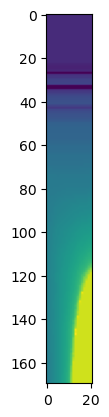

In [14]:
plt.imshow(d_climate_data_meta[1]['ind_RCP2GMT_strj'])

In [21]:
step=0
i=1

if d_climate_data_meta[i]['GMT_strj_valid'][step]:
    print(True)

ind_RCP = d_climate_data_meta[i]['ind_RCP2GMT_strj'][:,step]
ind_RCP

True


array([23, 23, 23, 23, 23, 23, 23, 23, 23, 23, 23, 23, 23, 23, 23, 23, 23,
       23, 23, 23, 23, 23, 23, 20, 19, 19, 21,  4, 27, 29, 34, 35, 36,  4,
        4, 28, 31, 36, 39, 41, 42, 43, 36, 30, 38, 41, 43, 44, 46, 48, 52,
       53, 54, 54, 54, 55, 55, 55, 56, 57, 58, 59, 59, 60, 61, 62, 62, 63,
       63, 63, 64, 65, 66, 66, 67, 67, 68, 68, 68, 68, 68, 68, 69, 69, 69,
       69, 69, 70, 70, 70, 70, 70, 70, 70, 70, 70, 71, 71, 71, 71, 72, 72,
       72, 72, 72, 72, 72, 72, 72, 72, 73, 73, 73, 73, 72, 72, 72, 73, 73,
       73, 73, 73, 72, 72, 72, 72, 72, 72, 72, 72, 72, 72, 72, 72, 72, 72,
       72, 72, 72, 72, 72, 72, 72, 72, 72, 71, 71, 71, 71, 71, 71, 71, 71,
       71, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 69, 69, 69, 69, 69])

In [23]:

ind_region=0 

src = ds_lfe_perregion_perrun['landfrac_peryear_perregion_RCP'].sel(run=i, region=ind_region)

In [26]:
src.isel(time_ind=ind_RCP).values.shape

(170,)

In [29]:
ds_lfe_perregion_perrun['landfrac_peryear_perregion_strj'].isel(region=0,run=0,GMT=0)

<xarray.DataArray 'landfrac_peryear_perregion_strj' (time_ind: 170)>
array([nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan])
Coordinates:
    run       int64 1
    region    int64 0
  * time_ind  (time_ind) int64 0 1 2 3 4 5 6 7 ... 163 164 165 166 167 168 169
    GMT       float64 1.5

### test the function / plot results of remapping

To do
- include/exclude countries that are cut/incomplete in shapefile

In [7]:
GCMs = ['ACCESS-CM2', 'CNRM-ESM2-1', 'CanESM5', 'EC-EARTH', 'MPI-ESM1-2-HR', 'MRI-ESM2-0']
scenarios = ['ssp126', 'ssp245', 'ssp370', 'ssp585']
GMT_extra_trajectories_names = ['15', '20', 'NDC', 'OS', 'noOS']
climatedata_dir = '/vscmnt/brussel_pixiu_data/_data_brussel/vo/000/bvo00012/vsc10419/fwi-portugal/data/preprocessed/FWI'


In [8]:
bbox_europe

[31.99, 71.09, -14.96, 34.94]

In [9]:
subset = dict(list(d_climate_data_meta.items())[0:2])


In [62]:
ds_lfe_perregion_perrun, ds_lfe_percountry_perrun, region_names = calc_landfraction_exposed(
    d_climate_data_meta, #subset
    df_countries, 
    countries_regions, 
    countries_mask, 
    # GMT_strj -  TODO
    GMT_extra_trajectories_names,
    climatedata_dir,
    year_start=1950,
    year_end=2119,
    bbox=bbox_europe,
    weights=None,
    areaweighted=True,
)

                         🟠 Remapping Simulation 1 of 8 🟠

Loading /vscmnt/brussel_pixiu_data/_data_brussel/vo/000/bvo00012/vsc10419/fwi-portugal/data/preprocessed/FWI/historical/ACCESS-CM2/FWI_ACCESS-CM2_1950_2014_FWI95d.nc
Loading /vscmnt/brussel_pixiu_data/_data_brussel/vo/000/bvo00012/vsc10419/fwi-portugal/data/preprocessed/FWI/ssp126/ACCESS-CM2/FWI_ACCESS-CM2_2015_2100_FWI95d.nc
load_climate_data_array took 0.24 s
Computing LFE in Europe & Central Asia for RCP
Computing LFE in Middle East & North Africa for RCP
Computing LFE in Upper middle income for RCP
Computing LFE in High income for RCP
Computing LFE in Lower middle income for RCP
Computing LFE in World for RCP
Computing LFE in Europe & Central Asia for 15) for RCP
Computing LFE in Middle East & North Africa for 15
Computing LFE in Upper middle income for 15
Computing LFE in High income for 15
Computing LFE in Lower middle income for 15
Computing LFE in World for 15
Computing LFE in Europe & Central Asia for 20) for 15
Computi

<Axes: >

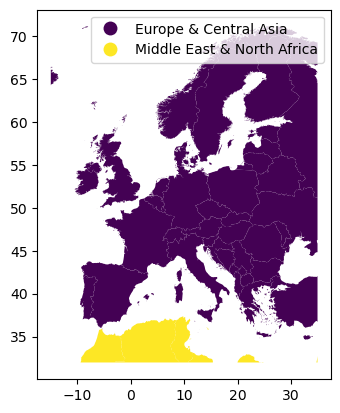

In [63]:
gdf_country_borders.plot(column='region', cmap='viridis',legend=True,)

# maybe get rid of countries that aren't completely included??? 

<Axes: >

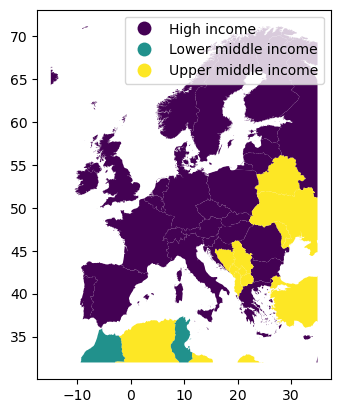

In [64]:
gdf_country_borders.merge(df_countries['incomegroup'],left_index=True, right_index=True).plot(column='incomegroup', cmap='viridis',legend=True,)

In [65]:
region_names

# maybe need to subselect within Europe & Central Asia?? 

array(['Europe & Central Asia', 'Middle East & North Africa',
       'Upper middle income', 'High income', 'Lower middle income',
       'World'], dtype=object)

In [66]:
for i in list(subset.keys()):
    scenario = subset[i]['scenario']
    model = subset[i]['model']
    print(i, model, scenario)

1 ACCESS-CM2 ssp126
2 ACCESS-CM2 ssp245


In [69]:
rename_dict = {
    i: f"{d_climate_data_meta[i]['model']} {d_climate_data_meta[i]['scenario']}"
    for i in d_climate_data_meta.keys()
}
rename_dict

{1: 'ACCESS-CM2 ssp126',
 2: 'ACCESS-CM2 ssp245',
 3: 'ACCESS-CM2 ssp370',
 4: 'ACCESS-CM2 ssp585',
 5: 'CNRM-ESM2-1 ssp126',
 6: 'CNRM-ESM2-1 ssp245',
 7: 'CNRM-ESM2-1 ssp370',
 8: 'CNRM-ESM2-1 ssp585'}

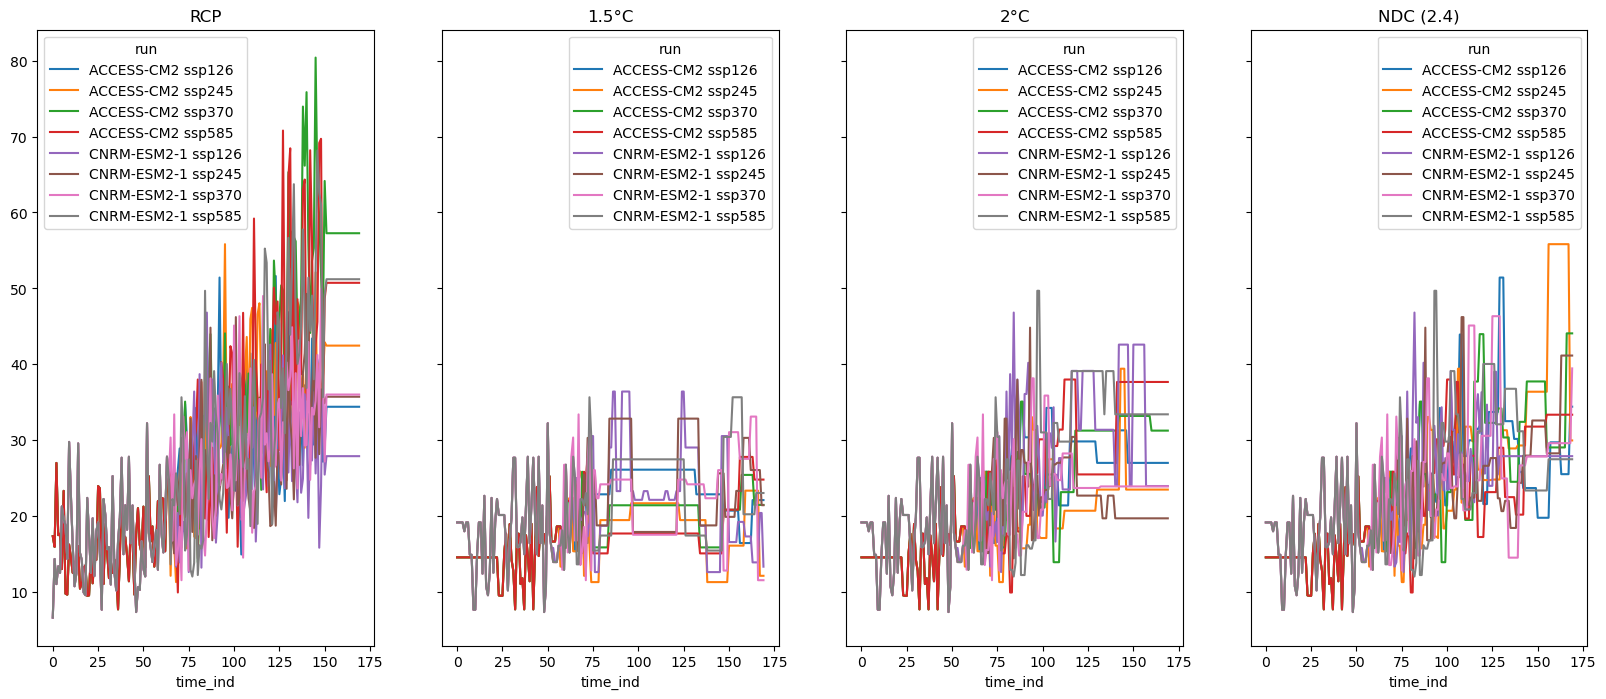

In [71]:
fig, axes = plt.subplots(1,4,sharey=True,figsize=(20,8))

ds_lfe_perregion_perrun.sel(region=0)['landfrac_peryear_perregion_RCP'].to_pandas().T.rename(columns=rename_dict).plot(ax=axes[0])
ds_lfe_perregion_perrun.sel(region=0)['landfrac_peryear_perregion_15'].to_pandas().T.rename(columns=rename_dict).plot(ax=axes[1])
ds_lfe_perregion_perrun.sel(region=0)['landfrac_peryear_perregion_20'].to_pandas().T.rename(columns=rename_dict).plot(ax=axes[2])
ds_lfe_perregion_perrun.sel(region=0)['landfrac_peryear_perregion_NDC'].to_pandas().T.rename(columns=rename_dict).plot(ax=axes[3])

labels = ['RCP', '1.5°C', '2°C',  'NDC (2.4)',]

for i,ax in enumerate(axes):
    ax.set_title(labels[i])

In [72]:
rename_dict = {
    i: f"{subset[i]['model']} {subset[i]['scenario']}"
    for i in subset.keys()
}
rename_dict

{1: 'ACCESS-CM2 ssp126', 2: 'ACCESS-CM2 ssp245'}

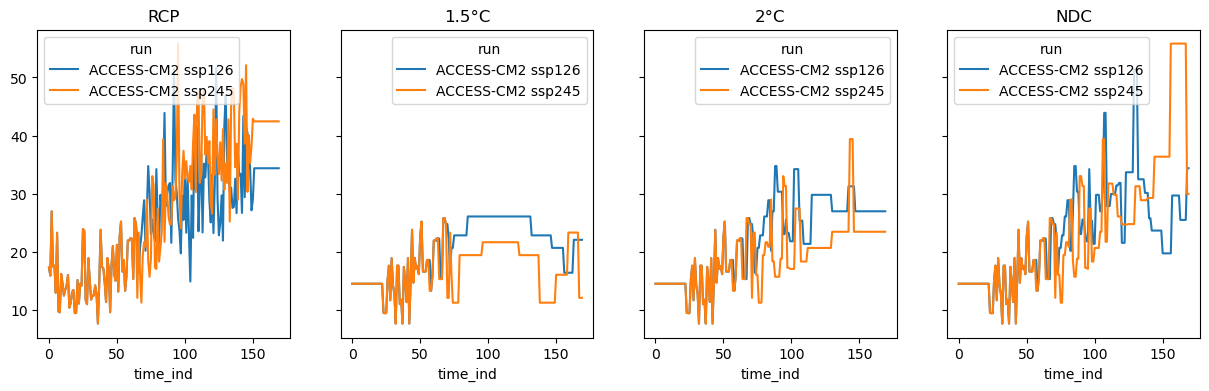

In [ ]:
fig, axes = plt.subplots(1,4,sharey=True,figsize=(15,4))

ds_lfe_perregion_perrun.sel(region=0)['landfrac_peryear_perregion_RCP'].to_pandas().T.rename(columns=rename_dict).plot(ax=axes[0])
ds_lfe_perregion_perrun.sel(region=0)['landfrac_peryear_perregion_15'].to_pandas().T.rename(columns=rename_dict).plot(ax=axes[1])
ds_lfe_perregion_perrun.sel(region=0)['landfrac_peryear_perregion_20'].to_pandas().T.rename(columns=rename_dict).plot(ax=axes[2])
ds_lfe_perregion_perrun.sel(region=0)['landfrac_peryear_perregion_NDC'].to_pandas().T.rename(columns=rename_dict).plot(ax=axes[3])

labels = ['RCP', '1.5°C', '2°C',  'NDC (2.4)',]

for i,ax in enumerate(axes):
    ax.set_title(labels[i])


### Notes

- less variability! in remapped than in original - could bias - in ACCESS rcp 126 is quite similar to NDC (~2.4) - check if level of warming is similar
- rerun for more models! all? and check
- do also for stylized trajectories 
- note this is for smooth_first_decades = False !!

### test the fxn with strj

Note that on non-binary data this is average number of days per year exceeding threshold!! which is what you want for lifetime exposure too !

In [95]:
GCMs = ['ACCESS-CM2', 'CNRM-ESM2-1', 'CanESM5', 'EC-EARTH', 'MPI-ESM1-2-HR', 'MRI-ESM2-0']
scenarios = ['ssp126', 'ssp245', 'ssp370', 'ssp585']
GMT_extra_trajectories_names = ['15', '20', 'NDC', 'OS', 'noOS']
climatedata_dir = '/vscmnt/brussel_pixiu_data/_data_brussel/vo/000/bvo00012/vsc10419/fwi-portugal/data/preprocessed/FWI'


In [96]:
bbox_europe

[31.99, 71.09, -14.96, 34.94]

In [97]:
subset = dict(list(d_climate_data_meta.items())[0:2])


In [98]:
ds_lfe_perregion_perrun, ds_lfe_percountry_perrun, region_names = calc_landfraction_exposed(
    subset, #subset
    df_countries, 
    countries_regions, 
    countries_mask, 
    climatedata_dir,
    GMT_labels = df_GMT_strj.columns,
    GMT_extra_trajectories_names = GMT_extra_trajectories_names,
    year_start=1950,
    year_end=2119,
    bbox=bbox_europe,
    weights=None,
    areaweighted=True,
)

                         🟠 Remapping Simulation 1 of 2 🟠

Loading /vscmnt/brussel_pixiu_data/_data_brussel/vo/000/bvo00012/vsc10419/fwi-portugal/data/preprocessed/FWI/historical/ACCESS-CM2/FWI_ACCESS-CM2_1950_2014_FWI95d.nc
Loading /vscmnt/brussel_pixiu_data/_data_brussel/vo/000/bvo00012/vsc10419/fwi-portugal/data/preprocessed/FWI/ssp126/ACCESS-CM2/FWI_ACCESS-CM2_2015_2100_FWI95d.nc
load_climate_data_array took 0.63 s
Computing land fraction exposed (LFE) for RCP 

Computing land fraction exposed (LFE) for 15                                

Computing land fraction exposed (LFE) for 20                                

Computing land fraction exposed (LFE) for NDC                               

Computing land fraction exposed (LFE) for OS                                

Computing land fraction exposed (LFE) for noOS                              

Computing land fraction exposed (LFE) for strj                              

                         🟠 Remapping Simulation 2 of 2 🟠      

In [99]:
ds_lfe_perregion_perrun

<xarray.Dataset>
Dimensions:                          (run: 2, region: 6, time_ind: 170, GMT: 21)
Coordinates:
  * run                              (run) int64 1 2
  * region                           (region) int64 0 1 2 3 4 5
  * time_ind                         (time_ind) int64 0 1 2 3 ... 167 168 169
  * GMT                              (GMT) float64 1.5 1.6 1.7 ... 3.3 3.4 3.5
Data variables:
    landfrac_peryear_perregion_RCP   (run, region, time_ind) float64 17.31 .....
    landfrac_peryear_perregion_15    (run, region, time_ind) float64 14.53 .....
    landfrac_peryear_perregion_20    (run, region, time_ind) float64 14.53 .....
    landfrac_peryear_perregion_NDC   (run, region, time_ind) float64 14.53 .....
    landfrac_peryear_perregion_OS    (run, region, time_ind) float64 14.53 .....
    landfrac_peryear_perregion_noOS  (run, region, time_ind) float64 14.53 .....
    landfrac_peryear_perregion_strj  (run, region, time_ind, GMT) float64 14....

#### plots

In [30]:
region_names

array(['Europe & Central Asia', 'Middle East & North Africa',
       'Upper middle income', 'High income', 'Lower middle income',
       'World'], dtype=object)

In [31]:
rename_dict = {
    i: f"{subset[i]['model']} {subset[i]['scenario']}"
    for i in subset.keys()
}
rename_dict

{1: 'ACCESS-CM2 ssp126', 2: 'ACCESS-CM2 ssp245'}

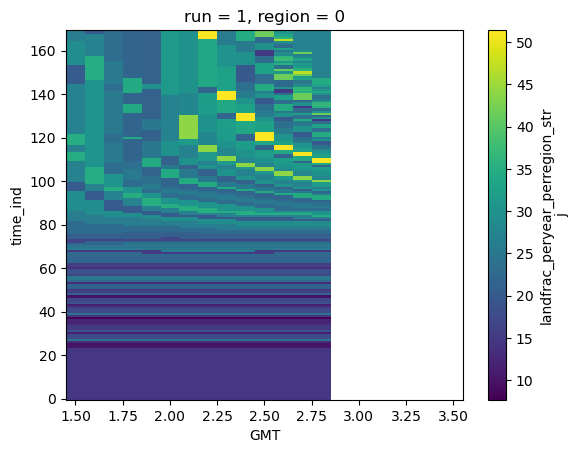

In [35]:
ds_lfe_perregion_perrun['landfrac_peryear_perregion_strj'].isel(run=0,region=0).plot()

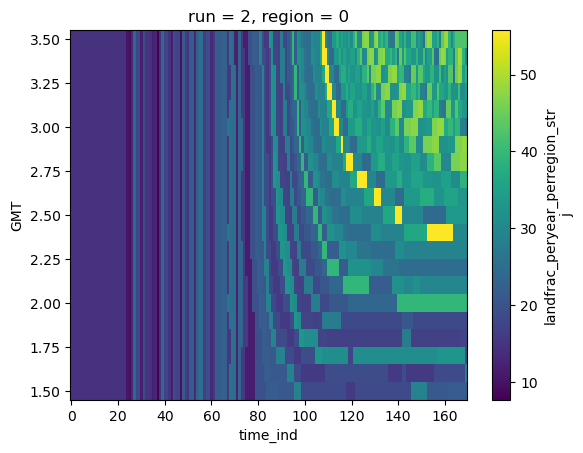

In [36]:
ds_lfe_perregion_perrun['landfrac_peryear_perregion_strj'].isel(run=1,region=0).T.plot()

<Axes: xlabel='time_ind'>

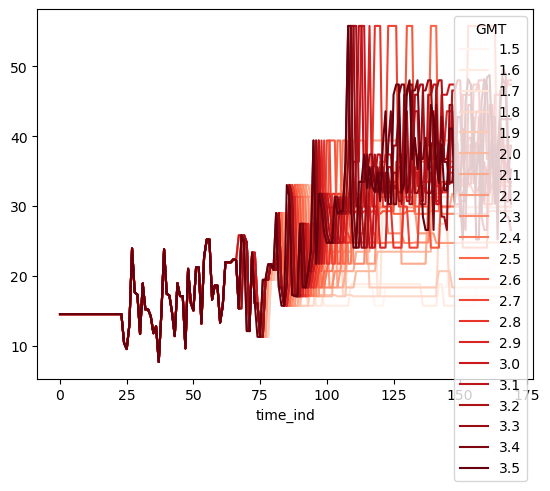

In [38]:
ds_lfe_perregion_perrun['landfrac_peryear_perregion_strj'].isel(run=1,region=0).to_pandas().plot(cmap='Reds')

<Axes: xlabel='time_ind'>

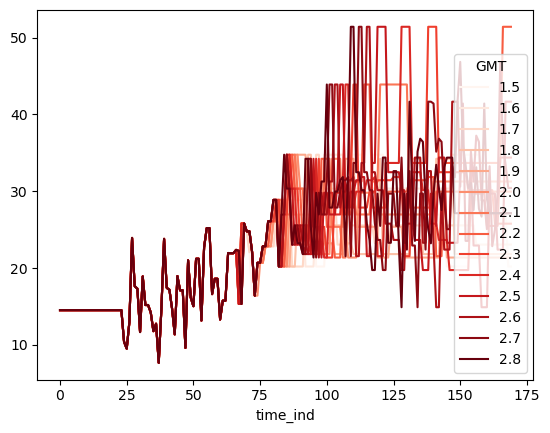

In [43]:
ds_lfe_perregion_perrun['landfrac_peryear_perregion_strj'].isel(run=0,region=0).to_pandas().dropna(axis=1).plot(cmap='Reds')

<Axes: >

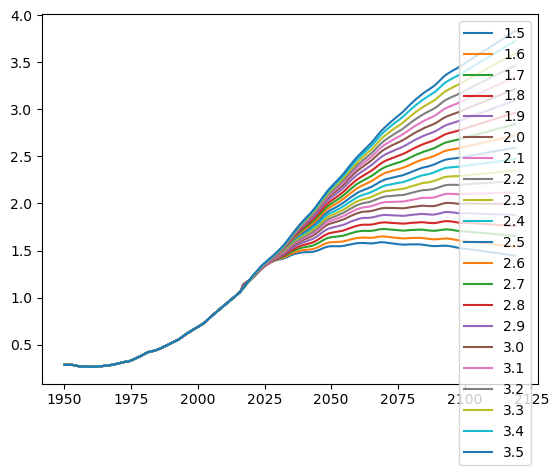

In [41]:
df_GMT_strj.plot()

<Axes: >

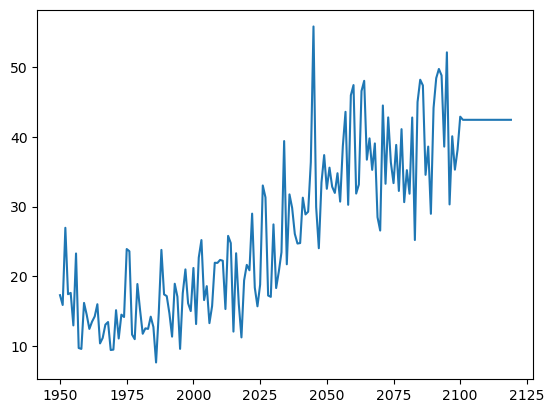

In [ ]:
fig, ax = plt.subplots()

s = ds_lfe_perregion_perrun['landfrac_peryear_perregion_RCP'].isel(run=1,region=0).to_pandas()

s.index = np.arange(1950, 2119+1)
s.plot(ax=ax)

# compare to original remapped scenario

# how does the GMT of the original model get repeated after 2100??? Is this used for remapping??? possibly dont use that data !! 

### natural variability is underestimated

Plot stdev of detrended tseries vs. orginal RCP timeseries 

Probably doesnt matter since you are looking across lifetimes


#### To do:
- For NV, could also pool this across all different runs - calc difference true stdev vs simulated and plot distribution?
- look also at warmer trajs than ssp245 cause looks like they map better 


Text(0.5, 1.0, 'variability (stdev) in detrended synthetic timeseries vs. original GCM \n ACCESS-CM2 ssp245, Europe & Central Asia')

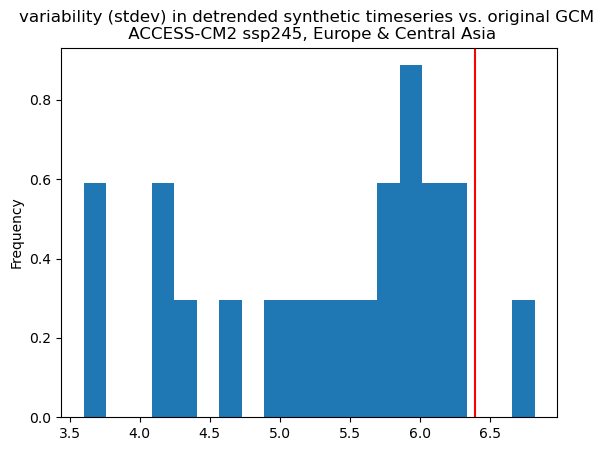

In [19]:
import statsmodels.api as sm
def detrend(year, data):
    fit = sm.OLS(data, sm.add_constant(year)).fit()
    return fit.resid

    

fig,ax=plt.subplots()
    
df = ds_lfe_perregion_perrun['landfrac_peryear_perregion_strj'].isel(run=1,region=0).to_pandas()
year = np.arange(df.shape[0])
df.apply(lambda col: detrend(year, col)).std().plot.hist(density=True,bins=20,ax=ax)

s = ds_lfe_perregion_perrun['landfrac_peryear_perregion_RCP'].isel(run=1,region=0).to_pandas().loc[:150]
year = np.arange(len(s))
ax.axvline(detrend(year, s).std(), c='red')

plt.title(f'variability (stdev) in detrended synthetic timeseries vs. original GCM \n {rename_dict[2]}, {region_names[0]}')

Text(0.5, 1.0, 'variability (stdev) in detrended synthetic timeseries vs. original GCM \n ACCESS-CM2 ssp126, Europe & Central Asia')

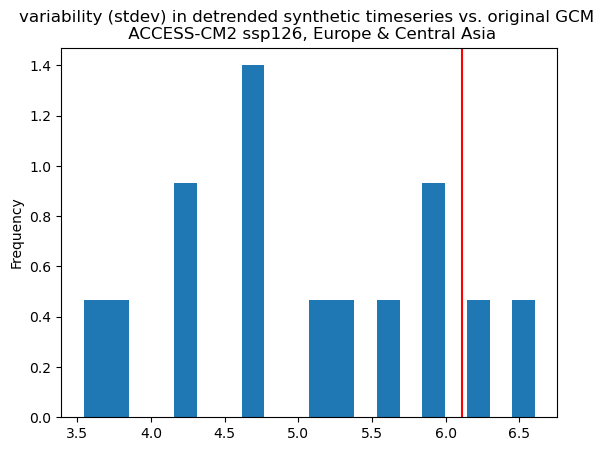

In [20]:
fig,ax=plt.subplots()
    
df = ds_lfe_perregion_perrun['landfrac_peryear_perregion_strj'].isel(run=0,region=0).to_pandas()
year = np.arange(df.shape[0])
df.apply(lambda col: detrend(year, col)).std().plot.hist(density=True,bins=20,ax=ax)

s = ds_lfe_perregion_perrun['landfrac_peryear_perregion_RCP'].isel(run=0,region=0).to_pandas().loc[:150] # only to 2100
year = np.arange(len(s))
ax.axvline(detrend(year, s).std(), c='red')

plt.title(f'variability (stdev) in detrended synthetic timeseries vs. original GCM \n {rename_dict[1]}, {region_names[0]}')

In [21]:
region_names

array(['Europe & Central Asia', 'Middle East & North Africa',
       'Upper middle income', 'High income', 'Lower middle income',
       'World'], dtype=object)

Text(0.5, 1.0, 'variability (stdev) in detrended synthetic timeseries vs. original GCM \n ACCESS-CM2 ssp126, World')

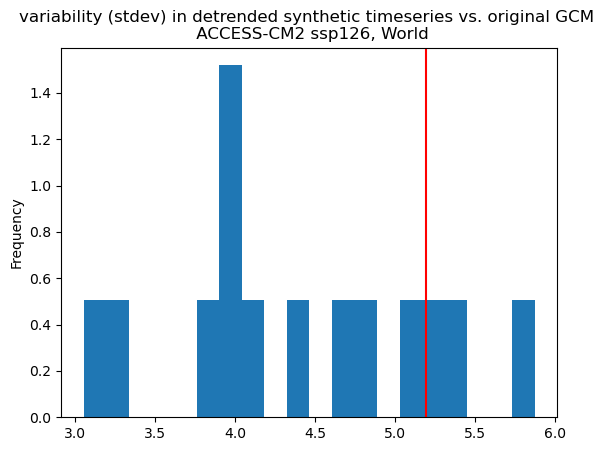

In [22]:
# different runs/regions

fig,ax=plt.subplots()
    
df = ds_lfe_perregion_perrun['landfrac_peryear_perregion_strj'].isel(run=0,region=5).to_pandas()
year = np.arange(df.shape[0])
df.apply(lambda col: detrend(year, col)).std().plot.hist(density=True,bins=20,ax=ax)


s = ds_lfe_perregion_perrun['landfrac_peryear_perregion_RCP'].isel(run=0,region=5).to_pandas().loc[:2100]
year = np.arange(len(s))
ax.axvline(detrend(year, s).std(), c='red')

plt.title('variability (stdev) in detrended synthetic timeseries vs. original GCM')

plt.title(f'variability (stdev) in detrended synthetic timeseries vs. original GCM \n {rename_dict[1]}, {region_names[5]}')

Text(0.5, 1.0, 'variability (stdev) in detrended synthetic timeseries vs. original GCM \n ACCESS-CM2 ssp126, World')

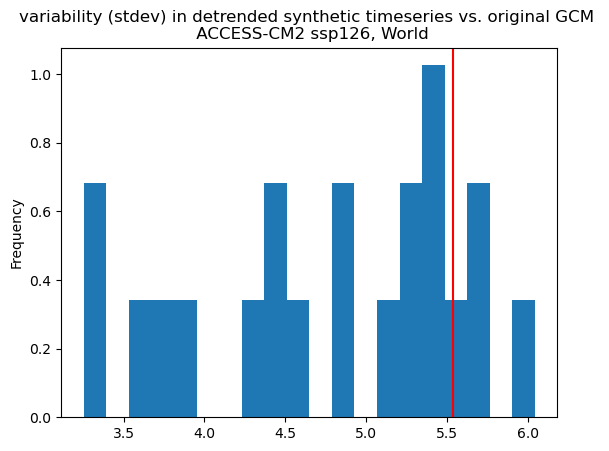

In [23]:
# different runs/regions

fig,ax=plt.subplots()
    
df = ds_lfe_perregion_perrun['landfrac_peryear_perregion_strj'].isel(run=1,region=5).to_pandas()
year = np.arange(df.shape[0])
df.apply(lambda col: detrend(year, col)).std().plot.hist(density=True,bins=20,ax=ax)


s = ds_lfe_perregion_perrun['landfrac_peryear_perregion_RCP'].isel(run=1,region=5).to_pandas().loc[:2100]
year = np.arange(len(s))
ax.axvline(detrend(year, s).std(), c='red')

plt.title('variability (stdev) in detrended synthetic timeseries vs. original GCM')
plt.title(f'variability (stdev) in detrended synthetic timeseries vs. original GCM \n {rename_dict[1]}, {region_names[5]}')

### decadal order of magnitudes ok: decadal avg ndays per year per decadal mean GMT in original RCPs vs. remapped trajs

To see if there is a systematic bias. take mean % area exposed every 10 years and compare it with mean (smoothed) temperature in that scenario and check if there is a systematic bias plotting it as avg area ~ avg GMT, looks fine!

#### To do: 
These could be good validation plots to have ! Cfr. RIME-X - this match is worse than RIME-X

Could also apply a RIME approach - 20 year means and then interpolate to 0.1 degree intervals to get the forced signal, or even better a RIME-X approach


In [24]:
ds_lfe_perregion_perrun

<xarray.Dataset>
Dimensions:                          (run: 2, region: 6, time_ind: 170, GMT: 21)
Coordinates:
  * run                              (run) int64 1 2
  * region                           (region) int64 0 1 2 3 4 5
  * time_ind                         (time_ind) int64 0 1 2 3 ... 167 168 169
  * GMT                              (GMT) float64 1.5 1.6 1.7 ... 3.3 3.4 3.5
Data variables:
    landfrac_peryear_perregion_RCP   (run, region, time_ind) float64 17.31 .....
    landfrac_peryear_perregion_15    (run, region, time_ind) float64 14.53 .....
    landfrac_peryear_perregion_20    (run, region, time_ind) float64 14.53 .....
    landfrac_peryear_perregion_NDC   (run, region, time_ind) float64 14.53 .....
    landfrac_peryear_perregion_OS    (run, region, time_ind) float64 14.53 .....
    landfrac_peryear_perregion_noOS  (run, region, time_ind) float64 14.53 .....
    landfrac_peryear_perregion_strj  (run, region, time_ind, GMT) float64 14....

In [25]:
decadal_avg_rcp = ds_lfe_perregion_perrun['landfrac_peryear_perregion_RCP'].coarsen(time_ind=10, boundary='trim').mean().isel(region=5,run=0).values
decadal_avg_rcp

array([16.98830167, 13.43179953, 15.41406563, 14.53425933, 16.04924595,
       19.11642109, 21.51180431, 26.24496628, 29.55694065, 28.89663675,
       28.68316971, 30.41959048, 30.50126527, 31.97808041, 34.07471939,
       33.15037925, 33.66937896])

In [26]:
df = subset[1]['GMT']
df_decadal = df.groupby(df.index // 10).mean()
df_decadal.index = df.index[::10][:len(df_decadal)] 

df_decadal['fwi_ndays'] = decadal_avg_rcp

df_decadal

,tas,fwi_ndays
1950,0.356894,16.988302
1960,0.325533,13.431800
1970,0.357889,15.414066
1980,0.461284,14.534259
1990,0.611896,16.049246
2000,0.862652,19.116421
2010,1.233464,21.511804
2020,1.652297,26.244966
2030,2.011513,29.556941
2040,2.324559,28.896637


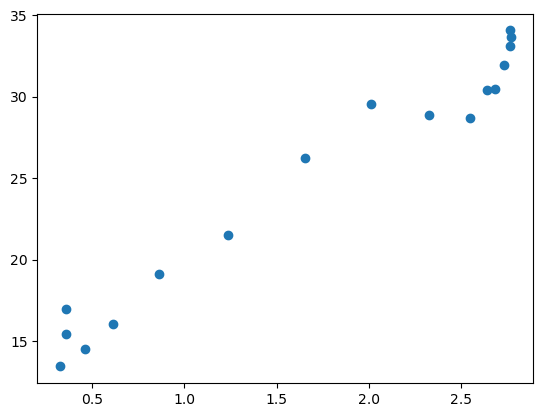

In [27]:
plt.scatter(df_decadal.tas, df_decadal.fwi_ndays)

In [28]:
df = df_GMT_strj
df_decadal_strj = df.groupby(df.index // 10).mean()
df_decadal_strj.index = df.index[::10][:len(df_decadal_strj)] 

df_decadal_strj


,1.5,1.6,1.7,1.8,1.9,2.0,2.1,2.2,2.3,2.4,...,2.6,2.7,2.8,2.9,3.0,3.1,3.2,3.3,3.4,3.5
1950,0.28106,0.28106,0.28106,0.28106,0.28106,0.28106,0.28106,0.28106,0.28106,0.28106,...,0.28106,0.28106,0.28106,0.28106,0.28106,0.28106,0.28106,0.28106,0.28106,0.28106
1960,0.245509,0.245509,0.245509,0.245509,0.245509,0.245509,0.245509,0.245509,0.245509,0.245509,...,0.245509,0.245509,0.245509,0.245509,0.245509,0.245509,0.245509,0.245509,0.245509,0.245509
1970,0.334035,0.334035,0.334035,0.334035,0.334035,0.334035,0.334035,0.334035,0.334035,0.334035,...,0.334035,0.334035,0.334035,0.334035,0.334035,0.334035,0.334035,0.334035,0.334035,0.334035
1980,0.446723,0.446723,0.446723,0.446723,0.446723,0.446723,0.446723,0.446723,0.446723,0.446723,...,0.446723,0.446723,0.446723,0.446723,0.446723,0.446723,0.446723,0.446723,0.446723,0.446723
1990,0.561824,0.561824,0.561824,0.561824,0.561824,0.561824,0.561824,0.561824,0.561824,0.561824,...,0.561824,0.561824,0.561824,0.561824,0.561824,0.561824,0.561824,0.561824,0.561824,0.561824
2000,0.863722,0.863722,0.863722,0.863722,0.863722,0.863722,0.863722,0.863722,0.863722,0.863722,...,0.863722,0.863722,0.863722,0.863722,0.863722,0.863722,0.863722,0.863722,0.863722,0.863722
2010,1.091175,1.090771,1.090287,1.089968,1.089893,1.090164,1.089575,1.089271,1.089035,1.089144,...,1.088992,1.089358,1.089731,1.090241,1.090705,1.090682,1.091134,1.091858,1.092717,1.093433
2020,1.321549,1.319246,1.316366,1.313774,1.310895,1.30958,1.314524,1.319378,1.323917,1.328308,...,1.327082,1.326498,1.325901,1.325271,1.326201,1.330542,1.33468,1.339142,1.343524,1.347175
2030,1.441542,1.454914,1.471628,1.486671,1.503386,1.519563,1.533592,1.547365,1.560246,1.573468,...,1.585993,1.591957,1.598053,1.604481,1.610742,1.617505,1.623953,1.630906,1.637733,1.643421
2040,1.504397,1.5369,1.577528,1.614093,1.654721,1.691823,1.714819,1.737397,1.758511,1.781501,...,1.829674,1.852613,1.876062,1.900786,1.920757,1.933446,1.945542,1.958587,1.971394,1.982067


In [29]:
df_strj_fwi = ds_lfe_perregion_perrun['landfrac_peryear_perregion_strj'].coarsen(time_ind=10, boundary='trim').mean().isel(region=5,run=0).to_pandas()
df_strj_fwi.index = df_decadal_strj.index

df_strj_fwi

GMT,1.5,1.6,1.7,1.8,1.9,2.0,2.1,2.2,2.3,2.4,...,2.6,2.7,2.8,2.9,3.0,3.1,3.2,3.3,3.4,3.5
1950,14.002002,14.002002,14.002002,14.002002,14.002002,14.002002,14.002002,14.002002,14.002002,14.002002,...,14.002002,14.002002,14.002002,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1960,14.002002,14.002002,14.002002,14.002002,14.002002,14.002002,14.002002,14.002002,14.002002,14.002002,...,14.002002,14.002002,14.002002,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1970,14.091598,14.091598,14.091598,14.091598,14.091598,14.091598,14.091598,14.091598,14.091598,14.091598,...,14.091598,14.091598,14.091598,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1980,13.915178,13.915178,13.915178,13.915178,13.915178,13.915178,13.915178,13.915178,13.915178,13.915178,...,13.915178,13.915178,13.915178,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1990,16.215190,16.215190,16.215190,16.215190,16.215190,16.215190,16.215190,16.215190,16.215190,16.215190,...,16.215190,16.215190,16.215190,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2000,18.034953,18.034953,18.034953,18.034953,18.034953,18.034953,18.034953,18.034953,18.034953,18.034953,...,18.034953,18.034953,18.034953,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010,21.770886,21.770886,20.786121,20.786121,20.786121,20.786121,20.786121,20.786121,20.786121,20.786121,...,20.786121,20.786121,20.786121,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020,21.035916,21.624878,21.624878,21.720014,21.720014,21.294976,21.963849,22.106781,22.350615,22.350615,...,22.350615,22.350615,22.350615,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2030,25.310159,26.341868,24.265421,24.280788,25.772797,26.669812,27.478587,27.262845,27.340073,27.145879,...,25.776143,26.511597,26.543830,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2040,25.261544,25.079218,26.971378,27.810277,27.720571,24.788839,25.193881,25.598923,24.485269,24.416291,...,25.196180,26.169093,27.394814,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Text(0, 0.5, 'decadal average ndays exceeded per year \n(all countries, ACCESS-CM2 ssp126)')

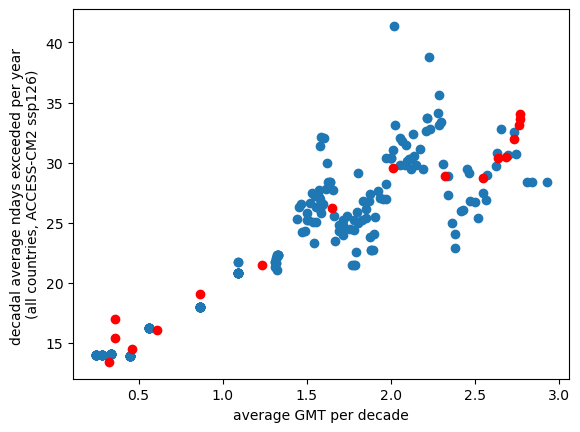

In [35]:
ind_run = 0

# avg fwi exposed
decadal_avg_rcp = ds_lfe_perregion_perrun['landfrac_peryear_perregion_RCP'].coarsen(time_ind=10, boundary='trim').mean().isel(region=5,run=ind_run).values

# decadal GMT 
df = subset[ind_run+1]['GMT']
df_decadal = df.groupby(df.index // 10).mean()
df_decadal.index = df.index[::10][:len(df_decadal)] 
df_decadal['fwi_ndays'] = decadal_avg_rcp

# strj
df = df_GMT_strj
df_decadal_strj = df.groupby(df.index // 10).mean()
df_decadal_strj.index = df.index[::10][:len(df_decadal_strj)] 

# decadal fwi 
df_strj_fwi = ds_lfe_perregion_perrun['landfrac_peryear_perregion_strj'].coarsen(time_ind=10, boundary='trim').mean().isel(region=5,run=ind_run).to_pandas()
df_strj_fwi.index = df_decadal_strj.index

fig, ax = plt.subplots()

ax.scatter(df_decadal_strj, df_strj_fwi)
ax.scatter(df_decadal.tas, df_decadal.fwi_ndays, c='red')

ax.set_xlabel('average GMT per decade')
ax.set_ylabel(f'decadal average ndays exceeded per year \n(all countries, {rename_dict[ind_run+1]})')

Text(0, 0.5, 'decadal average ndays exceeded per year \n(all countries, ACCESS-CM2 ssp245)')

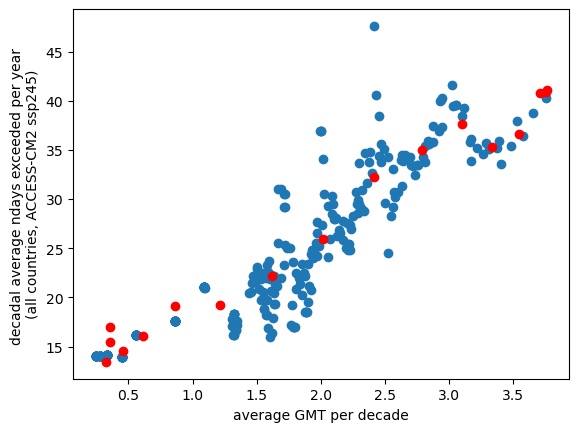

In [34]:
ind_run = 1

# avg fwi exposed
decadal_avg_rcp = ds_lfe_perregion_perrun['landfrac_peryear_perregion_RCP'].coarsen(time_ind=10, boundary='trim').mean().isel(region=5,run=ind_run).values

# decadal GMT 
df = subset[ind_run+1]['GMT']
df_decadal = df.groupby(df.index // 10).mean()
df_decadal.index = df.index[::10][:len(df_decadal)] 
df_decadal['fwi_ndays'] = decadal_avg_rcp

# strj
df = df_GMT_strj
df_decadal_strj = df.groupby(df.index // 10).mean()
df_decadal_strj.index = df.index[::10][:len(df_decadal_strj)] 

# decadal fwi 
df_strj_fwi = ds_lfe_perregion_perrun['landfrac_peryear_perregion_strj'].coarsen(time_ind=10, boundary='trim').mean().isel(region=5,run=ind_run).to_pandas()
df_strj_fwi.index = df_decadal_strj.index

fig, ax = plt.subplots()

ax.scatter(df_decadal_strj, df_strj_fwi)
ax.scatter(df_decadal.tas, df_decadal.fwi_ndays, c='red')

ax.set_xlabel('average GMT per decade')
ax.set_ylabel(f'decadal average ndays exceeded per year \n(all countries, {rename_dict[ind_run+1]})')


In [32]:
d_climate_data_meta[1].keys()

dict_keys(['extreme', 'model', 'scenario', 'GMT', 'GMT_strj_maxdiff', 'GMT_strj_valid', 'ind_RCP2GMT_strj', 'GMT_15_maxdiff', 'GMT_15_valid', 'ind_RCP2GMT_15', 'GMT_20_maxdiff', 'GMT_20_valid', 'ind_RCP2GMT_20', 'GMT_NDC_maxdiff', 'GMT_NDC_valid', 'ind_RCP2GMT_NDC', 'GMT_OS_maxdiff', 'GMT_OS_valid', 'ind_RCP2GMT_OS', 'GMT_noOS_maxdiff', 'GMT_noOS_valid', 'ind_RCP2GMT_noOS'])

### aggregation mmm

In [100]:
ds_lfe_perregion_perrun

<xarray.Dataset>
Dimensions:                          (run: 2, region: 6, time_ind: 170, GMT: 21)
Coordinates:
  * run                              (run) int64 1 2
  * region                           (region) int64 0 1 2 3 4 5
  * time_ind                         (time_ind) int64 0 1 2 3 ... 167 168 169
  * GMT                              (GMT) float64 1.5 1.6 1.7 ... 3.3 3.4 3.5
Data variables:
    landfrac_peryear_perregion_RCP   (run, region, time_ind) float64 17.31 .....
    landfrac_peryear_perregion_15    (run, region, time_ind) float64 14.53 .....
    landfrac_peryear_perregion_20    (run, region, time_ind) float64 14.53 .....
    landfrac_peryear_perregion_NDC   (run, region, time_ind) float64 14.53 .....
    landfrac_peryear_perregion_OS    (run, region, time_ind) float64 14.53 .....
    landfrac_peryear_perregion_noOS  (run, region, time_ind) float64 14.53 .....
    landfrac_peryear_perregion_strj  (run, region, time_ind, GMT) float64 14....

In [55]:
ds_lfe_perregion_perrun['landfrac_peryear_perregion_strj']

<xarray.DataArray 'landfrac_peryear_perregion_strj' (run: 2, region: 6,
                                                     time_ind: 170, GMT: 21)>
array([[[[14.52554476, 14.52554476, 14.52554476, ...,         nan,
                  nan,         nan],
         [14.52554476, 14.52554476, 14.52554476, ...,         nan,
                  nan,         nan],
         [14.52554476, 14.52554476, 14.52554476, ...,         nan,
                  nan,         nan],
         ...,
         [26.08579513, 26.96846512, 23.06027441, ...,         nan,
                  nan,         nan],
         [26.08579513, 20.20397166, 23.06027441, ...,         nan,
                  nan,         nan],
         [26.08579513, 20.20397166, 23.06027441, ...,         nan,
                  nan,         nan]],

        [[10.01027688, 10.01027688, 10.01027688, ...,         nan,
                  nan,         nan],
         [10.01027688, 10.01027688, 10.01027688, ...,         nan,
                  nan,         nan],
         [10.01027688, 10.01027688, 10.01027688, ...,         nan,
                  nan,         nan],
...
         [24.84087362, 23.54983329, 24.88590891, ..., 25.98395106,
          41.03136549, 32.65562954],
         [24.84087362, 23.54983329, 24.88590891, ..., 27.13433299,
          41.0326495 , 32.65562954],
         [24.84087362, 22.67014762, 24.31664518, ..., 37.31282043,
          37.8970632 , 32.65562954]],

        [[14.00200225, 14.00200225, 14.00200225, ..., 14.00200225,
          14.00200225, 14.00200225],
         [14.00200225, 14.00200225, 14.00200225, ..., 14.00200225,
          14.00200225, 14.00200225],
         [14.00200225, 14.00200225, 14.00200225, ..., 14.00200225,
          14.00200225, 14.00200225],
         ...,
         [21.54342927, 18.81412903, 32.34446195, ..., 44.76714291,
          47.24386011, 40.92170215],
         [21.54342927, 18.81412903, 32.34446195, ..., 33.73454044,
          38.1681979 , 40.92170215],
         [21.54342927, 28.04581289, 19.3593093 , ..., 37.97180301,
          30.79125575, 40.92170215]]]])
Coordinates:
  * run       (run) int64 1 2
  * region    (region) int64 0 1 2 3 4 5
  * time_ind  (time_ind) int64 0 1 2 3 4 5 6 7 ... 163 164 165 166 167 168 169
  * GMT       (GMT) float64 1.5 1.6 1.7 1.8 1.9 2.0 ... 3.0 3.1 3.2 3.3 3.4 3.5

In [62]:
other_dims = set(ds_lfe_perregion_perrun.dims) - {'run', 'GMT'}
isel_dict = {dim: 0 for dim in (set(ds_lfe_perregion_perrun.dims) - {'run', 'GMT'})}
isel_dict

{'time_ind': 0, 'region': 0}

In [79]:
ds_lfe_perregion_perrun['landfrac_peryear_perregion_noOS'].isel(**isel_dict).notnull().sum(dim='run') #.to_pandas()

<xarray.DataArray 'landfrac_peryear_perregion_noOS' ()>
array(2)
Coordinates:
    region    int64 0
    time_ind  int64 0

In [75]:
ds_lfe_perregion_perrun['landfrac_peryear_perregion_noOS'].mean(dim='run', skipna=True)

<xarray.DataArray 'landfrac_peryear_perregion_noOS' (region: 6, time_ind: 170)>
array([[14.52554476, 14.52554476, 14.52554476, ..., 15.97646293,
        15.97646293, 15.97646293],
       [10.01027688, 10.01027688, 10.01027688, ..., 20.75139357,
        20.75139357, 20.75139357],
       [ 9.32019892,  9.32019892,  9.32019892, ..., 16.11945631,
        16.11945631, 16.11945631],
       [15.71311353, 15.71311353, 15.71311353, ..., 16.16673026,
        16.16673026, 16.16673026],
       [12.51020858, 12.51020858, 12.51020858, ..., 24.18726347,
        24.18726347, 24.18726347],
       [14.00200225, 14.00200225, 14.00200225, ..., 16.53011318,
        16.53011318, 16.53011318]])
Coordinates:
  * region    (region) int64 0 1 2 3 4 5
  * time_ind  (time_ind) int64 0 1 2 3 4 5 6 7 ... 163 164 165 166 167 168 169

#### test fxn

In [ ]:

def calc_landfraction_exposed_mmm(
    ds_lfe_perrun,
    GMT_extra_trajectories_names
    ):

    # remove from the output a warning that appears often  
    import warnings
    warnings.filterwarnings("ignore", message="All-NaN slice encountered")

    # -------------------------------------------------- #
    #             Computation of MMM and Stats           #
    # -------------------------------------------------- #

    ds_lfe_perrun = ds_lfe_perrun.copy()

    if 'region' in ds_lfe_perrun.dims:

        unit='region'
    
    elif 'country' in ds_lfe_perrun.dims:

        unit='country'
    
    print(f"\nComputing the MMM and stats for each {unit}")

    # loop over target trajectories
    var_suffixes = GMT_extra_trajectories_names+['strj'] 

    for suffix in var_suffixes:
        mmm = ds_lfe_perrun[f'landfrac_peryear_per{unit}_{suffix}'].mean(dim='run', skipna=True)
        mmm_sm = mmm.rolling(time_ind=10, center=True, min_periods=1).mean()
        std = ds_lfe_perrun[f'landfrac_peryear_per{unit}_{suffix}'].std(dim='run', skipna=True)
        std_sm = std.rolling(time_ind=10, center=True, min_periods=1).mean()
        lqntl = ds_lfe_perrun[f'landfrac_peryear_per{unit}_{suffix}'].quantile(
            q=0.25,
            dim='run',
            method='inverted_cdf',
            skipna=True
        )
        uqntl = ds_lfe_perrun[f'landfrac_peryear_per{unit}_{suffix}'].quantile(
            q=0.75,
            dim='run',
            method='inverted_cdf',
            skipna=True
        )
        median = ds_lfe_perrun[f'landfrac_peryear_per{unit}_{suffix}'].quantile(
            q=0.5,
            dim='run',
            method='inverted_cdf',
            skipna=True
        )
        median_sm = median.rolling(time_ind=10, center=True, min_periods=1).mean()

        other_dims = set(ds_lfe_perrun.dims) - {'run', 'GMT'}
        isel_dict = {dim: 0 for dim in other_dims}
        sample_size = ds_lfe_perrun[f'landfrac_peryear_per{unit}_{suffix}'].isel(**isel_dict).notnull().sum(dim='run')

        ds_lfe_perrun[f'mmm_{suffix}'] = mmm
        ds_lfe_perrun[f'mmm_{suffix}_sm'] = mmm_sm
        ds_lfe_perrun[f'std_{suffix}'] = std
        ds_lfe_perrun[f'std_{suffix}_sm'] = std_sm
        ds_lfe_perrun[f'lqntl_{suffix}'] = lqntl
        ds_lfe_perrun[f'uqntl_{suffix}'] = uqntl
        ds_lfe_perrun[f'median_{suffix}'] = median
        ds_lfe_perrun[f'median_{suffix}_sm'] = median_sm
        ds_lfe_perrun[f'sample_size_{suffix}'] = sample_size

    return ds_lfe_perrun.reset_coords().drop_vars('quantile')

In [113]:
ds_lfe_perregion_perrun_mmm = calc_landfraction_exposed_mmm(
    ds_lfe_perregion_perrun,
    GMT_extra_trajectories_names
    )


Computing the MMM and stats for each region


In [ ]:
ds_lfe_perregion_perrun_mmm

<xarray.Dataset>
Dimensions:                          (run: 2, region: 6, time_ind: 170, GMT: 21)
Coordinates:
  * run                              (run) int64 1 2
  * region                           (region) int64 0 1 2 3 4 5
  * time_ind                         (time_ind) int64 0 1 2 3 ... 167 168 169
  * GMT                              (GMT) float64 1.5 1.6 1.7 ... 3.3 3.4 3.5
Data variables: (12/61)
    landfrac_peryear_perregion_RCP   (run, region, time_ind) float64 17.31 .....
    landfrac_peryear_perregion_15    (run, region, time_ind) float64 14.53 .....
    landfrac_peryear_perregion_20    (run, region, time_ind) float64 14.53 .....
    landfrac_peryear_perregion_NDC   (run, region, time_ind) float64 14.53 .....
    landfrac_peryear_perregion_OS    (run, region, time_ind) float64 14.53 .....
    landfrac_peryear_perregion_noOS  (run, region, time_ind) float64 14.53 .....
    ...                               ...
    std_strj_sm                      (region, time_ind, GMT) float64 0.0 ... 0.0
    lqntl_strj                       (region, time_ind, GMT) float64 14.53 .....
    uqntl_strj                       (region, time_ind, GMT) float64 14.53 .....
    median_strj                      (region, time_ind, GMT) float64 14.53 .....
    median_strj_sm                   (region, time_ind, GMT) float64 14.53 .....
    sample_size_strj                 (GMT) int64 2 2 2 2 2 2 2 ... 1 1 1 1 1 1 1

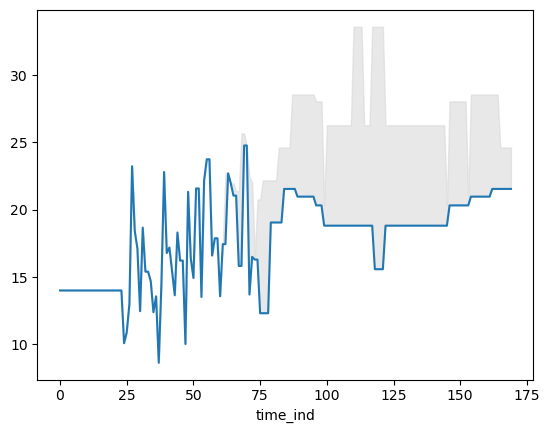

In [ ]:
fig, ax = plt.subplots()

ds_lfe_perregion_perrun_mmm['median_strj'].sel(GMT=1.5,region=5).to_pandas().T.plot(ax=ax)

lqntl=ds_lfe_perregion_perrun_mmm['lqntl_strj'].sel(GMT=1.5,region=5).to_pandas().T
uqntl=ds_lfe_perregion_perrun_mmm['uqntl_strj'].sel(GMT=1.5,region=5).to_pandas().T

ax.fill_between(
    ds_lfe_perregion_perrun_mmm.time_ind,  # or whatever your x-dimension is
    lqntl,
    uqntl,
    color='lightgray',
    alpha=0.5,
    label='Uncertainty range'
)


# only 2 simulations thats why it looks so funky ! 

# 4) Lifetime exposure

Lifetime exopsure and mmm done 

To do 
- user-defined regions - TODO
- rcp and strj pathways - DONE
- subnational shapefiles - TODO

In [2]:

d_countries = preprocess_all_country_data(

    filepath_lifeexpectancy = filepath_lifeexpectancy, # life expectancy data
    start_birthyear=1950,
    end_birthyear=2025,                 # endyear is taken from end_birthyear + max life expectancy

    dir_cohortsizes = dir_cohortsizes,  # cohort size data
    data_source_cohorts='UNWPP2024',
    extend_method='linear',             # note, 'slinear' not implemented for UNWPP2024
    by_sex=False,                       # NOTE by_sex not implemented
                                            
    dir_population= dir_population,     # gridded pop data 
    ssp=2,
    urbanrural=False,                   # NOTE urbanrural not implemented for v2
    bbox = bbox_europe,                        # could use bbox europe!!

    filepath_countrymask = filepath_countrymask,    # country masks 
    data_source_countrymask = 'shapefile',
    fillcoast=False, 
    fix_smallislands=False,
    
    filepath_world_bank = filepath_world_bank_meta, # metadata 
    filepath_lookuptable = filepath_lookuptable,    # country filtering
    filter_countries=True,
    worldbank_filter=True, 
    )

load_country_metadata took 0.26 s


load_unwpp_lifeexpectancy took 26.97 s
get_life_expectancies took 0.00 s
loading cohort sizes from UNWPP2024
load_cohort_sizes took 26.68 s
interpolate_cohortsize_countries took 0.01 s
opening compass - historical
opening compass - ssp2
load_population took 3.92 s
load_countrymask took 3.72 s
preprocess_all_country_data took 61.59 s


In [3]:
df_countries = d_countries['info_pop']
gdf_country_borders = d_countries['borders'] 
da_regions = df_countries['region'].unique()
da_population = d_countries['population_map']
df_birthyears = d_countries['birth_years'] # NA
df_life_expectancy_5 = d_countries['life_expectancy_5']
da_cohort_size = d_countries['cohort_size']
countries_regions, countries_mask = d_countries['mask'] 

In [4]:
df_GMT_15, df_GMT_20, df_GMT_NDC, df_GMT_OS, df_GMT_noOS, ds_GMT_STS, df_GMT_strj = load_GMT(
    year_start=1950,
    year_end=2119,
    gmt_extend_method='10yrtrend',
    smooth_first_decades=True

)

load_GMT took 8.93 s


In [5]:
GCMs = ['ACCESS-CM2', 'CNRM-ESM2-1', 'CanESM5', 'EC-EARTH', 'MPI-ESM1-2-HR', 'MRI-ESM2-0']
scenarios = ['ssp126', 'ssp245', 'ssp370', 'ssp585']
GMT_extra_trajectories_names = ['15', '20', 'NDC', 'OS', 'noOS']
climatedata_dir = '/vscmnt/brussel_pixiu_data/_data_brussel/vo/000/bvo00012/vsc10419/fwi-portugal/data/preprocessed/FWI'

d_climate_data_meta = load_climate_data(
    extremes = "FWI95d",                   # e.g. "FWI95d"
    model_names = GCMs[0:2],                # GCMs
    df_GMT_strj =df_GMT_strj ,                # stylized trajectories
    GMT_extra_trajectories = [df_GMT_15, df_GMT_20, df_GMT_NDC, df_GMT_OS, df_GMT_noOS],
    GMT_extra_trajectories_names = ['15', '20', 'NDC', 'OS', 'noOS'],
    climatedata_dir = '/vscmnt/brussel_pixiu_data/_data_brussel/vo/000/bvo00012/vsc10419/fwi-portugal/data/preprocessed/FWI',     # structure should be : climatedata_dir/scenario/model/'*{model}*{extreme}.nc
    filepath_model_gmst = os.path.join(data_dir, 'gmst-models/gmst_models_1850_2100_fwi.csv'),
    scenarios = scenarios,
    smoothing=True,
    rolling_window=21,
    min_periods=1,
    gmt_anomaly_baseline_period = (1985,2014),
    gmt_anomaly_correction = 0.74,
    year_start=1950,
    year_end = 2119,            # 2025 + max life expectancy
    gmt_mapping_method = 'year-to-year', 
    max_diff_valid = .2, 
    )

Processing climate data
Processing for FWI95d


In [6]:
len(d_climate_data_meta)

8

In [7]:
for i in list(d_climate_data_meta.keys()):
    scenario = d_climate_data_meta[i]['scenario']
    model = d_climate_data_meta[i]['model']
    print(i, model, scenario)

1 ACCESS-CM2 ssp126
2 ACCESS-CM2 ssp245
3 ACCESS-CM2 ssp370
4 ACCESS-CM2 ssp585
5 CNRM-ESM2-1 ssp126
6 CNRM-ESM2-1 ssp245
7 CNRM-ESM2-1 ssp370
8 CNRM-ESM2-1 ssp585


### dev

In [8]:
df_life_expectancy_5

Country,Albania,Algeria,Andorra,Austria,Belarus,Belgium,Bosnia and Herzegovina,Bulgaria,Croatia,Cyprus,...,Serbia,Slovakia,Slovenia,Spain,Sweden,Switzerland,Tunisia,Türkiye,Ukraine,United Kingdom
Year,,,,,,,,,,,,,,,,,,,,,
1950,72.2933,60.0833,78.4736,77.328,75.3355,77.8648,70.1355,78.4307,76.3165,72.2451,...,74.7094,77.6059,76.3769,77.7527,80.1749,78.3759,62.9397,74.215,76.4168,78.2731
1951,73.117,59.9968,78.7848,77.2763,75.7719,78.0135,70.4649,77.6914,76.5287,72.5645,...,75.0297,77.7876,76.4921,77.2738,80.219,78.4089,63.4908,74.3061,76.7791,78.4502
1952,74.0791,59.8907,79.0685,77.0455,76.1716,78.1412,71.15,78.6301,76.8597,72.8389,...,75.8287,77.2865,76.5532,77.2174,80.0601,78.6051,64.2125,73.4723,77.1535,78.5535
1953,75.0774,59.7686,79.449,77.7793,76.8768,78.4919,71.7558,79.5434,77.093,73.1858,...,76.5709,78.4581,76.8142,78.9503,80.5827,79.2188,64.7408,72.9428,77.3328,78.6526
1954,75.9208,59.6571,79.7661,77.7012,77.8036,78.8723,72.8119,77.5044,77.2357,73.5729,...,77.1057,77.8273,77.0635,78.8173,80.8428,79.4077,65.2574,73.5414,77.8302,78.7528
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021,86.7605,84.3678,90.9386,88.7147,81.1799,88.8552,84.8188,82.5465,85.3918,88.3808,...,83.6672,85.1695,88.2295,90.3076,89.9191,90.6576,83.9189,85.1218,81.44,88.0767
2022,86.923,84.5161,91.0655,88.8823,81.3517,88.9993,84.9906,82.6858,85.5442,88.5442,...,83.8383,85.3294,88.3943,90.4504,90.0557,90.7919,84.0811,85.2946,81.5875,88.2177
2023,87.0848,84.6631,91.1889,89.044,81.5236,89.1554,85.1543,82.8324,85.7104,88.712,...,84.0101,85.4824,88.5423,90.5779,90.1884,90.9169,84.2544,85.4623,81.7357,88.3511


In [9]:
region_names = np.concatenate([df_countries['region'].dropna().unique(),
                        df_countries['incomegroup'].dropna().unique(),
                        ['World'] # if using a bbox this is all countries in the bbox - rename to all_countries? 
])

In [10]:
region_names

array(['Europe & Central Asia', 'Middle East & North Africa',
       'Upper middle income', 'High income', 'Lower middle income',
       'World'], dtype=object)

In [11]:
region=region_names[0]
countries = get_countries_of_region(region, df_countries)

countries

array(['Albania', 'Andorra', 'Austria', 'Belarus', 'Belgium',
       'Bosnia and Herzegovina', 'Bulgaria', 'Croatia', 'Cyprus',
       'Czechia', 'Denmark', 'Estonia', 'Faroe Islands', 'Finland',
       'France', 'Germany', 'Greece', 'Hungary', 'Iceland', 'Ireland',
       'Isle of Man', 'Italy', 'Kosovo (under UNSC res. 1244)', 'Latvia',
       'Liechtenstein', 'Lithuania', 'Luxembourg', 'Republic of Moldova',
       'Montenegro', 'Netherlands', 'North Macedonia', 'Norway', 'Poland',
       'Portugal', 'Romania', 'Russian Federation', 'San Marino',
       'Serbia', 'Slovakia', 'Slovenia', 'Spain', 'Sweden', 'Switzerland',
       'Türkiye', 'Ukraine', 'United Kingdom'], dtype=object)

In [12]:
da_cohort_size.sel(country=countries,ages=0).to_pandas().T

country,Albania,Andorra,Austria,Belarus,Belgium,Bosnia and Herzegovina,Bulgaria,Croatia,Cyprus,Czechia,...,San Marino,Serbia,Slovakia,Slovenia,Spain,Sweden,Switzerland,Türkiye,Ukraine,United Kingdom
time,,,,,,,,,,,,,,,,,,,,,
1950,44.9960,0.0900,104.2320,171.4230,140.6925,87.9955,167.1760,90.1000,15.4300,176.9800,...,0.2665,142.9075,85.0345,33.3910,503.4265,116.0910,82.7000,856.9695,796.1125,823.9080
1951,47.0370,0.0890,99.8760,161.4305,138.3720,89.1215,156.7990,86.1985,14.0010,177.7005,...,0.2470,140.2570,89.7890,33.0090,495.9360,110.7775,81.7000,920.4510,810.1820,790.8355
1952,49.3705,0.0890,97.9520,166.8075,139.1095,93.2300,142.8090,85.0035,14.1200,175.9125,...,0.2425,139.3265,94.2165,33.0135,552.6540,108.2515,81.5010,951.1195,810.4395,772.1995
1953,51.5180,0.0870,98.5520,170.6415,141.4040,100.5610,144.0940,87.1645,14.2155,170.9830,...,0.2410,138.3055,94.8320,33.1835,564.9985,108.2735,82.5010,980.5275,803.1425,778.2745
1954,52.9470,0.0935,99.2820,177.3525,142.7940,104.4975,141.8500,88.5955,14.3285,166.2790,...,0.2405,138.5595,94.6475,32.8780,558.8300,105.8345,83.0510,998.4470,789.3915,779.7845
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2115,7.1850,0.2800,58.5715,28.9865,91.3640,9.8790,28.9475,15.5705,9.9765,70.0345,...,0.2370,27.7560,26.0700,13.2290,245.3950,95.2025,77.4135,444.9415,79.3285,637.5695
2116,7.1850,0.2800,58.5715,28.9865,91.3640,9.8790,28.9475,15.5705,9.9765,70.0345,...,0.2370,27.7560,26.0700,13.2290,245.3950,95.2025,77.4135,444.9415,79.3285,637.5695
2117,7.1850,0.2800,58.5715,28.9865,91.3640,9.8790,28.9475,15.5705,9.9765,70.0345,...,0.2370,27.7560,26.0700,13.2290,245.3950,95.2025,77.4135,444.9415,79.3285,637.5695


In [13]:
df_life_expectancy_5[countries]

Country,Albania,Andorra,Austria,Belarus,Belgium,Bosnia and Herzegovina,Bulgaria,Croatia,Cyprus,Czechia,...,San Marino,Serbia,Slovakia,Slovenia,Spain,Sweden,Switzerland,Türkiye,Ukraine,United Kingdom
Year,,,,,,,,,,,,,,,,,,,,,
1950,72.2933,78.4736,77.328,75.3355,77.8648,70.1355,78.4307,76.3165,72.2451,77.3027,...,79.984,74.7094,77.6059,76.3769,77.7527,80.1749,78.3759,74.215,76.4168,78.2731
1951,73.117,78.7848,77.2763,75.7719,78.0135,70.4649,77.6914,76.5287,72.5645,77.52,...,80.1004,75.0297,77.7876,76.4921,77.2738,80.219,78.4089,74.3061,76.7791,78.4502
1952,74.0791,79.0685,77.0455,76.1716,78.1412,71.15,78.6301,76.8597,72.8389,77.1233,...,80.2103,75.8287,77.2865,76.5532,77.2174,80.0601,78.6051,73.4723,77.1535,78.5535
1953,75.0774,79.449,77.7793,76.8768,78.4919,71.7558,79.5434,77.093,73.1858,77.9136,...,80.3279,76.5709,78.4581,76.8142,78.9503,80.5827,79.2188,72.9428,77.3328,78.6526
1954,75.9208,79.7661,77.7012,77.8036,78.8723,72.8119,77.5044,77.2357,73.5729,77.6762,...,80.4532,77.1057,77.8273,77.0635,78.8173,80.8428,79.4077,73.5414,77.8302,78.7528
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021,86.7605,90.9386,88.7147,81.1799,88.8552,84.8188,82.5465,85.3918,88.3808,86.4473,...,92.1469,83.6672,85.1695,88.2295,90.3076,89.9191,90.6576,85.1218,81.44,88.0767
2022,86.923,91.0655,88.8823,81.3517,88.9993,84.9906,82.6858,85.5442,88.5442,86.5876,...,92.2586,83.8383,85.3294,88.3943,90.4504,90.0557,90.7919,85.2946,81.5875,88.2177
2023,87.0848,91.1889,89.044,81.5236,89.1554,85.1543,82.8324,85.7104,88.712,86.7213,...,92.3716,84.0101,85.4824,88.5423,90.5779,90.1884,90.9169,85.4623,81.7357,88.3511


In [14]:
values = df_life_expectancy_5[countries]
weights = da_cohort_size.sel(country=countries, ages=0).to_pandas().T.loc[values.index]

# Weighted mean across columns
weighted_mean = (values * weights).sum(axis=1) / weights.sum(axis=1)

<Axes: xlabel='Year'>

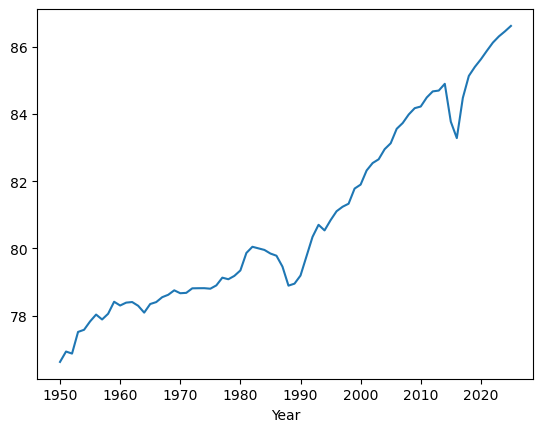

In [15]:
weighted_mean.plot()

### test fxn

In [ ]:



@timeit
def calc_lifetime_exposure(
    d_climate_data_meta, 
    df_countries, 
    countries_regions, 
    countries_mask, 
    climatedata_dir,
    da_population, 
    df_life_expectancy_5,
    da_cohort_size,
    GMT_labels = None , #df_GMT_strj.columns
    GMT_extra_trajectories_names=None,
    start_birthyear=1950,
    end_birthyear=2025,
    year_start=1950,
    year_end=2119,
    bbox=None,
):

    def calc_life_exposure(
        df_exposure,
        df_life_expectancy,
        col,
    ):
        # initialise birth years 
        exposure_birthyears_percountry = np.empty(len(df_life_expectancy))

        for i, birth_year in enumerate(df_life_expectancy.index):
            life_expectancy = df_life_expectancy.loc[birth_year,col] 

            # define death year based on life expectancy
            death_year = birth_year + np.floor(life_expectancy)

            # integrate exposure over full years lived
            exposure_birthyears_percountry[i] = df_exposure.loc[birth_year:death_year,col].sum()

            # add exposure during last (partial) year
            exposure_birthyears_percountry[i] = exposure_birthyears_percountry[i] + \
                df_exposure.loc[death_year+1,col].sum() * \
                    (life_expectancy - np.floor(life_expectancy))

        # a series for each column to somehow group into a dataframe
        exposure_birthyears_percountry = pd.Series(
            exposure_birthyears_percountry,
            index=df_life_expectancy.index,
            name=col,
        )

        return exposure_birthyears_percountry


    # 1) Build Dataset for regions result

    # get regions and income groups and 'World' (=all countries)
    region_names = np.concatenate([df_countries['region'].dropna().unique(),
                            df_countries['incomegroup'].dropna().unique(),
                            ['World'] # if using a bbox this is all countries in the bbox - rename to all_countries? 
    ])

    # Shared shape for all variables
    nregions = len(region_names)

    birth_years = np.arange(start_birthyear, end_birthyear+1)

    year_range = np.arange(year_start, year_end+1)

    shape = (
        len(d_climate_data_meta), 
        nregions, 
        len(birth_years))

    shape_strj = (
        len(d_climate_data_meta), 
        nregions, 
        len(birth_years), 
        len(GMT_labels))

    # Build the data_vars dictionary in a loop
    
    var_suffixes = ['RCP']+GMT_extra_trajectories_names 

    data_vars = {}
    for suffix in var_suffixes:
        var_name = f'le_perregion_perrun_{suffix}'
        data_vars[var_name] = (
            ['run', 'region', 'birth_year'],
            np.full(shape, np.nan)
        )

    data_vars['le_perregion_perrun_strj'] = (
            ['run', 'region', 'birth_year', 'GMT'],
            np.full(shape_strj, np.nan)

    )

    # Build the dataset
    ds_le_perregion_perrun = xr.Dataset(
        data_vars=data_vars,
        coords={
            'run': ('run', np.arange(1, len(d_climate_data_meta) + 1)),
            'region': ('region', np.arange(0, nregions)),
            'birth_year': ('birth_year', birth_years),
            'GMT': ('GMT', GMT_labels)
        }
    )

    # 2) Build Dataset for country result

    # Shared shape for all variables
    shape = (
        len(d_climate_data_meta),
        len(df_countries['name'].values),
        len(birth_years)
    )

    shape_strj = (
        len(d_climate_data_meta), 
        len(df_countries['name'].values), 
        len(birth_years), 
        len(GMT_labels))


    # Build the data_vars dictionary in a loop
    data_vars = {}
    for suffix in var_suffixes:
        var_name = f'le_percountry_perrun_{suffix}'
        data_vars[var_name] = (
            ['run', 'country', 'birth_year'],
            np.full(shape, np.nan)
        )

    data_vars['le_percountry_perrun_strj'] = (
            ['run', 'region', 'birth_year', 'GMT'],
            np.full(shape_strj, np.nan)
    )

    # Build the dataset
    ds_le_percountry_perrun = xr.Dataset(
        data_vars=data_vars,
        coords={
            'run': ('run', np.arange(1, len(d_climate_data_meta) + 1)),
            'country': ('country', df_countries['name'].values),
            'birth_year': ('birth_year', birth_years),
            'GMT': ('GMT', GMT_labels)
        }
    )


    # loop over simulations
    
    for i in list(d_climate_data_meta.keys()): 

        print('                         🟠 Remapping Simulation {} of {} 🟠\n'.format(i,len(d_climate_data_meta)))

        scenario = d_climate_data_meta[i]['scenario']
        model = d_climate_data_meta[i]['model']
        extreme = d_climate_data_meta[i]['extreme']

        da_AFA = load_climate_data_array(climatedata_dir,
                    scenario,
                    model,
                    extreme,
                    year_start,
                    year_end,
                    bbox
                    )
        
        #---------------------------------------------------------------------#
        # Computation of the weighted by population field mean of AFA for     # 
        # each ISIMIP simulations for each country                            #
        #---------------------------------------------------------------------#

        # initialise dict
        d_exposure_percountry = {}

        print('⏳ Computing the Population-Weighted Spatial Average of the Exposure for all countries\n')

        # get spatial average per country
        for j, country in enumerate(df_countries['name']): 

            print(f'Computing LFE in {country}                              ', end='\r')

            # calculate mean per country weighted by population
            ind_country = countries_regions.map_keys(country)

            # historical + RCP simulations
            d_exposure_percountry[country] = calc_weighted_fldmean( 
                da_AFA,
                countries_mask, 
                ind_country,
                weights=da_population, 
                areaweighted=False
            )
                        
        # Convert dict to dataframe for vectorizing and integrate exposures   
        # avg population-weighted exposure per country per year
        frame = {k:v.values for k,v in d_exposure_percountry.items()}
        df_exposure_percountry = pd.DataFrame(frame,index=year_range)         

        # initialise dict
        d_exposure_perregion = {}
        d_life_expectancy_perregion = {}

        print('⏳ Computing the Population-Weighted Spatial Average of the Exposure for all regions\n')

        # get spatial average per region 
        for ind_region,region in enumerate(region_names): 

            print(f'Computing LFE in {region}                 ', end='\r')

            countries = get_countries_of_region(region, df_countries)

            ind_country = countries_regions.map_keys(countries)

            # historical + RCP simulations
            d_exposure_perregion[region] = calc_weighted_fldmean( 
                da_AFA,
                countries_mask, 
                ind_country,
                weights=da_population, 
                areaweighted=False
            )

            # weighted avg life expectancy, weighted by n of people aged 0 per country 
            values = df_life_expectancy_5[countries]
            weights = da_cohort_size.sel(country=countries, ages=0).to_pandas().T.loc[values.index]

            d_life_expectancy_perregion[region] = (values * weights).sum(axis=1) / weights.sum(axis=1)

        
        # Convert dict to dataframe for vectorizing and integrate exposures   
        # avg population-weighted exposure per country per year
        frame = {k:v.values for k,v in d_exposure_perregion.items()}
        df_exposure_perregion = pd.DataFrame(frame,index=year_range)  

        frame = {k:v.values for k,v in d_life_expectancy_perregion.items()}
        df_life_expectancy_perregion = pd.DataFrame(frame,index=birth_years)  

        print('🟢 Population-Weighted Spatial Average of the Exposure for all countries and regions Computed')



        # loop over warming scenarios : RCP (model years), example trajs, stylized trajectories (strj)
        # TODO: do it also per RCP scenario?? add this! 
        for suffix in var_suffixes+['strj']:

            if suffix =='RCP':

                pass
        
            elif suffix in var_suffixes:

                print(f'Computing land fraction exposed (LFE) for {suffix} \n')

                if d_climate_data_meta[i][f'GMT_{suffix}_valid']: # if valid

                    ind_RCP = d_climate_data_meta[i][f'ind_RCP2GMT_{suffix}']

                    # remap per pathway and calc lifetime exposure per country 
                    d_le_percountry_perrun = df_exposure_percountry.apply(
                        lambda col: calc_life_exposure(
                            df_exposure_percountry.reindex(df_exposure_percountry.index[ind_RCP]).set_index(df_exposure_percountry.index),
                            df_life_expectancy_5,
                            col.name,
                            ),
                        axis=0,
                        )

                    # convert dataframe to data array of lifetime exposure (le) per country and birth year
                    ds_le_percountry_perrun[f'le_percountry_perrun_{suffix}'].loc[{
                        'run':i,
                    }] = d_le_percountry_perrun.values.transpose() 


                    # remap per pathway and calc lifetime exposure per region 
                    d_le_perregion_perrun = df_exposure_perregion.apply(
                        lambda col: calc_life_exposure(
                            df_exposure_perregion.reindex(df_exposure_perregion.index[ind_RCP]).set_index(df_exposure_perregion.index),
                            df_life_expectancy_perregion,
                            col.name,
                            ),
                        axis=0,
                        )

                    # convert dataframe to data array of lifetime exposure (le) per country and birth year
                    ds_le_perregion_perrun[f'le_perregion_perrun_{suffix}'].loc[{
                        'run':i,
                    }] = d_le_perregion_perrun.values.transpose() 
                
            elif suffix == 'strj':

                pass


    return ds_le_percountry_perrun, ds_le_perregion_perrun, region_names

In [8]:
subset = dict(list(d_climate_data_meta.items())[0:2])


In [45]:
ds_le_percountry_perrun, ds_le_perregion_perrun, region_names = calc_lifetime_exposure(
    subset, 
    df_countries, 
    countries_regions, 
    countries_mask, 
    climatedata_dir,
    da_population, 
    df_life_expectancy_5,
    da_cohort_size,
    GMT_labels = df_GMT_strj.columns , 
    GMT_extra_trajectories_names=GMT_extra_trajectories_names,
    start_birthyear=1950,
    end_birthyear=2025,
    year_start=1950,
    year_end=2119,
    bbox=None,)

                         🟠 Remapping Simulation 1 of 2 🟠

Loading /vscmnt/brussel_pixiu_data/_data_brussel/vo/000/bvo00012/vsc10419/fwi-portugal/data/preprocessed/FWI/historical/ACCESS-CM2/FWI_ACCESS-CM2_1950_2014_FWI95d.nc
Loading /vscmnt/brussel_pixiu_data/_data_brussel/vo/000/bvo00012/vsc10419/fwi-portugal/data/preprocessed/FWI/ssp126/ACCESS-CM2/FWI_ACCESS-CM2_2015_2100_FWI95d.nc
load_climate_data_array took 0.08 s
⏳ Computing the Population-Weighted Spatial Average of the Exposure for all countries

⏳ Computing the Population-Weighted Spatial Average of the Exposure for all regions

🟢 Population-Weighted Spatial Average of the Exposure for all countries and regions Computed
Computing land fraction exposed (LFE) for 15 

Computing land fraction exposed (LFE) for 20 

Computing land fraction exposed (LFE) for NDC 

Computing land fraction exposed (LFE) for OS 

Computing land fraction exposed (LFE) for noOS 

                         🟠 Remapping Simulation 2 of 2 🟠

Loading /vscmnt/b

In [35]:
GMT_labels = df_GMT_strj.columns 
GMT_extra_trajectories_names=GMT_extra_trajectories_names
start_birthyear=1950
end_birthyear=2025
year_start=1950
year_end=2119
bbox=None

In [ ]:
ds_le_percountry_perrun

{'Europe & Central Asia': array([76.61807719272433, 76.92733115403227, 76.86646561256713,
        77.51110126000687, 77.57529776002349, 77.82389570635502,
        78.02808589233858, 77.8823294300788, 78.05189525306932,
        78.40994745586113, 78.29811926351107, 78.38369321830258,
        78.4012943130925, 78.28952088843722, 78.08590955741386,
        78.34235406776624, 78.39966448824414, 78.54597769499385,
        78.61762035110675, 78.75009310880279, 78.66348851261073,
        78.67508059687246, 78.80958618548914, 78.81282481362602,
        78.81396264022995, 78.79823005622099, 78.89677961695239,
        79.12722640553699, 79.08023320308808, 79.1801983594174,
        79.34225307441422, 79.86312104285761, 80.04681630219036,
        79.99994510676846, 79.95293976397127, 79.8456783416041,
        79.78064830405737, 79.45648025241435, 78.88950540693915,
        78.94860867200119, 79.19023488833766, 79.76548161551065,
        80.34139102279521, 80.70159822365378, 80.53461129616468,
    

### test fxn with RCP and strj also!

Visualize result : by definition i think this biases lower than the original stylized trajectory? Not sure, check with all simulations - but first try to speed up fxn

v1: 292.84 s

v2:

In [8]:
subset = dict(list(d_climate_data_meta.items())[0:2]) # faster to run 


In [9]:
ds_le_percountry_perrun, ds_le_perregion_perrun, region_names, df_life_expectancy_perregion = calc_lifetime_exposure(
    subset, 
    df_countries, 
    countries_regions, 
    countries_mask, 
    climatedata_dir,
    da_population, 
    df_life_expectancy_5,
    da_cohort_size,
    GMT_labels = df_GMT_strj.columns , 
    GMT_extra_trajectories_names=GMT_extra_trajectories_names,
    start_birthyear=1950,
    end_birthyear=2025,
    year_start=1950,
    year_end=2119,
    bbox=bbox_europe,)

                         🟠 Remapping Simulation 1 of 2 🟠

Loading /vscmnt/brussel_pixiu_data/_data_brussel/vo/000/bvo00012/vsc10419/fwi-portugal/data/preprocessed/FWI/historical/ACCESS-CM2/FWI_ACCESS-CM2_1950_2014_FWI95d.nc
Loading /vscmnt/brussel_pixiu_data/_data_brussel/vo/000/bvo00012/vsc10419/fwi-portugal/data/preprocessed/FWI/ssp126/ACCESS-CM2/FWI_ACCESS-CM2_2015_2100_FWI95d.nc
load_climate_data_array took 0.11 s
⏳ Computing the Population-Weighted Spatial Average of the Exposure for all countries

⏳ Computing the Population-Weighted Spatial Average of the Exposure for all regions            

🟢 Population-Weighted Spatial Average of the Exposure for all countries and regions Computed
Computing lifetime exposure (LE) for RCP 

Computing lifetime exposure (LE) for 15 

Computing lifetime exposure (LE) for 20 

Computing lifetime exposure (LE) for NDC 

Computing lifetime exposure (LE) for OS 

Computing lifetime exposure (LE) for noOS 

Computing lifetime exposure (LE) for strj 

 

In [10]:
rename_dict = {
    i: f"{subset[i]['model']} {subset[i]['scenario']}"
    for i in subset.keys()
}
rename_dict

{1: 'ACCESS-CM2 ssp126', 2: 'ACCESS-CM2 ssp245'}

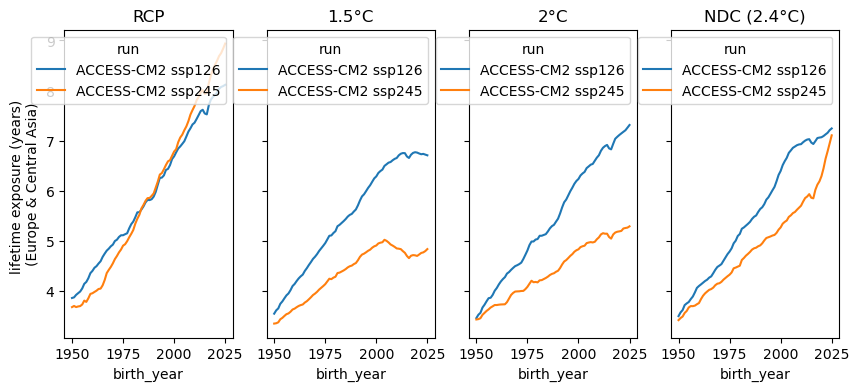

In [11]:
fig, axes = plt.subplots(1,4,sharey=True,figsize=(10,4))

(ds_le_perregion_perrun.sel(region=0)['le_perregion_perrun_RCP'].to_pandas().T/365 ).rename(columns=rename_dict).plot(ax=axes[0])
(ds_le_perregion_perrun.sel(region=0)['le_perregion_perrun_15'].to_pandas().T /365 ).rename(columns=rename_dict).plot(ax=axes[1])
(ds_le_perregion_perrun.sel(region=0)['le_perregion_perrun_20'].to_pandas().T /365 ).rename(columns=rename_dict).plot(ax=axes[2])
(ds_le_perregion_perrun.sel(region=0)['le_perregion_perrun_NDC'].to_pandas().T /365 ).rename(columns=rename_dict).plot(ax=axes[3])

labels = ['RCP', '1.5°C', '2°C',  'NDC (2.4°C)',]

for i,ax in enumerate(axes):
    ax.set_title(labels[i])

axes[0].set_ylabel(f'lifetime exposure (years) \n({region_names[0]})');

In [12]:
region_names

array(['Europe & Central Asia', 'Middle East & North Africa',
       'Upper middle income', 'High income', 'Lower middle income',
       'World'], dtype=object)

In [13]:
rename_dict = {
    i: region
    for i, region in enumerate(region_names)
}

rename_dict

{0: 'Europe & Central Asia',
 1: 'Middle East & North Africa',
 2: 'Upper middle income',
 3: 'High income',
 4: 'Lower middle income',
 5: 'World'}

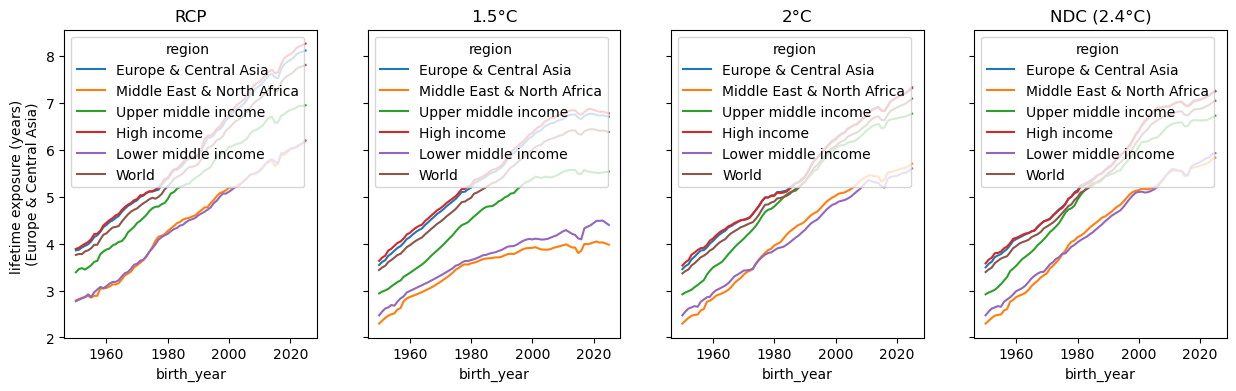

In [14]:
fig, axes = plt.subplots(1,4,sharey=True,figsize=(15,4))

(ds_le_perregion_perrun.sel(run=1)['le_perregion_perrun_RCP'].to_pandas().T/365 ).rename(columns=rename_dict).plot(ax=axes[0], label=region_names)
(ds_le_perregion_perrun.sel(run=1)['le_perregion_perrun_15'].to_pandas().T /365 ).rename(columns=rename_dict).plot(ax=axes[1])
(ds_le_perregion_perrun.sel(run=1)['le_perregion_perrun_20'].to_pandas().T /365 ).rename(columns=rename_dict).plot(ax=axes[2])
(ds_le_perregion_perrun.sel(run=1)['le_perregion_perrun_NDC'].to_pandas().T /365 ).rename(columns=rename_dict).plot(ax=axes[3])

labels = ['RCP', '1.5°C', '2°C',  'NDC (2.4°C)',]

for i,ax in enumerate(axes):
    ax.set_title(labels[i])

axes[0].set_ylabel(f'lifetime exposure (years) \n({region_names[0]})');

In [15]:
ds_le_perregion_perrun

<xarray.Dataset>
Dimensions:                   (run: 2, region: 6, birth_year: 76, GMT: 21)
Coordinates:
  * run                       (run) int64 1 2
  * region                    (region) int64 0 1 2 3 4 5
  * birth_year                (birth_year) int64 1950 1951 1952 ... 2024 2025
  * GMT                       (GMT) float64 1.5 1.6 1.7 1.8 ... 3.2 3.3 3.4 3.5
Data variables:
    le_perregion_perrun_RCP   (run, region, birth_year) float64 1.407e+03 ......
    le_perregion_perrun_15    (run, region, birth_year) float64 1.293e+03 ......
    le_perregion_perrun_20    (run, region, birth_year) float64 1.261e+03 ......
    le_perregion_perrun_NDC   (run, region, birth_year) float64 1.275e+03 ......
    le_perregion_perrun_OS    (run, region, birth_year) float64 1.236e+03 ......
    le_perregion_perrun_noOS  (run, region, birth_year) float64 1.23e+03 ... ...
    le_perregion_perrun_strj  (run, region, birth_year, GMT) float64 1.261e+0...

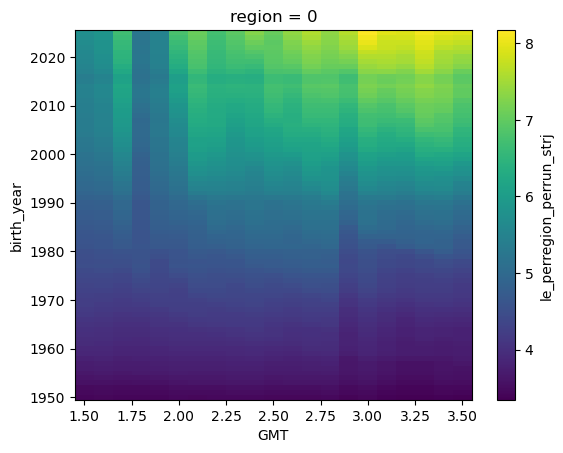

In [16]:
( ds_le_perregion_perrun['le_perregion_perrun_strj'].isel(region=0) / 365).median(dim='run',skipna=True).plot()

Text(0, 0.5, 'lifetime exposure (years)')

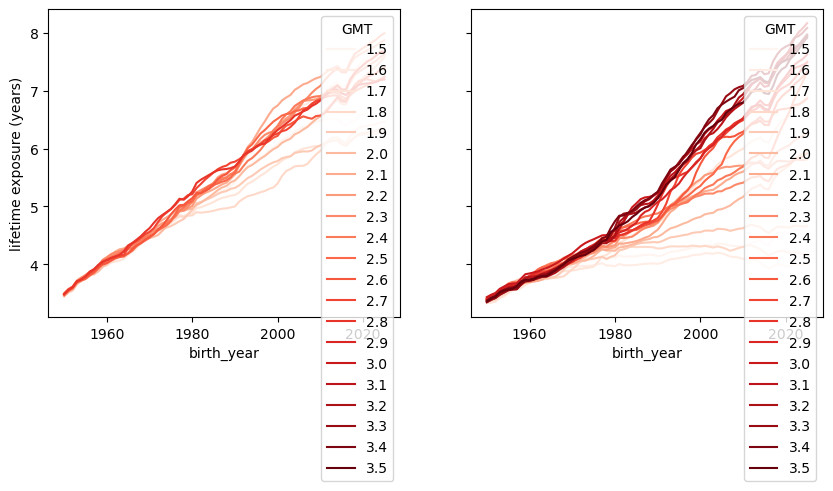

In [17]:
fig,axes=plt.subplots(1,2, sharey=True,figsize=(10,4))

( ds_le_perregion_perrun['le_perregion_perrun_strj'].isel(region=0,run=0) / 365).to_pandas().plot(cmap='Reds',ax=axes[0])

( ds_le_perregion_perrun['le_perregion_perrun_strj'].isel(region=0,run=1) / 365).to_pandas().plot(cmap='Reds',ax=axes[1])

axes[0].set_ylabel('lifetime exposure (years)')

# doesnt look great to me tbh... why would the 2 deg lexp be higher than the 3+ degrees? too noisy? 
# could look at the land fraction exposed for the same thing over time - look at this in the FWI data
# could be an issue related to that this is an ssp126 scenario? 

<Axes: xlabel='GMT'>

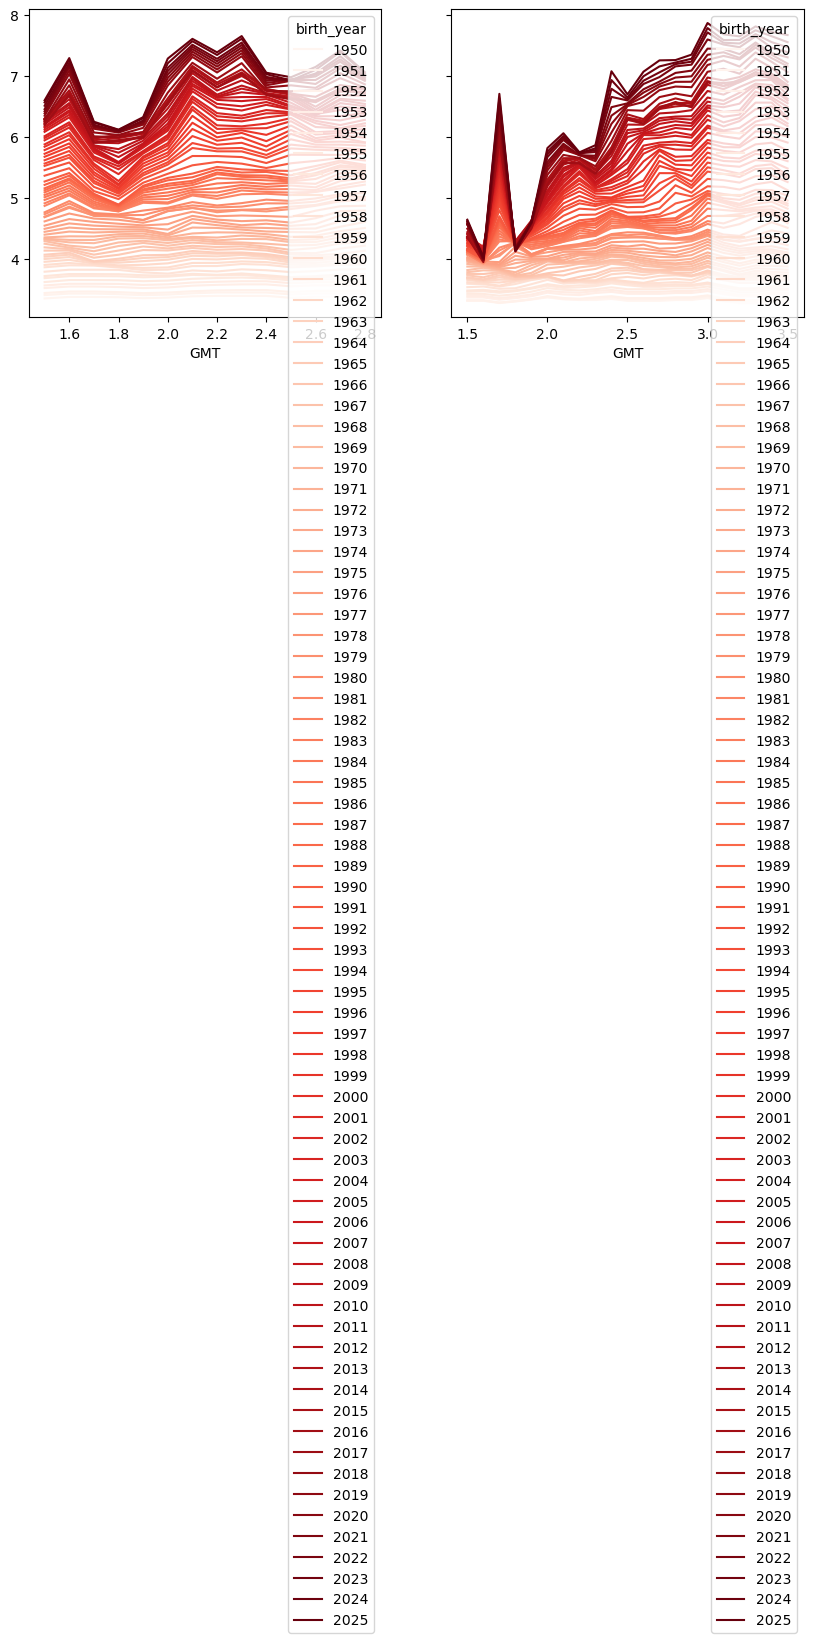

In [18]:
fig,axes=plt.subplots(1,2, sharey=True,figsize=(10,4))


( ds_le_perregion_perrun['le_perregion_perrun_strj'].isel(region=-1,run=0) / 365).to_pandas().T.plot(cmap='Reds',ax=axes[0])

( ds_le_perregion_perrun['le_perregion_perrun_strj'].isel(region=-1,run=1) / 365).to_pandas().T.plot(cmap='Reds',ax=axes[1])


# this is what amaury takes slopes from? to me doesnt very linear - check multiple different simulations 
# hotter simulations better

### mmm aggregation fxns

In [ ]:
# def calc_lifetime_exposure_mmm(
#     ds_le_perrun,
#     GMT_extra_trajectories_names,
#     year_ref=1950
#     ):

#     """
#     Note changed how the EMF is calculated! 

#     """

#         # remove from the output a warning that appears often  
#     import warnings
#     warnings.filterwarnings("ignore", message="All-NaN slice encountered")

#     # -------------------------------------------------- #
#     #             Computation of MMM and Stats           #
#     # -------------------------------------------------- #

#     ds_perrun = ds_le_perrun.copy()

#     if 'region' in ds_perrun.dims:

#         unit='region'
    
#     elif 'country' in ds_perrun.dims:

#         unit='country'
    
#     print(f"\nComputing the MMM and stats for each {unit}")

#     # loop over target trajectories
#     var_suffixes = GMT_extra_trajectories_names+['strj'] 

#     for suffix in var_suffixes:

#         var_name = f'le_per{unit}_perrun_{suffix}'

#         mmm = ds_perrun[var_name].mean(dim='run', skipna=True)
#         std = ds_perrun[var_name].std(dim='run', skipna=True)
#         lqntl = ds_perrun[var_name].quantile(
#             q=0.25,
#             dim='run',
#             method='inverted_cdf',
#             skipna=True
#         )
#         uqntl = ds_perrun[var_name].quantile(
#             q=0.75,
#             dim='run',
#             method='inverted_cdf',
#             skipna=True
#         )
#         median = ds_perrun[var_name].quantile(
#             q=0.5,
#             dim='run',
#             method='inverted_cdf',
#             skipna=True
#         )

#         # number of valid remapped trajectories 
#         other_dims = set(ds_perrun.dims) - {'run', 'GMT'}
#         isel_dict = {dim: 0 for dim in other_dims}
#         sample_size = ds_perrun[var_name].isel(**isel_dict).notnull().sum(dim='run')

#         # EMF compared to reference birthyear
#         EMF = ds_perrun[var_name] / ds_perrun[var_name].sel(birth_year=year_ref)

#         mmm_EMF = EMF.mean(dim='run', skipna=True)
#         lqntl_EMF = EMF.quantile(
#             q=0.25,
#             dim='run',
#             method='inverted_cdf',
#             skipna=True
#         )
#         uqntl_EMF = EMF.quantile(
#             q=0.75,
#             dim='run',
#             method='inverted_cdf',
#             skipna=True
#         )
#         median_EMF = EMF.quantile(
#             q=0.5,
#             dim='run',
#             method='inverted_cdf',
#             skipna=True
#         )

#         # TODO: make a quantile dim instead of all these extra variables !! you can group med,lq,uq 
#         # NOTE: this one doesnt have the _sm variables! 


#         ds_perrun[f'mmm_{suffix}'] = mmm
#         ds_perrun[f'std_{suffix}'] = std
#         ds_perrun[f'lqntl_{suffix}'] = lqntl
#         ds_perrun[f'uqntl_{suffix}'] = uqntl
#         ds_perrun[f'median_{suffix}'] = median
#         ds_perrun[f'sample_size_{suffix}'] = sample_size
#         ds_perrun[f'mmm_EMF_{suffix}'] = mmm_EMF
#         ds_perrun[f'lqntl_EMF_{suffix}'] = lqntl_EMF
#         ds_perrun[f'uqntl_EMF_{suffix}'] = uqntl_EMF
#         ds_perrun[f'median_EMF_{suffix}'] = median_EMF

#     return ds_perrun.reset_coords().drop_vars('quantile')

In [19]:
ds_le_perregion_perrun_mmm = calc_lifetime_exposure_mmm(
    ds_le_perregion_perrun,
    GMT_extra_trajectories_names,
    year_ref=1950
    )


Computing the MMM and stats for each region


In [20]:
ds_le_perregion_perrun_mmm

<xarray.Dataset>
Dimensions:                   (run: 2, region: 6, birth_year: 76, GMT: 21)
Coordinates:
  * run                       (run) int64 1 2
  * region                    (region) int64 0 1 2 3 4 5
  * birth_year                (birth_year) int64 1950 1951 1952 ... 2024 2025
  * GMT                       (GMT) float64 1.5 1.6 1.7 1.8 ... 3.2 3.3 3.4 3.5
Data variables: (12/67)
    le_perregion_perrun_RCP   (run, region, birth_year) float64 1.407e+03 ......
    le_perregion_perrun_15    (run, region, birth_year) float64 1.293e+03 ......
    le_perregion_perrun_20    (run, region, birth_year) float64 1.261e+03 ......
    le_perregion_perrun_NDC   (run, region, birth_year) float64 1.275e+03 ......
    le_perregion_perrun_OS    (run, region, birth_year) float64 1.236e+03 ......
    le_perregion_perrun_noOS  (run, region, birth_year) float64 1.23e+03 ... ...
    ...                        ...
    median_strj               (region, birth_year, GMT) float64 1.228e+03 ......
    sample_size_strj          (GMT) int64 2 2 2 2 2 2 2 2 2 ... 2 1 1 1 1 1 1 1
    mmm_EMF_strj              (region, birth_year, GMT) float64 1.0 ... 2.337
    lqntl_EMF_strj            (region, birth_year, GMT) float64 1.0 ... 2.337
    uqntl_EMF_strj            (region, birth_year, GMT) float64 1.0 ... 2.337
    median_EMF_strj           (region, birth_year, GMT) float64 1.0 ... 2.337

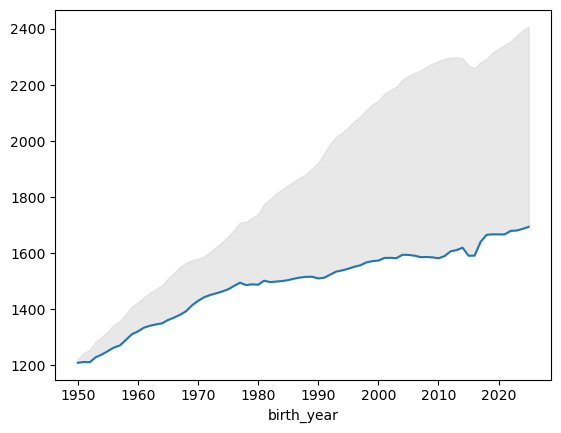

In [21]:
fig, ax = plt.subplots()

ds_le_perregion_perrun_mmm['median_strj'].sel(GMT=1.5,region=5).to_pandas().T.plot(ax=ax)

lqntl=ds_le_perregion_perrun_mmm['lqntl_strj'].sel(GMT=1.5,region=5).to_pandas().T
uqntl=ds_le_perregion_perrun_mmm['uqntl_strj'].sel(GMT=1.5,region=5).to_pandas().T

ax.fill_between(
    ds_le_perregion_perrun_mmm.birth_year,  # or whatever your x-dimension is
    lqntl,
    uqntl,
    color='lightgray',
    alpha=0.5,
    label='Uncertainty range'
)


# only 2 simulations thats why it looks so funky ! 

Text(0, 0.5, 'lifetime exposure 2025 birth year (days)')

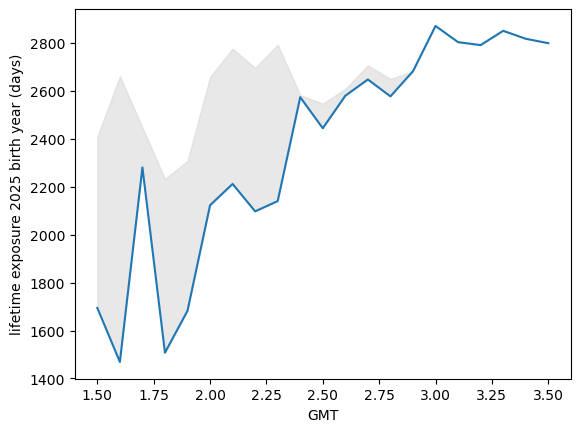

In [22]:
fig, ax = plt.subplots()

ds_le_perregion_perrun_mmm['median_strj'].sel(birth_year=2025,region=5).to_pandas().T.plot(ax=ax)

lqntl=ds_le_perregion_perrun_mmm['lqntl_strj'].sel(birth_year=2025,region=5).to_pandas().T
uqntl=ds_le_perregion_perrun_mmm['uqntl_strj'].sel(birth_year=2025,region=5).to_pandas().T

ax.fill_between(
    ds_le_perregion_perrun_mmm.GMT,  # or whatever your x-dimension is
    lqntl,
    uqntl,
    color='lightgray',
    alpha=0.5,
    label='Uncertainty range'
)

plt.ylabel('lifetime exposure 2025 birth year (days)')

Text(0.5, 1.0, 'All countries')

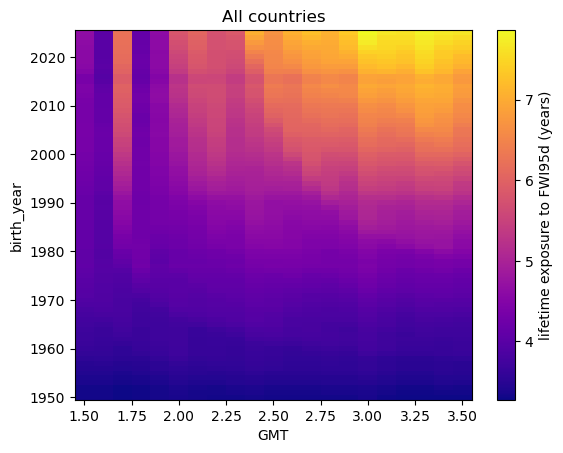

In [53]:
(ds_le_perregion_perrun_mmm['median_strj']/365).sel(region=5).plot(
    cbar_kwargs={'label': 'lifetime exposure to FWI95d (years)'},
    cmap='plasma'
    )

plt.title('All countries')

In [29]:
ds_le_perregion_perrun_mmm

<xarray.Dataset>
Dimensions:                   (run: 2, region: 6, birth_year: 76, GMT: 21)
Coordinates:
  * run                       (run) int64 1 2
  * region                    (region) int64 0 1 2 3 4 5
  * birth_year                (birth_year) int64 1950 1951 1952 ... 2024 2025
  * GMT                       (GMT) float64 1.5 1.6 1.7 1.8 ... 3.2 3.3 3.4 3.5
Data variables: (12/67)
    le_perregion_perrun_RCP   (run, region, birth_year) float64 1.407e+03 ......
    le_perregion_perrun_15    (run, region, birth_year) float64 1.293e+03 ......
    le_perregion_perrun_20    (run, region, birth_year) float64 1.261e+03 ......
    le_perregion_perrun_NDC   (run, region, birth_year) float64 1.275e+03 ......
    le_perregion_perrun_OS    (run, region, birth_year) float64 1.236e+03 ......
    le_perregion_perrun_noOS  (run, region, birth_year) float64 1.23e+03 ... ...
    ...                        ...
    median_strj               (region, birth_year, GMT) float64 1.228e+03 ......
    sample_size_strj          (GMT) int64 2 2 2 2 2 2 2 2 2 ... 2 1 1 1 1 1 1 1
    mmm_EMF_strj              (region, birth_year, GMT) float64 1.0 ... 2.337
    lqntl_EMF_strj            (region, birth_year, GMT) float64 1.0 ... 2.337
    uqntl_EMF_strj            (region, birth_year, GMT) float64 1.0 ... 2.337
    median_EMF_strj           (region, birth_year, GMT) float64 1.0 ... 2.337

In [ ]:
# df = df_life_expectancy_perregion
# da_life_expectancy_perregion = xr.DataArray(
#     df.values.astype(float),
#     dims=['birth_year', 'region'],
#     coords={'birth_year': df.index, 'region': np.arange(len(df.columns))}
# )
# da_life_expectancy_perregion

# # now done in fxn 

<xarray.DataArray (birth_year: 76, region: 6)>
array([[76.61807719, 61.9151805 , 72.44118649, 77.03705035, 61.7010587 ,
        75.53858311],
       [76.92733115, 61.97515472, 72.54578746, 77.37449336, 62.04513287,
        75.76384752],
       [76.86646561, 62.14903549, 72.44936076, 77.33227748, 62.44093413,
        75.69304264],
       [77.51110126, 62.3624954 , 72.44191157, 78.13706776, 62.79413502,
        76.27407564],
       [77.57529776, 62.52075678, 72.85575553, 78.08768229, 63.14860478,
        76.32251514],
       [77.82389571, 62.14923403, 73.09490942, 78.313804  , 62.41568742,
        76.49597477],
       [78.02808589, 62.77433519, 73.36456848, 78.49811915, 63.67245353,
        76.70989302],
       [77.88232943, 62.59707342, 73.37266663, 78.27582278, 64.22117888,
        76.54449276],
       [78.05189525, 64.46762763, 74.21838378, 78.42921072, 64.58799425,
        76.84337995],
       [78.40994746, 64.64148705, 74.33554581, 78.8432423 , 64.9619553 ,
        77.16080507],
...
       [83.28350486, 82.16125431, 81.55581017, 84.06769832, 80.4866712 ,
        83.06843617],
       [84.47982262, 83.59112655, 83.13321367, 85.05652424, 82.57787241,
        84.30668331],
       [85.13510911, 83.4708388 , 83.12370886, 85.83771581, 82.77575423,
        84.80325909],
       [85.40339558, 83.67394954, 83.42337666, 86.07193457, 82.94080756,
        85.0531312 ],
       [85.62955946, 83.92145485, 83.72528174, 86.26595321, 83.08419497,
        85.27879869],
       [85.88353648, 84.17339009, 84.08376964, 86.46075921, 83.21674404,
        85.53329442],
       [86.12726379, 84.3290733 , 84.29669056, 86.66897575, 83.3489658 ,
        85.75570276],
       [86.31266236, 84.47251902, 84.50262613, 86.82860327, 83.49359043,
        85.92558329],
       [86.4613638 , 84.62158568, 84.64448132, 86.99144979, 83.63529511,
        86.075118  ],
       [86.62379769, 84.77002824, 84.77358692, 87.17487765, 83.77640338,
        86.23752678]])
Coordinates:
  * birth_year  (birth_year) int64 1950 1951 1952 1953 ... 2022 2023 2024 2025
  * region      (region) int64 0 1 2 3 4 5

Text(0.5, 1.0, 'All countries')

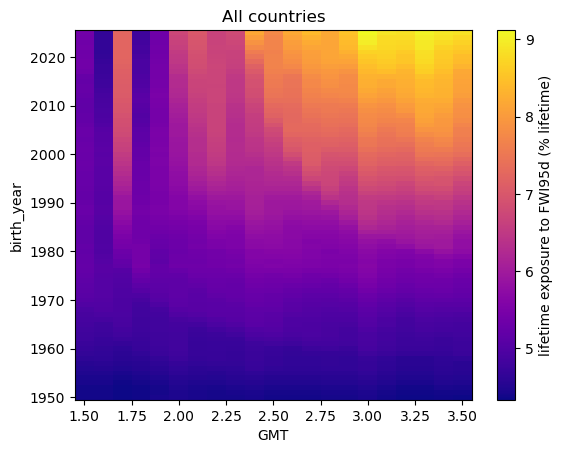

In [ ]:
(((ds_le_perregion_perrun_mmm['median_strj']/365) / da_life_expectancy_perregion)*100).sel(region=5).plot(
    _kwargs={'labcbarel': 'lifetime exposure to FWI95d (% lifetime)'},
    cmap='plasma'
    )
plt.title('All countries')

# % lifetime exposed = lifetime exposure (in years) / life expectancy (in years)

### test speed improvements - skip for now

heaviest part is conversion to df - see if there is a different way I can do this!



#### a) make masking faster - skip it

Not working - skip it ! 

In [ ]:
countries_mask

<xarray.DataArray 'mask' (lat: 391, lon: 499)>
array([[nan, nan, nan, ..., nan, 93., 93.],
       [nan, nan, nan, ..., nan, nan, 93.],
       [nan, nan, nan, ..., nan, nan, 93.],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]])
Coordinates:
  * lat      (lat) float64 32.05 32.15 32.25 32.35 ... 70.75 70.85 70.95 71.05
  * lon      (lon) float64 -14.95 -14.85 -14.75 -14.65 ... 34.65 34.75 34.85
Attributes:
    standard_name:  region
    flag_values:    [  3   4  11  14  18  21  22  33  47  48  49  52  54  58 ...
    flag_meanings:  ALB AND AUT BEL BGR BIH BLR CHE CYP CZE DEU DNK DZA ESP E...

In [99]:
def calc_weighted_fldmean_allcountries (da, countries_mask, weights=None, areaweighted=False):
    """
    Compute weighted mean of `da` for each unique value in `countries_mask`.
    Returns a DataArray with a new 'country' coordinate.
    """
    lat_name = next((n for n in ['lat','latitude'] if n in da.coords), None)
    lon_name = next((n for n in ['lon','longitude'] if n in da.coords), None)
    if lat_name is None:
        raise RuntimeError("Couldn't find a latitude coordinate")

    da = da.interp_like(countries_mask, method='linear')
    da = da.reset_coords(drop=True)

    if weights is not None and "time" in weights.dims:
        weights = weights.sel(time=da.time)

    if weights is None and areaweighted:
        vals = np.cos(np.deg2rad(da[lat_name]))
        weights = xr.DataArray(vals, coords={lat_name: da[lat_name]}, dims=[lat_name])
    

    # group by mask and compute weighted mean per country
    other_dims = set(da.groupby(countries_mask).dims) - {'time'}
    result = da.groupby(countries_mask).apply(
        lambda x: x.weighted(weights).mean(other_dims, skipna=True)
    )

    return result



# def calc_weighted_fldmean(
#     da,
#     countries_mask,
#     ind_country=None,
#     weights=None,
#     areaweighted=False
# ):
#     """
#     Compute (optionally population-weighted) field mean of `da` for a country or subset of countries.
#     If `ind_country=None`, computes the mean for all countries (vectorized via groupby).
#     """

#     # Get latitude name
#     lat_name = next((n for n in ['lat', 'latitude'] if n in da.coords), None)
#     if lat_name is None:
#         raise RuntimeError("Couldn't find a latitude coordinate")

#     # Prepare weights
#     if weights is not None and "time" in weights.dims:
#         weights = weights.sel(time=da.time)
#     elif weights is None and areaweighted:
#         weights = np.cos(np.deg2rad(da[lat_name]))

#     # ---- Subset  ----
#     if ind_country is not None:
#         if np.isscalar(ind_country):
#             mask = countries_mask == ind_country
#         else:
#             mask = countries_mask.isin(ind_country)

#         da_masked = da.where(mask)
#         if weights is not None:
#             weights = weights.where(mask)

#         other_dims = set(da.dims) - {'time'}
#         result = da_masked.weighted(weights).mean(other_dims, skipna=True).reset_coords(drop=True)
#         return result

#     # ---- All-countries ----
#     other_dims = set(da.dims) - {'time'}
#     result = (
#         da.weighted(weights)
#         .mean(other_dims, skipna=True)
#         .groupby(countries_mask)
#         .mean(skipna=True)
#     )
#     return result


In [100]:
test = calc_weighted_fldmean_allcountries(da_AFA, countries_mask, weights=None, areaweighted=True)

# groupby and weighted dont work well togehter ! and lambda doesnt seem to wrok ither 

ValueError: cannot re-index or align objects with conflicting indexes found for the following coordinates: 'lat' (2 conflicting indexes)
Conflicting indexes may occur when
- they relate to different sets of coordinate and/or dimension names
- they don't have the same type
- they may be used to reindex data along common dimensions

In [101]:
i=1

scenario = d_climate_data_meta[i]['scenario']
model = d_climate_data_meta[i]['model']
extreme = d_climate_data_meta[i]['extreme']

da_AFA = load_climate_data_array(climatedata_dir,
            scenario,
            model,
            extreme,
            year_start=1950,
            year_end=2119,
            bbox=bbox_europe
            )

da_AFA = da_AFA.interp_like(countries_mask, method='linear')

Loading /vscmnt/brussel_pixiu_data/_data_brussel/vo/000/bvo00012/vsc10419/fwi-portugal/data/preprocessed/FWI/historical/ACCESS-CM2/FWI_ACCESS-CM2_1950_2014_FWI95d.nc
Loading /vscmnt/brussel_pixiu_data/_data_brussel/vo/000/bvo00012/vsc10419/fwi-portugal/data/preprocessed/FWI/ssp126/ACCESS-CM2/FWI_ACCESS-CM2_2015_2100_FWI95d.nc
load_climate_data_array took 0.36 s


In [102]:
da.groupby(countries_mask).apply(
        lambda x: x.weighted(weights).mean(other_dims, skipna=True)
    )

ValueError: cannot re-index or align objects with conflicting indexes found for the following coordinates: 'lat' (2 conflicting indexes)
Conflicting indexes may occur when
- they relate to different sets of coordinate and/or dimension names
- they don't have the same type
- they may be used to reindex data along common dimensions

In [105]:
(da.lat == weights.lat).sum()

<xarray.DataArray 'lat' ()>
array(391)
Coordinates:
    quantile  float64 0.95

In [107]:
(da.lat == countries_mask.lat ).sum()

<xarray.DataArray 'lat' ()>
array(391)
Coordinates:
    quantile  float64 0.95

In [ ]:
other_dims = set(da_AFA.groupby(countries_mask).dims) - {'time'}
other_dims

{'stacked_lat_lon'}

In [ ]:
da = da_AFA
lat_name = 'lat'
vals = np.cos(np.deg2rad(da[lat_name]))
lat = da[lat_name]
weights = xr.DataArray(vals, coords={lat_name: lat}, dims=[lat_name])
weights

<xarray.DataArray 'lat' (lat: 391)>
array([0.84758533, 0.84665787, 0.84572782, 0.8447952 , 0.84386001,
       0.84292224, 0.84198191, 0.84103901, 0.84009355, 0.83914554,
       0.83819496, 0.83724183, 0.83628616, 0.83532793, 0.83436716,
       0.83340385, 0.832438  , 0.83146961, 0.83049869, 0.82952524,
       0.82854927, 0.82757077, 0.82658975, 0.82560621, 0.82462016,
       0.82363159, 0.82264052, 0.82164694, 0.82065085, 0.81965227,
       0.81865119, 0.81764762, 0.81664156, 0.815633  , 0.81462197,
       0.81360845, 0.81259245, 0.81157398, 0.81055304, 0.80952963,
       0.80850375, 0.80747541, 0.8064446 , 0.80541135, 0.80437564,
       0.80333747, 0.80229687, 0.80125381, 0.80020832, 0.79916039,
       0.79811002, 0.79705723, 0.796002  , 0.79494435, 0.79388428,
       0.79282179, 0.79175689, 0.79068957, 0.78961985, 0.78854772,
       0.78747319, 0.78639626, 0.78531693, 0.78423521, 0.78315111,
       0.78206461, 0.78097574, 0.77988448, 0.77879085, 0.77769485,
       0.77659648, 0.77549574, 0.77439264, 0.77328719, 0.77217937,
       0.77106921, 0.76995669, 0.76884183, 0.76772463, 0.76660509,
       0.76548321, 0.76435901, 0.76323247, 0.76210361, 0.76097243,
       0.75983893, 0.75870311, 0.75756498, 0.75642455, 0.75528181,
       0.75413677, 0.75298944, 0.75183981, 0.75068789, 0.74953368,
       0.74837719, 0.74721842, 0.74605738, 0.74489406, 0.74372847,
...
       0.47639167, 0.47485639, 0.47331967, 0.4717815 , 0.4702419 ,
       0.46870087, 0.46715841, 0.46561452, 0.46406922, 0.4625225 ,
       0.46097437, 0.45942484, 0.45787392, 0.45632159, 0.45476788,
       0.45321278, 0.4516563 , 0.45009844, 0.44853921, 0.44697862,
       0.44541667, 0.44385335, 0.44228869, 0.44072268, 0.43915533,
       0.43758663, 0.43601661, 0.43444526, 0.43287258, 0.43129859,
       0.42972328, 0.42814666, 0.42656874, 0.42498952, 0.423409  ,
       0.4218272 , 0.42024411, 0.41865974, 0.41707409, 0.41548718,
       0.41389899, 0.41230955, 0.41071885, 0.4091269 , 0.40753371,
       0.40593927, 0.4043436 , 0.40274669, 0.40114856, 0.3995492 ,
       0.39794863, 0.39634685, 0.39474386, 0.39313966, 0.39153427,
       0.38992769, 0.38831992, 0.38671096, 0.38510083, 0.38348952,
       0.38187705, 0.38026341, 0.37864862, 0.37703267, 0.37541557,
       0.37379733, 0.37217795, 0.37055744, 0.3689358 , 0.36731303,
       0.36568914, 0.36406415, 0.36243804, 0.36081083, 0.35918252,
       0.35755311, 0.35592262, 0.35429104, 0.35265838, 0.35102465,
       0.34938985, 0.34775398, 0.34611706, 0.34447908, 0.34284005,
       0.34119998, 0.33955886, 0.33791672, 0.33627354, 0.33462934,
       0.33298412, 0.33133789, 0.32969065, 0.3280424 , 0.32639315,
       0.32474291])
Coordinates:
  * lat      (lat) float64 32.05 32.15 32.25 32.35 ... 70.75 70.85 70.95 71.05
Attributes:
    units:      degrees_north
    long_name:  latitude

In [ ]:
da_AFA

In [ ]:
da_AFA * weights

<xarray.DataArray (time: 170, lat: 391, lon: 499)>
dask.array<mul, shape=(170, 391, 499), dtype=float64, chunksize=(86, 391, 499), chunktype=numpy.ndarray>
Coordinates:
    quantile  float64 0.95
  * time      (time) int64 1950 1951 1952 1953 1954 ... 2115 2116 2117 2118 2119
  * lon       (lon) float64 -14.95 -14.85 -14.75 -14.65 ... 34.65 34.75 34.85
  * lat       (lat) float64 32.05 32.15 32.25 32.35 ... 70.75 70.85 70.95 71.05

In [ ]:
da_AFA.groupby(countries_mask).mean(set(da_AFA.groupby(countries_mask).dims) - {'time'})

<xarray.DataArray 'FWI95d' (time: 170, mask: 52)>
dask.array<transpose, shape=(170, 52), dtype=float64, chunksize=(86, 1), chunktype=numpy.ndarray>
Coordinates:
    quantile  float64 0.95
  * time      (time) int64 1950 1951 1952 1953 1954 ... 2115 2116 2117 2118 2119
  * mask      (mask) float64 3.0 4.0 11.0 14.0 18.0 ... 182.0 196.0 197.0 202.0

In [98]:
da_AFA.weighted(weights).mean(set(da_AFA.dims) - {'time'})

<xarray.DataArray 'FWI95d' (time: 170)>
dask.array<truediv, shape=(170,), dtype=float64, chunksize=(86,), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) int64 1950 1951 1952 1953 1954 ... 2115 2116 2117 2118 2119

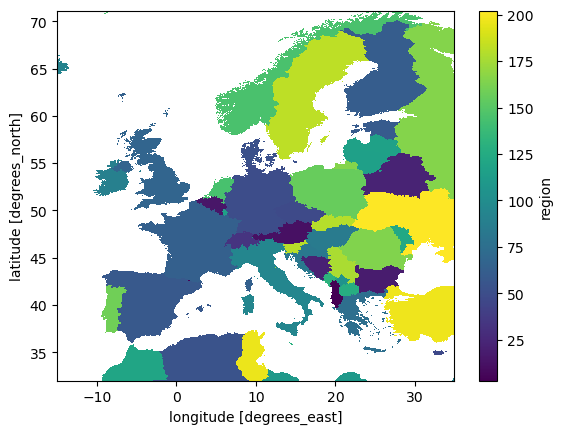

In [ ]:
countries_mask.plot()

In [87]:
da_AFA = da_AFA.reset_coords(drop=True)

In [86]:
print(da.lat)
print(countries_mask.lat)
if weights is not None:
    print(weights.lat)

<xarray.DataArray 'lat' (lat: 391)>
array([32.05, 32.15, 32.25, ..., 70.85, 70.95, 71.05])
Coordinates:
    quantile  float64 0.95
  * lat       (lat) float64 32.05 32.15 32.25 32.35 ... 70.75 70.85 70.95 71.05
Attributes:
    units:      degrees_north
    long_name:  latitude
<xarray.DataArray 'lat' (lat: 391)>
array([32.05, 32.15, 32.25, ..., 70.85, 70.95, 71.05])
Coordinates:
  * lat      (lat) float64 32.05 32.15 32.25 32.35 ... 70.75 70.85 70.95 71.05
Attributes:
    units:      degrees_north
    long_name:  latitude
<xarray.DataArray 'lat' (lat: 391)>
array([32.05, 32.15, 32.25, ..., 70.85, 70.95, 71.05])
Coordinates:
  * lat      (lat) float64 32.05 32.15 32.25 32.35 ... 70.75 70.85 70.95 71.05
Attributes:
    units:      degrees_north
    long_name:  latitude


In [ ]:
print(da_AFA.dims)
print(countries_mask.dims)

('time', 'lat', 'lon')
('lat', 'lon')


In [ ]:
da_AFA

<xarray.DataArray 'FWI95d' (time: 170, lat: 391, lon: 499)>
dask.array<concatenate, shape=(170, 391, 499), dtype=float64, chunksize=(86, 391, 499), chunktype=numpy.ndarray>
Coordinates:
  * lon       (lon) float64 -14.86 -14.76 -14.66 -14.56 ... 34.74 34.84 34.94
  * lat       (lat) float64 70.99 70.89 70.79 70.69 ... 32.29 32.19 32.09 31.99
    quantile  float64 0.95
  * time      (time) int64 1950 1951 1952 1953 1954 ... 2115 2116 2117 2118 2119

#### b) make looping / country average faster - skip it

In [8]:
i=1

scenario = d_climate_data_meta[i]['scenario']
model = d_climate_data_meta[i]['model']
extreme = d_climate_data_meta[i]['extreme']

da_AFA = load_climate_data_array(climatedata_dir,
            scenario,
            model,
            extreme,
            year_start=1950,
            year_end=2119,
            bbox=bbox_europe
            )

da_AFA = da_AFA.interp_like(countries_mask, method='linear')

Loading /vscmnt/brussel_pixiu_data/_data_brussel/vo/000/bvo00012/vsc10419/fwi-portugal/data/preprocessed/FWI/historical/ACCESS-CM2/FWI_ACCESS-CM2_1950_2014_FWI95d.nc
Loading /vscmnt/brussel_pixiu_data/_data_brussel/vo/000/bvo00012/vsc10419/fwi-portugal/data/preprocessed/FWI/ssp126/ACCESS-CM2/FWI_ACCESS-CM2_2015_2100_FWI95d.nc
load_climate_data_array took 0.13 s


In [9]:
year_range = np.arange(1950, 2119+1)

In [10]:
d_exposure_percountry = {}

countries = df_countries['name']

# get spatial average per country
for j, country in enumerate(countries[0:20]): 

    print(f'Computing lifetime exposure (LE) in {country}                              ', end='\r')

    # calculate mean per country weighted by population
    ind_country = countries_regions.map_keys(country)

    # historical + RCP simulations
    d_exposure_percountry[country] = calc_weighted_fldmean( 
        da_AFA,
        countries_mask, 
        ind_country,
        weights=da_population, 
        areaweighted=False
    )

print(f'Converting to dataframe                              ', end='\r')
                
# Convert dict to dataframe for vectorizing and integrate exposures   - I think this step is slow? 
# avg population-weighted exposure per country per year
frame = {k:v.values for k,v in d_exposure_percountry.items()}
df_exposure_percountry = pd.DataFrame(frame,index=year_range)  

In [11]:
da_AFA

<xarray.DataArray 'FWI95d' (time: 170, lat: 391, lon: 499)>
dask.array<transpose, shape=(170, 391, 499), dtype=float64, chunksize=(86, 391, 499), chunktype=numpy.ndarray>
Coordinates:
    quantile  float64 0.95
  * time      (time) int64 1950 1951 1952 1953 1954 ... 2115 2116 2117 2118 2119
  * lon       (lon) float64 -14.95 -14.85 -14.75 -14.65 ... 34.65 34.75 34.85
  * lat       (lat) float64 32.05 32.15 32.25 32.35 ... 70.75 70.85 70.95 71.05

In [ ]:
df_exposure_percountry

,Albania,Algeria,Andorra,Austria,Belarus,Belgium,Bosnia and Herzegovina,Bulgaria,Croatia,Cyprus,Czechia,Denmark,Estonia,Faroe Islands,Finland,France,Germany,Greece,Hungary,Iceland
1950,11.352423,11.224884,20.891314,21.621512,2.278174,44.830380,18.990801,21.625293,13.575774,7.524654,18.233699,19.899809,7.798804,7.550608,5.094148,42.895192,33.697780,5.852926,28.196372,31.082183
1951,36.144792,23.386079,25.346171,16.145098,2.945636,42.217847,33.480853,30.742511,20.354214,6.233431,20.984846,1.581607,0.597525,5.210723,0.511523,31.753821,19.829435,18.591201,32.283402,26.222122
1952,44.999491,20.276023,29.567968,40.794360,30.789894,53.312431,49.469566,47.823357,40.814478,19.028188,52.520074,5.888744,14.961219,4.358066,2.697322,32.526192,34.136903,24.968540,65.350343,4.013890
1953,8.300471,20.129542,1.583989,31.725770,12.280133,34.400394,28.449228,28.515373,25.383413,15.862069,20.693297,9.127569,18.177305,6.979828,15.189064,17.661902,21.675909,10.521980,24.583329,13.074440
1954,41.327480,31.634952,44.648972,19.900028,3.664749,19.661180,35.626552,28.473927,27.155247,24.693760,16.889385,12.704728,4.806062,13.102536,5.723653,19.741961,16.669494,27.074156,18.883627,27.172216
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2115,46.075236,33.189376,41.673264,39.987194,26.121647,49.199067,38.731849,41.409703,35.069595,21.794804,35.324103,30.021064,30.959038,8.310096,33.396824,47.056784,37.521325,32.656135,44.708823,22.770406
2116,46.075236,33.189376,41.673264,39.987194,26.121647,49.199067,38.731849,41.409703,35.069595,21.794804,35.324103,30.021064,30.959038,8.310096,33.396824,47.056784,37.521325,32.656135,44.708823,22.770406
2117,46.075236,33.189376,41.673264,39.987194,26.121647,49.199067,38.731849,41.409703,35.069595,21.794804,35.324103,30.021064,30.959038,8.310096,33.396824,47.056784,37.521325,32.656135,44.708823,22.770406
2118,46.075236,33.189376,41.673264,39.987194,26.121647,49.199067,38.731849,41.409703,35.069595,21.794804,35.324103,30.021064,30.959038,8.310096,33.396824,47.056784,37.521325,32.656135,44.708823,22.770406


: 

In [ ]:
countries = df_countries['name'][0:20]

# compute all countries
results = [
    calc_weighted_fldmean(
        da_AFA, countries_mask, countries_regions.map_keys(country),
        weights=da_population, areaweighted=False
    )
    for country in countries
]

df_exposure_percountry = xr.concat(results, dim="country").to_pandas().T
df_exposure_percountry.columns = countries 

In [ ]:
results[0].values

array([nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan])

In [ ]:
df_exposure_percountry

In [ ]:
region_names = np.concatenate([df_countries['region'].dropna().unique(),
                        df_countries['incomegroup'].dropna().unique(),
                        ['World'] # if using a bbox this is all countries in the bbox - rename to all_countries? 
])


In [21]:
# compute all countries
results = [
    calc_weighted_fldmean(
        da_AFA, 
        countries_mask, 
        countries_regions.map_keys(get_countries_of_region(region, df_countries)),
        weights=da_population, areaweighted=False
    )
    for region in region_names
]

df_exposure_perregion = xr.concat(results, dim="region").to_pandas().T
df_exposure_perregion.columns = region_names  




In [22]:
df_exposure_perregion

,Europe & Central Asia,Middle East & North Africa,Upper middle income,High income,Lower middle income,World
time,,,,,,
1950,NaN,NaN,NaN,NaN,NaN,NaN
1951,NaN,NaN,NaN,NaN,NaN,NaN
1952,NaN,NaN,NaN,NaN,NaN,NaN
1953,NaN,NaN,NaN,NaN,NaN,NaN
1954,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...
2115,NaN,NaN,NaN,NaN,NaN,NaN
2116,NaN,NaN,NaN,NaN,NaN,NaN
2117,NaN,NaN,NaN,NaN,NaN,NaN


# 5) Subnational shapefiles & User defined regions : todo! 

Subnational analysis:
- make a function that opens subnational shapefile and turns it into a mask load_subnational_mask (from load_coutrymask)
- make an adapted lifetime exposure function that runs per gdf unit taking life expectancy from country-level



In [3]:

d_countries = preprocess_all_country_data(

    filepath_lifeexpectancy = filepath_lifeexpectancy, # life expectancy data
    start_birthyear=1950,
    end_birthyear=2025,                 # endyear is taken from end_birthyear + max life expectancy

    dir_cohortsizes = dir_cohortsizes,  # cohort size data
    data_source_cohorts='UNWPP2024',
    extend_method='linear',             # note, 'slinear' not implemented for UNWPP2024
    by_sex=False,                       # NOTE by_sex not implemented
                                            
    dir_population= dir_population,     # gridded pop data 
    ssp=2,
    urbanrural=False,                   # NOTE urbanrural not implemented for v2
    bbox = bbox_europe,                        # could use bbox europe!!

    filepath_countrymask = filepath_countrymask,    # country masks 
    data_source_countrymask = 'shapefile',
    fillcoast=False, 
    fix_smallislands=False,
    
    filepath_world_bank = filepath_world_bank_meta, # metadata 
    filepath_lookuptable = filepath_lookuptable,    # country filtering
    filter_countries=True,
    worldbank_filter=True, 
    )

load_country_metadata took 0.06 s
load_unwpp_lifeexpectancy took 27.59 s
get_life_expectancies took 0.00 s
loading cohort sizes from UNWPP2024
load_cohort_sizes took 25.08 s
interpolate_cohortsize_countries took 0.01 s
opening compass - historical
opening compass - ssp2
load_population took 3.76 s
load_countrymask took 3.51 s
preprocess_all_country_data took 60.05 s


In [4]:
df_countries = d_countries['info_pop'] # added ISO2 to match the countries from shapefile with other data 
gdf_country_borders = d_countries['borders'] 
da_regions = df_countries['region'].unique()
da_population = d_countries['population_map']
df_birthyears = d_countries['birth_years'] # NA
df_life_expectancy_5 = d_countries['life_expectancy_5']
da_cohort_size = d_countries['cohort_size']
countries_regions, countries_mask = d_countries['mask'] 

In [18]:
df_countries

,abbreviation,ISO2,region,incomegroup,country_code,SSP name,name,population
name,,,,,,,,
Albania,ALB,AL,Europe & Central Asia,Upper middle income,8,Albania,Albania,2.673239e+06
Algeria,DZA,DZ,Middle East & North Africa,Upper middle income,12,Algeria,Algeria,4.379287e+07
Andorra,AND,AD,Europe & Central Asia,High income,20,Andorra,Andorra,7.272074e+04
Austria,AUT,AT,Europe & Central Asia,High income,40,Austria,Austria,9.163680e+06
Belarus,BLR,BY,Europe & Central Asia,Upper middle income,112,Belarus,Belarus,9.047398e+06
...,...,...,...,...,...,...,...,...
Switzerland,CHE,CH,Europe & Central Asia,High income,756,Switzerland,Switzerland,8.980174e+06
Tunisia,TUN,TN,Middle East & North Africa,Lower middle income,788,Tunisia,Tunisia,1.127533e+07
Türkiye,TUR,TR,Europe & Central Asia,Upper middle income,792,Turkey,Türkiye,5.268500e+07


In [5]:
countries_regions

<regionmask.Regions 'country'>
overlap:  None

Regions:
  3 ALB  Albania
  4 AND  Andorra
 11 AUT  Austria
 14 BEL  Belgium
 18 BGR Bulgaria
 ..  ..      ...
181 SVN Slovenia
182 SWE   Sweden
196 TUN  Tunisia
197 TUR  Türkiye
202 UKR  Ukraine

[54 regions]

In [6]:
countries_mask

<xarray.DataArray 'mask' (lat: 391, lon: 499)>
array([[nan, nan, nan, ..., nan, 93., 93.],
       [nan, nan, nan, ..., nan, nan, 93.],
       [nan, nan, nan, ..., nan, nan, 93.],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]])
Coordinates:
  * lat      (lat) float64 32.05 32.15 32.25 32.35 ... 70.75 70.85 70.95 71.05
  * lon      (lon) float64 -14.95 -14.85 -14.75 -14.65 ... 34.65 34.75 34.85
Attributes:
    standard_name:  region
    flag_values:    [  3   4  11  14  18  21  22  33  47  48  49  52  54  58 ...
    flag_meanings:  ALB AND AUT BEL BGR BIH BLR CHE CYP CZE DEU DNK DZA ESP E...

In [7]:
gdf_country_borders

,geometry,region,abbreviation
name,,,
Albania,"POLYGON ((19.74601 42.57993, 19.74136 42.57441...",Europe & Central Asia,ALB
Algeria,"POLYGON ((8.60566 36.91305, 8.60483 36.90098, ...",Middle East & North Africa,DZA
Andorra,"POLYGON ((1.69750 42.49446, 1.68634 42.49061, ...",Europe & Central Asia,AND
Austria,"POLYGON ((15.23807 48.95076, 15.24323 48.95293...",Europe & Central Asia,AUT
Belarus,"POLYGON ((28.16911 56.12526, 28.23846 56.08262...",Europe & Central Asia,BLR
...,...,...,...
Switzerland,"POLYGON ((8.62984 47.76280, 8.63501 47.78460, ...",Europe & Central Asia,CHE
Tunisia,"MULTIPOLYGON (((10.95973 33.86612, 10.99147 33...",Middle East & North Africa,TUN
Türkiye,"MULTIPOLYGON (((26.04623 39.84406, 26.05112 39...",Europe & Central Asia,TUR


In [8]:
df_countries

,abbreviation,ISO2,region,incomegroup,country_code,SSP name,name,population
name,,,,,,,,
Albania,ALB,AL,Europe & Central Asia,Upper middle income,8,Albania,Albania,2.673239e+06
Algeria,DZA,DZ,Middle East & North Africa,Upper middle income,12,Algeria,Algeria,4.379287e+07
Andorra,AND,AD,Europe & Central Asia,High income,20,Andorra,Andorra,7.272074e+04
Austria,AUT,AT,Europe & Central Asia,High income,40,Austria,Austria,9.163680e+06
Belarus,BLR,BY,Europe & Central Asia,Upper middle income,112,Belarus,Belarus,9.047398e+06
...,...,...,...,...,...,...,...,...
Switzerland,CHE,CH,Europe & Central Asia,High income,756,Switzerland,Switzerland,8.980174e+06
Tunisia,TUN,TN,Middle East & North Africa,Lower middle income,788,Tunisia,Tunisia,1.127533e+07
Türkiye,TUR,TR,Europe & Central Asia,Upper middle income,792,Turkey,Türkiye,5.268500e+07


In [9]:
df_life_expectancy_5

Country,Albania,Algeria,Andorra,Austria,Belarus,Belgium,Bosnia and Herzegovina,Bulgaria,Croatia,Cyprus,...,Serbia,Slovakia,Slovenia,Spain,Sweden,Switzerland,Tunisia,Türkiye,Ukraine,United Kingdom
Year,,,,,,,,,,,,,,,,,,,,,
1950,72.2933,60.0833,78.4736,77.328,75.3355,77.8648,70.1355,78.4307,76.3165,72.2451,...,74.7094,77.6059,76.3769,77.7527,80.1749,78.3759,62.9397,74.215,76.4168,78.2731
1951,73.117,59.9968,78.7848,77.2763,75.7719,78.0135,70.4649,77.6914,76.5287,72.5645,...,75.0297,77.7876,76.4921,77.2738,80.219,78.4089,63.4908,74.3061,76.7791,78.4502
1952,74.0791,59.8907,79.0685,77.0455,76.1716,78.1412,71.15,78.6301,76.8597,72.8389,...,75.8287,77.2865,76.5532,77.2174,80.0601,78.6051,64.2125,73.4723,77.1535,78.5535
1953,75.0774,59.7686,79.449,77.7793,76.8768,78.4919,71.7558,79.5434,77.093,73.1858,...,76.5709,78.4581,76.8142,78.9503,80.5827,79.2188,64.7408,72.9428,77.3328,78.6526
1954,75.9208,59.6571,79.7661,77.7012,77.8036,78.8723,72.8119,77.5044,77.2357,73.5729,...,77.1057,77.8273,77.0635,78.8173,80.8428,79.4077,65.2574,73.5414,77.8302,78.7528
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021,86.7605,84.3678,90.9386,88.7147,81.1799,88.8552,84.8188,82.5465,85.3918,88.3808,...,83.6672,85.1695,88.2295,90.3076,89.9191,90.6576,83.9189,85.1218,81.44,88.0767
2022,86.923,84.5161,91.0655,88.8823,81.3517,88.9993,84.9906,82.6858,85.5442,88.5442,...,83.8383,85.3294,88.3943,90.4504,90.0557,90.7919,84.0811,85.2946,81.5875,88.2177
2023,87.0848,84.6631,91.1889,89.044,81.5236,89.1554,85.1543,82.8324,85.7104,88.712,...,84.0101,85.4824,88.5423,90.5779,90.1884,90.9169,84.2544,85.4623,81.7357,88.3511


In [9]:
filepath_shp = glob.glob(os.path.join(os.environ['VSC_DATA_VO_USER'], 'fwi-portugal/data/shapefiles/eurostat/NUTS_RG_01M_2016/NUTS_RG_*.shp'))[0]


gdf = gpd.read_file(filepath_shp)
gdf


,LEVL_CODE,NUTS_ID,CNTR_CODE,NAME_LATN,NUTS_NAME,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,geometry
0,0,AL,AL,SHQIPËRIA,SHQIPËRIA,0,0,0,"MULTIPOLYGON (((5121233.536 2221719.441, 51208..."
1,0,CZ,CZ,ČESKÁ REPUBLIKA,ČESKÁ REPUBLIKA,0,0,0,"POLYGON ((4624843.654 3112209.741, 4625546.618..."
2,0,DE,DE,DEUTSCHLAND,DEUTSCHLAND,0,0,0,"MULTIPOLYGON (((4355225.365 2715902.993, 43541..."
3,0,DK,DK,DANMARK,DANMARK,0,0,0,"MULTIPOLYGON (((4650502.736 3591342.844, 46503..."
4,0,CY,CY,KYPROS,ΚΥΠΡΟΣ,0,0,0,"MULTIPOLYGON (((6527040.718 1762367.593, 65267..."
...,...,...,...,...,...,...,...,...,...
2011,2,TR32,TR,"Aydin, Denizli, Mugla","Aydin, Denizli, Mugla",0,0,0,"MULTIPOLYGON (((6059439.350 1918107.697, 60631..."
2012,3,UKJ44,UK,East Kent,East Kent,4,1,1,"POLYGON ((3725746.948 3177497.838, 3726364.317..."
2013,3,UKJ45,UK,Mid Kent,Mid Kent,4,2,2,"POLYGON ((3665924.909 3178606.710, 3666063.805..."
2014,3,UKL15,UK,Central Valleys,Central Valleys,3,1,2,"POLYGON ((3402649.355 3274752.703, 3402835.023..."


<Axes: >

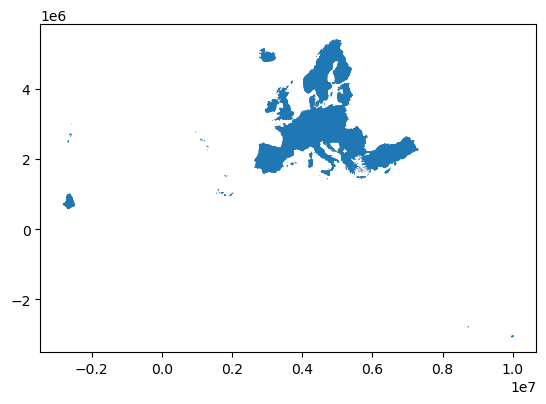

In [10]:
gdf.plot()

In [11]:
def make_shp(filepath_shp, dict_keep=None, dict_drop=None):
    shp = gpd.read_file(filepath_shp)

    if dict_keep:
        for key, val in dict_keep.items():
            vals = [val] if isinstance(val, (str, int)) else val
            shp = shp[shp[key].isin(vals)]

    if dict_drop:
        for key, val in dict_drop.items():
            vals = [val] if isinstance(val, (str, int)) else val
            shp = shp[~shp[key].str.startswith(tuple(vals))]

    return shp.reset_index(drop=True)


In [12]:
dict_keep = {'LEVL_CODE': 2, 'CNTR_CODE': 'PT'}
dict_drop = {'NUTS_ID': ['PT2','PT3']}


gdf = make_shp(filepath_shp, dict_keep=dict_keep, dict_drop=dict_drop)
gdf

,LEVL_CODE,NUTS_ID,CNTR_CODE,NAME_LATN,NUTS_NAME,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,geometry
0,2,PT11,PT,Norte,Norte,0,0,0,"MULTIPOLYGON (((2828396.621 2295946.291, 28279..."
1,2,PT16,PT,Centro (PT),Centro (PT),0,0,0,"MULTIPOLYGON (((2884540.928 2154285.866, 28843..."
2,2,PT15,PT,Algarve,Algarve,0,0,0,"MULTIPOLYGON (((2771669.671 1784422.908, 27717..."
3,2,PT17,PT,Área Metropolitana de Lisboa,Área Metropolitana de Lisboa,0,0,0,"MULTIPOLYGON (((2708333.948 1946251.261, 27098..."
4,2,PT18,PT,Alentejo,Alentejo,0,0,0,"MULTIPOLYGON (((2822855.530 2014992.655, 28232..."


In [13]:
gdf.crs 

<Projected CRS: EPSG:3035>
Name: ETRS89-extended / LAEA Europe
Axis Info [cartesian]:
- Y[north]: Northing (metre)
- X[east]: Easting (metre)
Area of Use:
- name: Europe - European Union (EU) countries and candidates. Europe - onshore and offshore: Albania; Andorra; Austria; Belgium; Bosnia and Herzegovina; Bulgaria; Croatia; Cyprus; Czechia; Denmark; Estonia; Faroe Islands; Finland; France; Germany; Gibraltar; Greece; Hungary; Iceland; Ireland; Italy; Kosovo; Latvia; Liechtenstein; Lithuania; Luxembourg; Malta; Monaco; Montenegro; Netherlands; North Macedonia; Norway including Svalbard and Jan Mayen; Poland; Portugal including Madeira and Azores; Romania; San Marino; Serbia; Slovakia; Slovenia; Spain including Canary Islands; Sweden; Switzerland; Türkiye (Turkey); United Kingdom (UK) including Channel Islands and Isle of Man; Vatican City State.
- bounds: (-35.58, 24.6, 44.83, 84.73)
Coordinate Operation:
- name: Europe Equal Area 2001
- method: Lambert Azimuthal Equal Area
Datum: Eur

In [14]:
bounds = gdf.to_crs('EPSG:4326').total_bounds
latmin, latmax, lonmin, lonmax = bounds

In [15]:
gdf_country_borders

,geometry,region,abbreviation
name,,,
Albania,"POLYGON ((19.74601 42.57993, 19.74136 42.57441...",Europe & Central Asia,ALB
Algeria,"POLYGON ((8.60566 36.91305, 8.60483 36.90098, ...",Middle East & North Africa,DZA
Andorra,"POLYGON ((1.69750 42.49446, 1.68634 42.49061, ...",Europe & Central Asia,AND
Austria,"POLYGON ((15.23807 48.95076, 15.24323 48.95293...",Europe & Central Asia,AUT
Belarus,"POLYGON ((28.16911 56.12526, 28.23846 56.08262...",Europe & Central Asia,BLR
...,...,...,...
Switzerland,"POLYGON ((8.62984 47.76280, 8.63501 47.78460, ...",Europe & Central Asia,CHE
Tunisia,"MULTIPOLYGON (((10.95973 33.86612, 10.99147 33...",Middle East & North Africa,TUN
Türkiye,"MULTIPOLYGON (((26.04623 39.84406, 26.05112 39...",Europe & Central Asia,TUR


In [32]:
gdf_country_borders_raw = gpd.read_file(filepath_countrymask)

In [34]:
gdf_country_borders_raw.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [81]:
subnational_mask = subnational_regions.mask(da_population.lon, da_population.lat)
subnational_mask

<xarray.DataArray 'mask' (lat: 391, lon: 499)>
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]])
Coordinates:
  * lat      (lat) float64 32.05 32.15 32.25 32.35 ... 70.75 70.85 70.95 71.05
  * lon      (lon) float64 -14.95 -14.85 -14.75 -14.65 ... 34.65 34.75 34.85
Attributes:
    standard_name:  region
    flag_values:    [0 1 2 3 4]
    flag_meanings:  PT11 PT16 PT15 PT17 PT18

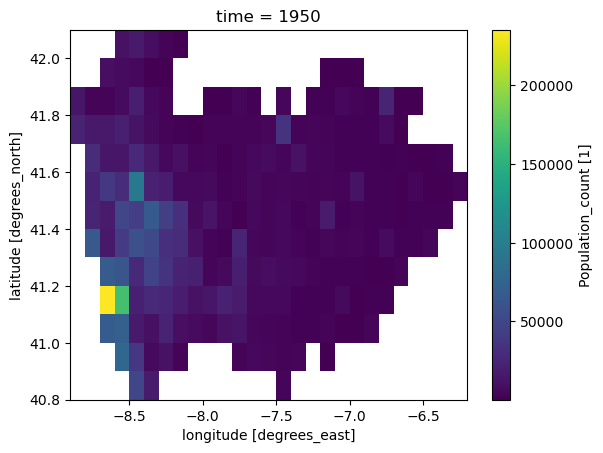

In [87]:
da_population.where(subnational_mask==subnational_regions.map_keys('PT11'), drop=True).isel(time=0).plot()

In [82]:
da_population.where(subnational_mask==subnational_regions.map_keys('PT11'), drop=True).isel(time=0).sum().values

array(2947144., dtype=float32)

In [90]:
subnational_regions.name

'NUTS_NAME'

In [83]:
subnational_regions

<regionmask.Regions 'NUTS_NAME'>
overlap:  None

Regions:
0 PT11                        Norte
1 PT16                  Centro (PT)
2 PT15                      Algarve
3 PT17 Área Metropolitana de Lisboa
4 PT18                     Alentejo

[5 regions]

In [98]:
[subnational_regions[i].abbrev for i in range(len(subnational_regions))]

['PT11', 'PT16', 'PT15', 'PT17', 'PT18']

In [100]:
gdf[gdf['NUTS_ID']=='PT11']

,LEVL_CODE,NUTS_ID,CNTR_CODE,NAME_LATN,NUTS_NAME,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,geometry
0,2,PT11,PT,Norte,Norte,0,0,0,"MULTIPOLYGON (((2828396.621 2295946.291, 28279..."


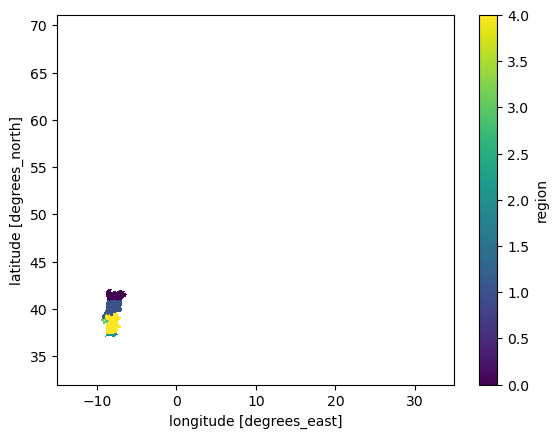

In [37]:
subnational_mask.plot()

In [117]:

@timeit
def load_subnational_mask(
    filepath_shp=None,
    da_population=None,
    bbox=None,
    dict_keep=None, 
    dict_drop=None,
    col_name="NUTS_NAME",
    col_id= "NUTS_ID",
    col_country='CNTR_CODE',
    ):
    """
    Load subnational shapefile mask 

    Inputs:
        dict_keep (dict):       what elements of shapefile to keep, as a dictionary colname:value 
                                e.g. {'LEVL_CODE': 2, 'CNTR_CODE': 'PT'}
                                This does an exact match
        dict_drop (dict):       what elements to drop as a dictionary colname:value
                                This does a "startswith" match


    Returns:


    """

    def make_shp(filepath_shp, dict_keep=None, dict_drop=None):
        shp = gpd.read_file(filepath_shp)

        if dict_keep:
            for key, val in dict_keep.items():
                vals = [val] if isinstance(val, (str, int)) else val
                shp = shp[shp[key].isin(vals)]

        if dict_drop:
            for key, val in dict_drop.items():
                vals = [val] if isinstance(val, (str, int)) else val
                shp = shp[~shp[key].str.startswith(tuple(vals))]

        return shp.reset_index(drop=True)
    
    def cut_to_region(da, bbox):
        # cut to a predefined region
        latmin, latmax, lonmin, lonmax = bbox
        if da.lat.values[0] < da.lat.values[-1]:
            da = da.sel(lat=slice(latmin, latmax), lon=slice(lonmin, lonmax))
        else:
            da = da.sel(lat=slice(latmax, latmin), lon=slice(lonmin, lonmax))
        if "country" in da.dims:
            # compute which countries have all-NaN/0 inside the bbox and drop them 
            mask = ~((da.isnull() | (da == 0)).all(dim=("lat","lon")))
            return da.sel(country=mask)
        else:
            return da
    
    gdf = make_shp(filepath_shp, dict_keep=dict_keep, dict_drop=dict_drop)

    if bbox:
        latmin, latmax, lonmin, lonmax = bbox
        # crop to same area 
        box_crop = box(lonmin, latmin, lonmax, latmax) # not sure this is necessary?
        gdf = gpd.clip(gdf, box_crop)
        da_population = cut_to_region(da_population, bbox)  # TODO: do i really need this ?? 
                                                            # it will make mask on grid of da_population, so it needs to be relevant to broader analysis
                                                            # check if better to force bbox to be provided... or to alternatively not crop da_population 


    # create regions object and mask object
    subnational_regions = regionmask.from_geopandas(
        gdf.to_crs('EPSG:4326'), 
        names=col_name, 
        abbrevs=col_id, 
        name=col_name
    )
    subnational_mask = subnational_regions.mask(da_population.lon, da_population.lat)

    gdf = gdf.loc[:,[col_id, col_country, col_name, 'geometry']].rename(
            columns={col_id:'id', col_name:'name', col_country:'country'}).set_index('id', drop=False)

    # calc population in 2025 from gridded data, to check if some regions are unresolved at the resolution
    gdf['population'] = np.nan
    for idx in gdf['id']:
        gdf.loc[idx,'population'] = da_population.sel(time=2025).where(subnational_mask==subnational_regions.map_keys(idx), drop=True).sum().values

    # possible to add automatic dropping of empty regions

    return gdf, subnational_regions, subnational_mask

In [118]:
filepath_nuts = glob.glob(os.path.join(os.environ['VSC_DATA_VO_USER'], 'fwi-portugal/data/shapefiles/eurostat/NUTS_RG_01M_2016/NUTS_RG_*.shp'))[0]


gdf_subnat, subnational_regions, subnational_mask = load_subnational_mask(
    filepath_shp = filepath_nuts,
    da_population=da_population,
    bbox=None,
    dict_keep=dict_keep, 
    dict_drop=dict_drop,
    col_name="NUTS_NAME",
    col_id= "NUTS_ID",
    col_country='CNTR_CODE',
    )

load_subnational_mask took 7.03 s


In [119]:
gdf_subnat

,id,country,name,geometry,population
id,,,,,
PT11,PT11,PT,Norte,"MULTIPOLYGON (((2828396.621 2295946.291, 28279...",3.382892e+06
PT16,PT16,PT,Centro (PT),"MULTIPOLYGON (((2884540.928 2154285.866, 28843...",2.046652e+06
PT15,PT15,PT,Algarve,"MULTIPOLYGON (((2771669.671 1784422.908, 27717...",4.102613e+05
PT17,PT17,PT,Área Metropolitana de Lisboa,"MULTIPOLYGON (((2708333.948 1946251.261, 27098...",2.917903e+06
PT18,PT18,PT,Alentejo,"MULTIPOLYGON (((2822855.530 2014992.655, 28232...",7.127856e+05


In [120]:
df_countries

,abbreviation,region,incomegroup,country_code,ISO2,SSP name,name,population
name,,,,,,,,
Albania,ALB,Europe & Central Asia,Upper middle income,8,AL,Albania,Albania,2.673239e+06
Algeria,DZA,Middle East & North Africa,Upper middle income,12,DZ,Algeria,Algeria,4.379287e+07
Andorra,AND,Europe & Central Asia,High income,20,AD,Andorra,Andorra,7.272074e+04
Austria,AUT,Europe & Central Asia,High income,40,AT,Austria,Austria,9.163680e+06
Belarus,BLR,Europe & Central Asia,Upper middle income,112,BY,Belarus,Belarus,9.047398e+06
...,...,...,...,...,...,...,...,...
Switzerland,CHE,Europe & Central Asia,High income,756,CH,Switzerland,Switzerland,8.980174e+06
Tunisia,TUN,Middle East & North Africa,Lower middle income,788,TN,Tunisia,Tunisia,1.127533e+07
Türkiye,TUR,Europe & Central Asia,Upper middle income,792,TR,Turkey,Türkiye,5.268500e+07


In [127]:
    def get_country(
        region, 
        gdf_subnational,
        df_countries
        ):

        country_code = gdf_subnational.loc[gdf_subnational['id']==region]['country'].values[0]

        country = df_countries.loc[df_countries['ISO2']==country_code]['name'].values[0]


        return country

In [128]:
get_country(
        'PT11', 
        gdf_subnat,
        df_countries
        )

'Portugal'

In [130]:
df_life_expectancy_5[get_country(
        'PT11', 
        gdf_subnat,
        df_countries
        )]

Year
1950     76.417
1951    75.5057
1952    76.3479
1953     77.898
1954    77.5989
         ...   
2021    89.1233
2022    89.2859
2023    89.4337
2024    89.5767
2025    89.7303
Name: Portugal, Length: 76, dtype: object

In [129]:
df_life_expectancy_5

Country,Albania,Algeria,Andorra,Austria,Belarus,Belgium,Bosnia and Herzegovina,Bulgaria,Croatia,Cyprus,...,Serbia,Slovakia,Slovenia,Spain,Sweden,Switzerland,Tunisia,Türkiye,Ukraine,United Kingdom
Year,,,,,,,,,,,,,,,,,,,,,
1950,72.2933,60.0833,78.4736,77.328,75.3355,77.8648,70.1355,78.4307,76.3165,72.2451,...,74.7094,77.6059,76.3769,77.7527,80.1749,78.3759,62.9397,74.215,76.4168,78.2731
1951,73.117,59.9968,78.7848,77.2763,75.7719,78.0135,70.4649,77.6914,76.5287,72.5645,...,75.0297,77.7876,76.4921,77.2738,80.219,78.4089,63.4908,74.3061,76.7791,78.4502
1952,74.0791,59.8907,79.0685,77.0455,76.1716,78.1412,71.15,78.6301,76.8597,72.8389,...,75.8287,77.2865,76.5532,77.2174,80.0601,78.6051,64.2125,73.4723,77.1535,78.5535
1953,75.0774,59.7686,79.449,77.7793,76.8768,78.4919,71.7558,79.5434,77.093,73.1858,...,76.5709,78.4581,76.8142,78.9503,80.5827,79.2188,64.7408,72.9428,77.3328,78.6526
1954,75.9208,59.6571,79.7661,77.7012,77.8036,78.8723,72.8119,77.5044,77.2357,73.5729,...,77.1057,77.8273,77.0635,78.8173,80.8428,79.4077,65.2574,73.5414,77.8302,78.7528
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021,86.7605,84.3678,90.9386,88.7147,81.1799,88.8552,84.8188,82.5465,85.3918,88.3808,...,83.6672,85.1695,88.2295,90.3076,89.9191,90.6576,83.9189,85.1218,81.44,88.0767
2022,86.923,84.5161,91.0655,88.8823,81.3517,88.9993,84.9906,82.6858,85.5442,88.5442,...,83.8383,85.3294,88.3943,90.4504,90.0557,90.7919,84.0811,85.2946,81.5875,88.2177
2023,87.0848,84.6631,91.1889,89.044,81.5236,89.1554,85.1543,82.8324,85.7104,88.712,...,84.0101,85.4824,88.5423,90.5779,90.1884,90.9169,84.2544,85.4623,81.7357,88.3511


### test fxn 

In [10]:
df_GMT_15, df_GMT_20, df_GMT_NDC, df_GMT_OS, df_GMT_noOS, ds_GMT_STS, df_GMT_strj = load_GMT(
    year_start=1950,
    year_end=2119,
    gmt_extend_method='10yrtrend',
    smooth_first_decades=True

)

GCMs = ['ACCESS-CM2', 'CNRM-ESM2-1', 'CanESM5', 'EC-EARTH', 'MPI-ESM1-2-HR', 'MRI-ESM2-0']
scenarios = ['ssp126', 'ssp245', 'ssp370', 'ssp585']
GMT_extra_trajectories_names = ['15', '20', 'NDC', 'OS', 'noOS']
climatedata_dir = '/vscmnt/brussel_pixiu_data/_data_brussel/vo/000/bvo00012/vsc10419/fwi-portugal/data/preprocessed/FWI'

d_climate_data_meta = load_climate_data(
    extremes = "FWI95d",                   # e.g. "FWI95d"
    model_names = GCMs[0:1],                # GCMs
    df_GMT_strj =df_GMT_strj ,                # stylized trajectories
    GMT_extra_trajectories = [df_GMT_15, df_GMT_20, df_GMT_NDC, df_GMT_OS, df_GMT_noOS],
    GMT_extra_trajectories_names = ['15', '20', 'NDC', 'OS', 'noOS'],
    filepath_model_gmst = os.path.join(data_dir, 'gmst-models/gmst_models_1850_2100_fwi.csv'),
    scenarios = scenarios,
    rolling_window=21,
    min_periods=1,
    gmt_anomaly_baseline_period = (1985,2014),
    gmt_anomaly_correction = 0.74,
    year_start=1950,
    year_end = 2119,            # 2025 + max life expectancy
    gmt_mapping_method = 'year-to-year', 
    max_diff_valid = .2, 
    )


for i in list(d_climate_data_meta.keys()):
    scenario = d_climate_data_meta[i]['scenario']
    model = d_climate_data_meta[i]['model']
    print(i, model, scenario)

load_GMT took 9.68 s
Processing climate data
Processing for FWI95d
1 ACCESS-CM2 ssp126
2 ACCESS-CM2 ssp245
3 ACCESS-CM2 ssp370
4 ACCESS-CM2 ssp585


### test just for PT

In [13]:
filepath_nuts = glob.glob(os.path.join(os.environ['VSC_DATA_VO_USER'], 'fwi-portugal/data/shapefiles/eurostat/NUTS_RG_01M_2016/NUTS_RG_*.shp'))[0]

dict_keep = {'LEVL_CODE': 2, 'CNTR_CODE': 'PT'}
dict_drop = {'NUTS_ID': ['PT2','PT3']}

gdf_subnat, subnational_regions, subnational_mask = load_subnational_mask(
    filepath_shp = filepath_nuts,
    da_population=da_population,
    bbox=None,
    dict_keep=dict_keep, 
    dict_drop=dict_drop,
    col_name="NUTS_NAME",
    col_id= "NUTS_ID",
    col_country='CNTR_CODE',
    )

load_subnational_mask took 3.38 s


In [14]:
subnational_regions

<regionmask.Regions 'NUTS_NAME'>
overlap:  None

Regions:
0 PT11                        Norte
1 PT16                  Centro (PT)
2 PT15                      Algarve
3 PT17 Área Metropolitana de Lisboa
4 PT18                     Alentejo

[5 regions]

In [15]:
ds_le_perregion_perrun, region_names = calc_lifetime_exposure_subnational(
    d_climate_data_meta, 
    df_countries, 
    subnational_regions, 
    subnational_mask, 
    gdf_subnat, 
    climatedata_dir,
    da_population, 
    df_life_expectancy_5,
    da_cohort_size,
    GMT_labels = df_GMT_strj.columns , #df_GMT_strj.columns
    GMT_extra_trajectories_names=GMT_extra_trajectories_names,
    start_birthyear=1950,
    end_birthyear=2025,
    year_start=1950,
    year_end=2119,
    bbox=None,)

                         🟠 Remapping Simulation 1 of 4 🟠

Loading /vscmnt/brussel_pixiu_data/_data_brussel/vo/000/bvo00012/vsc10419/fwi-portugal/data/preprocessed/FWI/historical/ACCESS-CM2/FWI_ACCESS-CM2_1950_2014_FWI95d.nc
Loading /vscmnt/brussel_pixiu_data/_data_brussel/vo/000/bvo00012/vsc10419/fwi-portugal/data/preprocessed/FWI/ssp126/ACCESS-CM2/FWI_ACCESS-CM2_2015_2100_FWI95d.nc
load_climate_data_array took 0.13 s
⏳ Computing the Population-Weighted Spatial Average of the Exposure for all regions

🟢 Population-Weighted Spatial Average of the Exposure for all regions computed
Computing lifetime exposure (LE) for RCP 

Computing lifetime exposure (LE) for 15 

Computing lifetime exposure (LE) for 20 

Computing lifetime exposure (LE) for NDC 

Computing lifetime exposure (LE) for OS 

Computing lifetime exposure (LE) for noOS 

Computing lifetime exposure (LE) for strj 

                         🟠 Remapping Simulation 2 of 4 🟠

Loading /vscmnt/brussel_pixiu_data/_data_brussel/vo/000/

In [17]:
ds_le_perregion_perrun

<xarray.Dataset>
Dimensions:                   (run: 4, region: 5, birth_year: 76, GMT: 21)
Coordinates:
  * run                       (run) int64 1 2 3 4
  * region                    (region) <U4 'PT11' 'PT16' 'PT15' 'PT17' 'PT18'
  * birth_year                (birth_year) int64 1950 1951 1952 ... 2024 2025
  * GMT                       (GMT) float64 1.5 1.6 1.7 1.8 ... 3.2 3.3 3.4 3.5
Data variables:
    le_perregion_perrun_RCP   (run, region, birth_year) float64 1.284e+03 ......
    le_perregion_perrun_15    (run, region, birth_year) float64 1.27e+03 ... ...
    le_perregion_perrun_20    (run, region, birth_year) float64 1.211e+03 ......
    le_perregion_perrun_NDC   (run, region, birth_year) float64 1.249e+03 ......
    le_perregion_perrun_OS    (run, region, birth_year) float64 1.235e+03 ......
    le_perregion_perrun_noOS  (run, region, birth_year) float64 1.223e+03 ......
    le_perregion_perrun_strj  (run, region, birth_year, GMT) float64 1.227e+0...

In [185]:
ds_le_perregion_perrun['le_perregion_perrun_RCP'] 

<xarray.DataArray 'le_perregion_perrun_RCP' (run: 4, region: 5, birth_year: 76)>
array([[[1284.05055214, 1264.67580015, 1309.13783737, ...,
         3029.45081021, 3057.46833038, 3087.90741789],
        [1221.01342144, 1203.54275438, 1231.49692173, ...,
         2478.24323115, 2498.72053622, 2523.87213621],
        [1211.67763346, 1200.10787455, 1212.44710011, ...,
         1718.80853382, 1720.31727995, 1727.40104429],
        [1243.48128037, 1233.87772167, 1240.77038795, ...,
         1713.90868416, 1721.10473168, 1731.96974895],
        [1340.63502268, 1327.18584008, 1343.013725  , ...,
         2398.50945614, 2416.5636317 , 2437.47357535]],

       [[1191.29942537, 1169.29388346, 1195.10308778, ...,
         3056.36624952, 3077.15877407, 3113.66273285],
        [1159.64537943, 1139.72644723, 1150.01205456, ...,
         2452.16527455, 2470.96582892, 2494.43069422],
        [1177.92583595, 1166.71498519, 1176.86910152, ...,
         2018.20178116, 2034.72413175, 2045.32506707],
        [1211.08912674, 1200.04583597, 1197.80433929, ...,
         1923.11184088, 1938.8958831 , 1951.71692308],
        [1284.62553042, 1268.66821021, 1270.97277419, ...,
...
         3551.26929759, 3601.42458162, 3630.11487084],
        [1178.04137938, 1157.26843269, 1171.76529087, ...,
         2860.41007805, 2896.59853458, 2913.26789736],
        [1167.01186645, 1154.96087965, 1162.0193062 , ...,
         2198.39716408, 2209.30734673, 2218.93589976],
        [1184.53577558, 1173.04950122, 1181.42564251, ...,
         2067.56984172, 2087.60511352, 2093.4769281 ],
        [1278.58478287, 1262.43857747, 1267.22542193, ...,
         2856.28642492, 2889.13371432, 2902.11187833]],

       [[1169.87440505, 1148.1192728 , 1174.22402273, ...,
         3157.48488307, 3180.39707086, 3203.02004838],
        [1154.71415255, 1135.01840148, 1151.78435971, ...,
         2940.25038825, 2946.73571064, 2972.91380667],
        [1191.09108408, 1179.63305063, 1194.62847054, ...,
         2259.04767108, 2254.50833278, 2270.17894446],
        [1224.47477997, 1214.94825824, 1229.07588096, ...,
         2523.52985875, 2512.917498  , 2530.06881222],
        [1296.78255966, 1281.11310301, 1294.55812279, ...,
         3380.377867  , 3382.72706329, 3412.41754216]]])
Coordinates:
  * run         (run) int64 1 2 3 4
  * region      (region) <U4 'PT11' 'PT16' 'PT15' 'PT17' 'PT18'
  * birth_year  (birth_year) int64 1950 1951 1952 1953 ... 2022 2023 2024 2025

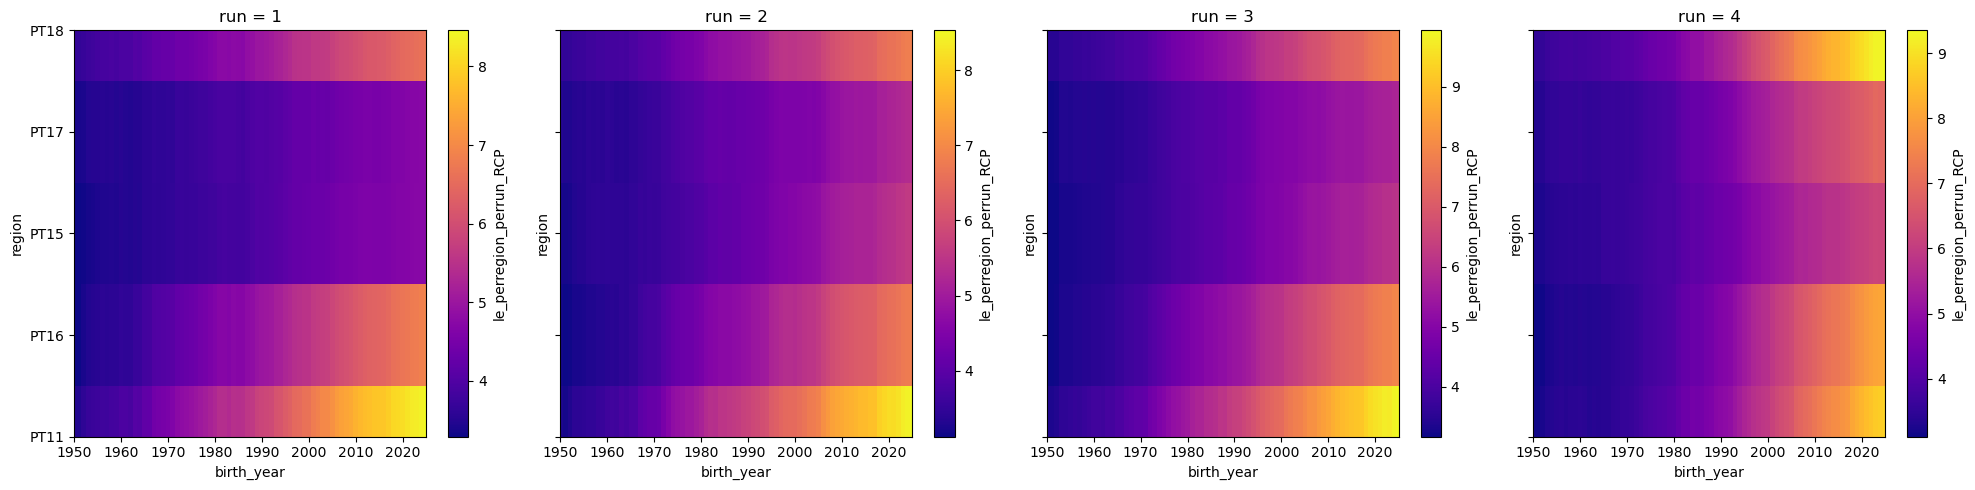

In [188]:
fig, axes = plt.subplots(1,4, figsize=(20,5), sharey=True)

for i in range(len(ds_le_perregion_perrun.run)):
    (ds_le_perregion_perrun.isel(run=i)['le_perregion_perrun_RCP']/365).plot(cmap='plasma', ax=axes[i])

plt.tight_layout()

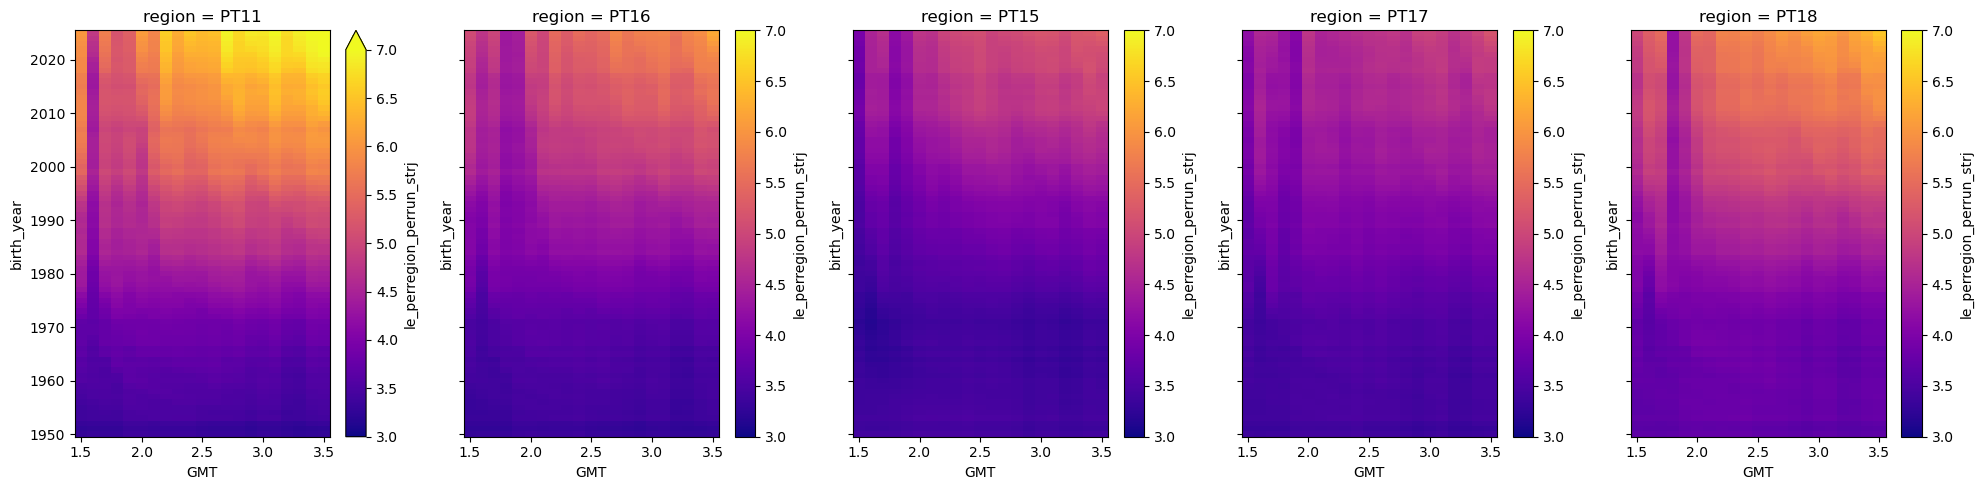

In [168]:
fig, axes = plt.subplots(1,5, figsize=(20,5), sharey=True)

for i in range(len(region_names_long)):
    (ds_le_perregion_perrun.isel(region=i)['le_perregion_perrun_strj'].mean(dim='run') / 365).plot(cmap='plasma', ax=axes[i], vmin=3,vmax=7)

plt.tight_layout()

<Axes: >

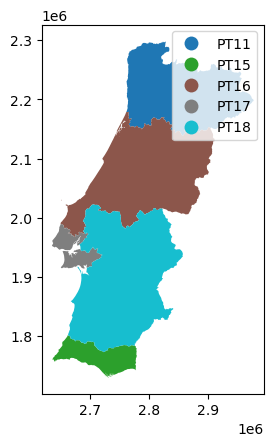

In [179]:
gdf_subnat.plot(column='id', legend=True)


In [177]:
gdf_subnat

,id,country,name,geometry,population
id,,,,,
PT11,PT11,PT,Norte,"MULTIPOLYGON (((2828396.621 2295946.291, 28279...",3.382892e+06
PT16,PT16,PT,Centro (PT),"MULTIPOLYGON (((2884540.928 2154285.866, 28843...",2.046652e+06
PT15,PT15,PT,Algarve,"MULTIPOLYGON (((2771669.671 1784422.908, 27717...",4.102613e+05
PT17,PT17,PT,Área Metropolitana de Lisboa,"MULTIPOLYGON (((2708333.948 1946251.261, 27098...",2.917903e+06
PT18,PT18,PT,Alentejo,"MULTIPOLYGON (((2822855.530 2014992.655, 28232...",7.127856e+05


### test fxn for all of Europe

In [5]:
filepath_nuts = glob.glob(os.path.join(os.environ['VSC_DATA_VO_USER'], 'fwi-portugal/data/shapefiles/eurostat/NUTS_RG_01M_2016/NUTS_RG_*.shp'))[0]


gdf_subnat, subnational_regions, subnational_mask = load_subnational_mask(
    filepath_shp = filepath_nuts,
    da_population=da_population,
    bbox=bbox_europe,
    dict_keep={'LEVL_CODE':2}, 
    dict_drop=None,
    col_name="NAME_LATN",
    col_id= "NUTS_ID",
    col_country='CNTR_CODE',
    )

load_subnational_mask took 18.07 s


In [6]:
gdf_subnat

,id,country,name,geometry,population
CY00,CY00,CY,Kypros,"MULTIPOLYGON (((34.60060 35.70236, 34.59946 35...",1.059744e+06
EL43,EL43,EL,Kriti,"MULTIPOLYGON (((26.34043 35.26729, 26.33896 35...",3.141004e+05
EL42,EL42,EL,Notio Aigaio,"MULTIPOLYGON (((29.63182 36.10660, 29.62835 36...",1.617083e+05
EL30,EL30,EL,Attiki,"MULTIPOLYGON (((23.71291 38.33582, 23.72751 38...",3.634833e+06
TR62,TR62,TR,"Adana, Mersin","MULTIPOLYGON (((34.90646 36.72525, 34.89925 36...",1.293797e+06
...,...,...,...,...,...
UKM8,UKM8,UK,West Central Scotland,"POLYGON ((-4.72050 56.32195, -4.71693 56.32347...",1.491191e+06
UKM7,UKM7,UK,Eastern Scotland,"MULTIPOLYGON (((-2.85253 56.97337, -2.84206 56...",1.725599e+06
UKM5,UKM5,UK,North Eastern Scotland,"POLYGON ((-2.05506 57.69500, -2.04154 57.69208...",4.453824e+05
UKM6,UKM6,UK,Highlands and Islands,"MULTIPOLYGON (((-0.87395 60.80644, -0.86892 60...",4.043883e+05


In [7]:
gdf_subnat.rename_axis(None).sort_values(['country', 'id'])

,id,country,name,geometry,population
AL01,AL01,AL,Veri,"POLYGON ((19.75005 42.62767, 19.75238 42.61405...",7.024262e+05
AL02,AL02,AL,Qender,"POLYGON ((19.99799 41.43036, 20.00866 41.42875...",1.356883e+06
AL03,AL03,AL,Jug,"MULTIPOLYGON (((20.63287 41.08651, 20.67063 41...",6.277144e+05
AT11,AT11,AT,Burgenland,"POLYGON ((17.09317 48.09142, 17.09132 48.09057...",2.731608e+05
AT12,AT12,AT,Niederösterreich,"POLYGON ((15.03985 49.01192, 15.05387 49.01526...",1.728838e+06
...,...,...,...,...,...
UKM6,UKM6,UK,Highlands and Islands,"MULTIPOLYGON (((-0.87395 60.80644, -0.86892 60...",4.043883e+05
UKM7,UKM7,UK,Eastern Scotland,"MULTIPOLYGON (((-2.85253 56.97337, -2.84206 56...",1.725599e+06
UKM8,UKM8,UK,West Central Scotland,"POLYGON ((-4.72050 56.32195, -4.71693 56.32347...",1.491191e+06
UKM9,UKM9,UK,Southern Scotland,"MULTIPOLYGON (((-2.33027 55.93062, -2.29192 55...",8.804819e+05


In [8]:
subnational_regions

<regionmask.Regions 'NAME_LATN'>
overlap:  None

Regions:
  0 CY00                 Kypros
  1 EL43                  Kriti
  2 EL42           Notio Aigaio
  3 EL30                 Attiki
  4 TR62          Adana, Mersin
 ..  ...                    ...
310 UKM8  West Central Scotland
311 UKM7       Eastern Scotland
312 UKM5 North Eastern Scotland
313 UKM6  Highlands and Islands
314 IS00                 Ísland

[315 regions]

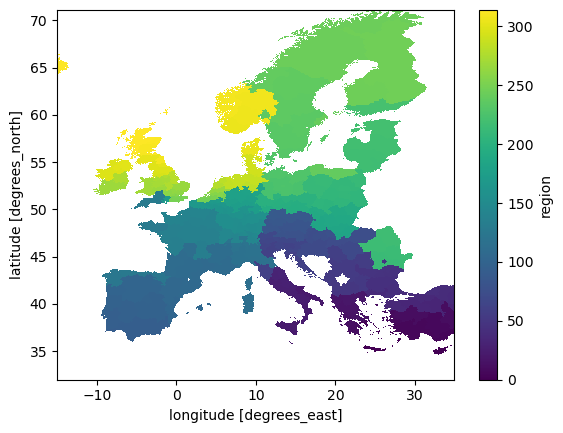

In [9]:
subnational_mask.plot()

# missing some eastern european countries??? whyyyyy ? Bosnia + Kosovo + Andorra also maybe?
# maybe they dont have NUTS2 outline

In [10]:
subnational_mask

<xarray.DataArray 'mask' (lat: 391, lon: 499)>
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]])
Coordinates:
  * lat      (lat) float64 32.05 32.15 32.25 32.35 ... 70.75 70.85 70.95 71.05
  * lon      (lon) float64 -14.95 -14.85 -14.75 -14.65 ... 34.65 34.75 34.85
Attributes:
    standard_name:  region
    flag_values:    [  0   1   2   3   4   5   6   7   8   9  10  11  12  13 ...
    flag_meanings:  CY00 EL43 EL42 EL30 TR62 TR61 TR32 TR52 TR31 EL41 TR71 TR...

<Axes: >

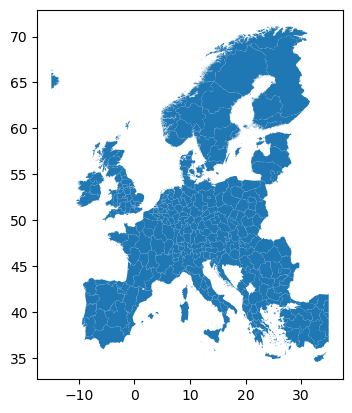

In [11]:
gdf_subnat.plot()

In [6]:
subset = dict(list(d_climate_data_meta.items())[0:1])

In [7]:
subset

{1: {'extreme': 'FWI95d',
  'model': 'ACCESS-CM2',
  'scenario': 'ssp126',
  'GMT':            tas
  1950  0.385547
  1951  0.393164
  1952  0.393677
  1953  0.379471
  1954  0.362028
  ...        ...
  2115  2.769605
  2116  2.769605
  2117  2.769605
  2118  2.769605
  2119  2.769605
  
  [170 rows x 1 columns],
  'GMT_strj_maxdiff': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1]),
  'GMT_strj_valid': array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0]),
  'ind_RCP2GMT_strj': array([[ 23,  23,  23, ...,  23,  23,  23],
         [ 23,  23,  23, ...,  23,  23,  23],
         [ 23,  23,  23, ...,  23,  23,  23],
         ...,
         [ 69,  72,  75, ..., 149, 149, 149],
         [ 69,  71,  75, ..., 149, 149, 149],
         [ 69,  71,  75, ..., 149, 149, 149]]),
  'GMT_15_maxdiff': 0.05735471051576235,
  'GMT_15_valid': True,
  'ind_RCP2GMT_15': array([23, 23, 23, 23, 23, 23, 23, 23, 23, 23, 23, 23, 23, 23, 23, 23, 23,
         23, 23, 23, 23, 23

In [8]:
ds_le_perregion_perrun, region_names = calc_lifetime_exposure_subnational(
    subset, #d_climate_data_meta
    df_countries, 
    subnational_regions, 
    subnational_mask, 
    gdf_subnat, 
    climatedata_dir,
    da_population, 
    df_life_expectancy_5,
    da_cohort_size,
    GMT_labels = df_GMT_strj.columns , #df_GMT_strj.columns
    GMT_extra_trajectories_names=GMT_extra_trajectories_names,
    start_birthyear=1950,
    end_birthyear=2025,
    year_start=1950,
    year_end=2119,
    bbox=None,)


    # super slow! 

                         🟠 Remapping Simulation 1 of 1 🟠

Loading /vscmnt/brussel_pixiu_data/_data_brussel/vo/000/bvo00012/vsc10419/fwi-portugal/data/preprocessed/FWI/historical/ACCESS-CM2/FWI_ACCESS-CM2_1950_2014_FWI95d.nc
Loading /vscmnt/brussel_pixiu_data/_data_brussel/vo/000/bvo00012/vsc10419/fwi-portugal/data/preprocessed/FWI/ssp126/ACCESS-CM2/FWI_ACCESS-CM2_2015_2100_FWI95d.nc
load_climate_data_array took 0.41 s
⏳ Computing the Population-Weighted Spatial Average of the Exposure for all regions

🟢 Population-Weighted Spatial Average of the Exposure for all regions computed
Computing lifetime exposure (LE) for RCP 



IndexError: index 0 is out of bounds for axis 0 with size 0

In [1]:
df_countries

NameError: name 'df_countries' is not defined